In [174]:
import pandas as pd
import numpy as np
import random
import warnings
from math import pi

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from scipy import stats
from sklearn.metrics import silhouette_score

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn_extra.cluster import KMedoids

import skfuzzy as fuzz
from skfuzzy import control as ctrl

warnings.filterwarnings('ignore')
%matplotlib inline

## Task 1 — Exploratory Data Analysis (EDA)

In [175]:
df = pd.read_csv(r"C:\Users\user\Data_MIning\Customer-Churn-Records.csv")
df.columns = [c.strip().lower() for c in df.columns]

print(f'Rows   : {df.shape[0]}')
print(f'Columns: {df.shape[1]}')
df.head()

Rows   : 10000
Columns: 18


,rownumber,customerid,surname,creditscore,geography,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,complain,satisfaction score,card type,point earned
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


### Shape and column types :

In [176]:
print('Shape:', df.shape)
print('\nColumn dtypes:')
print(df.dtypes)

Shape: (10000, 18)

Column dtypes:
rownumber               int64
customerid              int64
surname                object
creditscore             int64
geography              object
gender                 object
age                     int64
tenure                  int64
balance               float64
numofproducts           int64
hascrcard               int64
isactivemember          int64
estimatedsalary       float64
exited                  int64
complain                int64
satisfaction score      int64
card type              object
point earned            int64
dtype: object


### Missing values :

In [177]:
print('\nMissing values:')
print(df.isnull().sum())


Missing values:
rownumber             0
customerid            0
surname               0
creditscore           0
geography             0
gender                0
age                   0
tenure                0
balance               0
numofproducts         0
hascrcard             0
isactivemember        0
estimatedsalary       0
exited                0
complain              0
satisfaction score    0
card type             0
point earned          0
dtype: int64


### Data describtion:

In [178]:
df.describe()

,rownumber,customerid,creditscore,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,complain,satisfaction score,point earned
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203800,0.204400,3.013800,606.515100
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402842,0.403283,1.405919,225.924839
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000,0.000000,1.000000,119.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000,0.000000,2.000000,410.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000,0.000000,3.000000,605.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000,0.000000,4.000000,801.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000,1.000000,5.000000,1000.000000


### Plot1 : Customer distribution according to their status (whether they curn or retained)

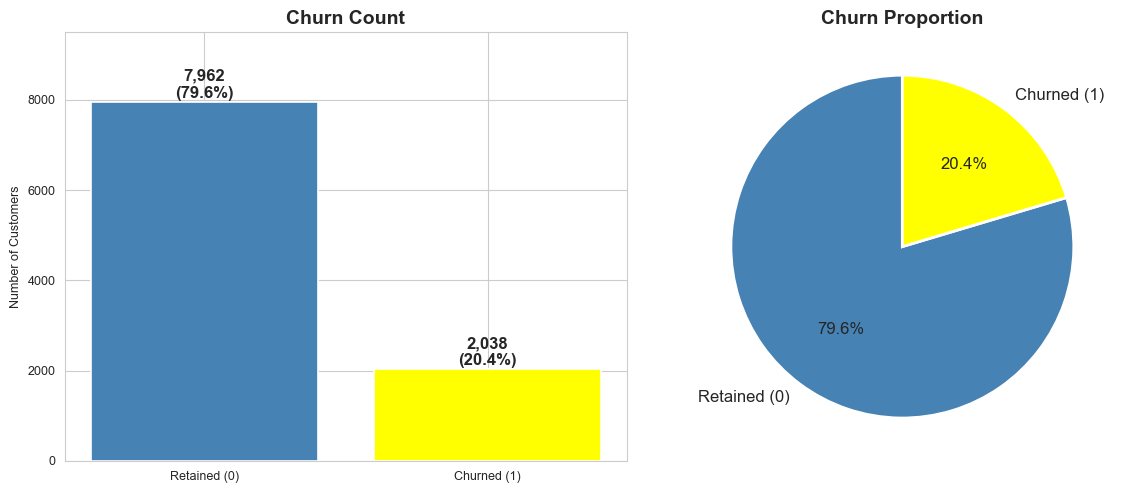

In [179]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

churn_counts = df['exited'].value_counts()
labels = ['Retained (0)', 'Churned (1)']
colors = ['steelblue', 'yellow']

# Bar chart
axes[0].bar(labels, churn_counts.values, color=colors, edgecolor='white', linewidth=1.2)
for i, v in enumerate(churn_counts.values):
    axes[0].text(i, v + 80, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Churn Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Customers')
axes[0].set_ylim(0, 9500)

# Pie chart
axes[1].pie(churn_counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2), textprops={'fontsize': 12})
axes[1].set_title('Churn Proportion', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

##### Interpretation:he dataset exhibits a notable **class imbalance**: 79.6% of customers were retained while 20.4% churned

### Plot-2 : show us

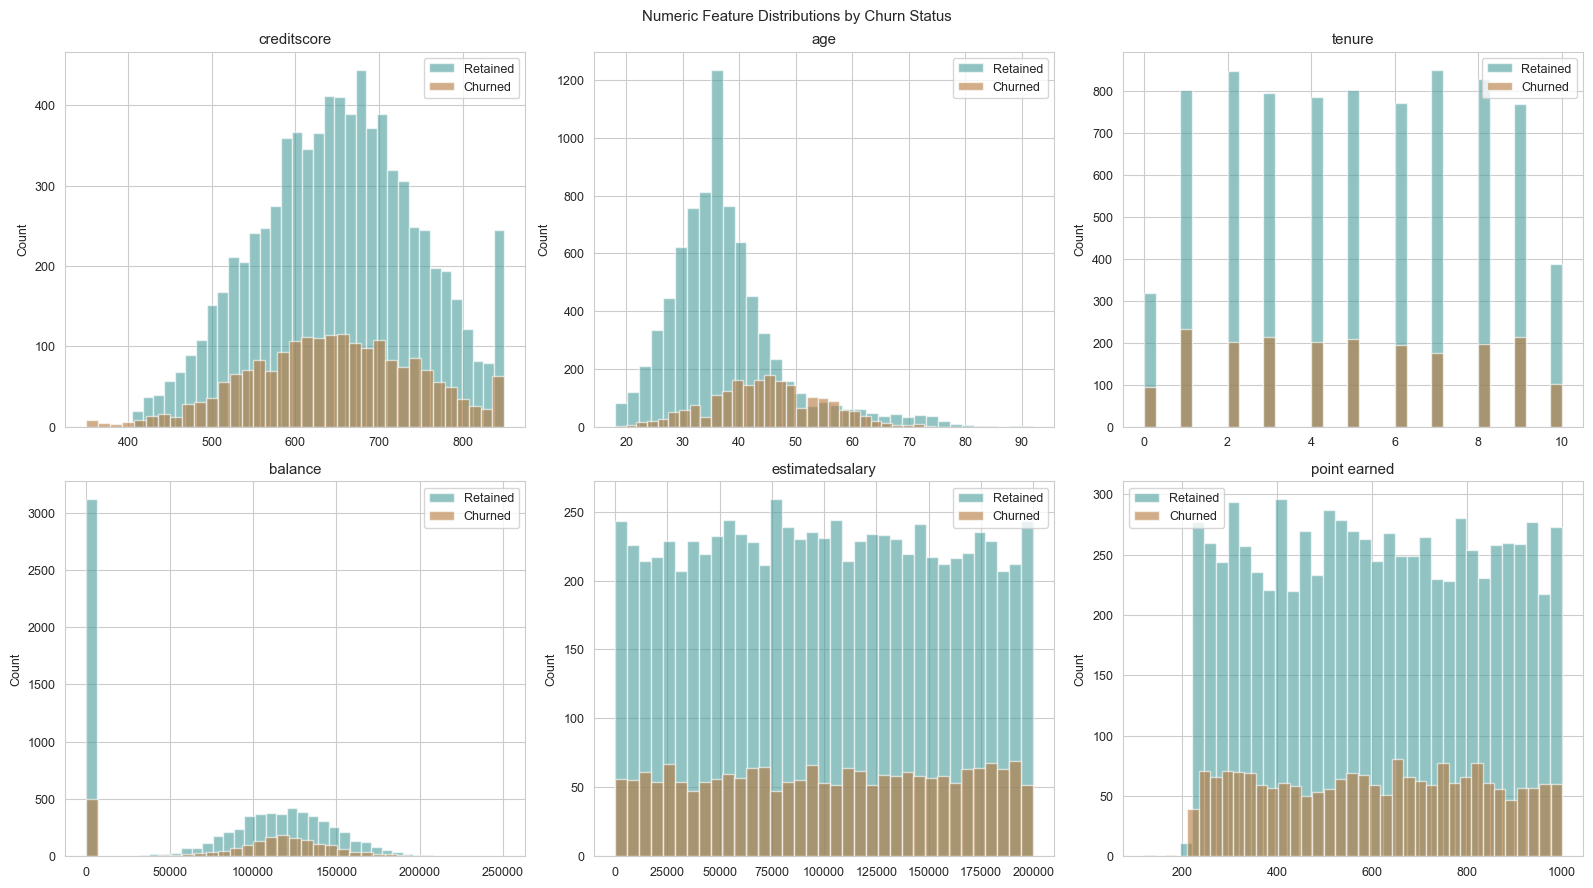

In [180]:
numeric_features = ['creditscore', 'age', 'tenure', 'balance', 'estimatedsalary', 'point earned']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, feat in enumerate(numeric_features):

    df[df['exited'] == 0][feat].hist(
        bins=35, alpha=0.6, color='#499c9c',
        label='Retained', ax=axes[i]
    )

    df[df['exited'] == 1][feat].hist(
        bins=35, alpha=0.6, color='#b5773a',
        label='Churned', ax=axes[i]
    )

    axes[i].set_title(feat)
    axes[i].set_ylabel('Count')
    axes[i].legend()

plt.suptitle('Numeric Feature Distributions by Churn Status')
plt.tight_layout()
plt.show()

### Interpretation — Figure 2:**
- **CreditScore**: Both groups share a similar distribution (~640–700), suggesting credit score alone is not a strong churn predictor.
- **Age**: Churned customers tend to be **older** (peak around 40–55), while retained customers skew younger
- **Tenure**: Fairly uniform across both groups, indicating tenure alone has limited predictive power.
- **Balance**: A large spike at zero for retained customers suggests many hold zero-balance accounts. Churned customers more often have non-zero balances — potentially indicating they withdraw and leave.
- **EstimatedSalary**: Both groups are nearly uniformly distributed across salary levels, suggesting salary is not a churn driver.
- **Point Earned**: Similar distributions across both groups, though churned customers show a slight skew toward fewer points.

### Plot-3 : churn rate be categorical features :

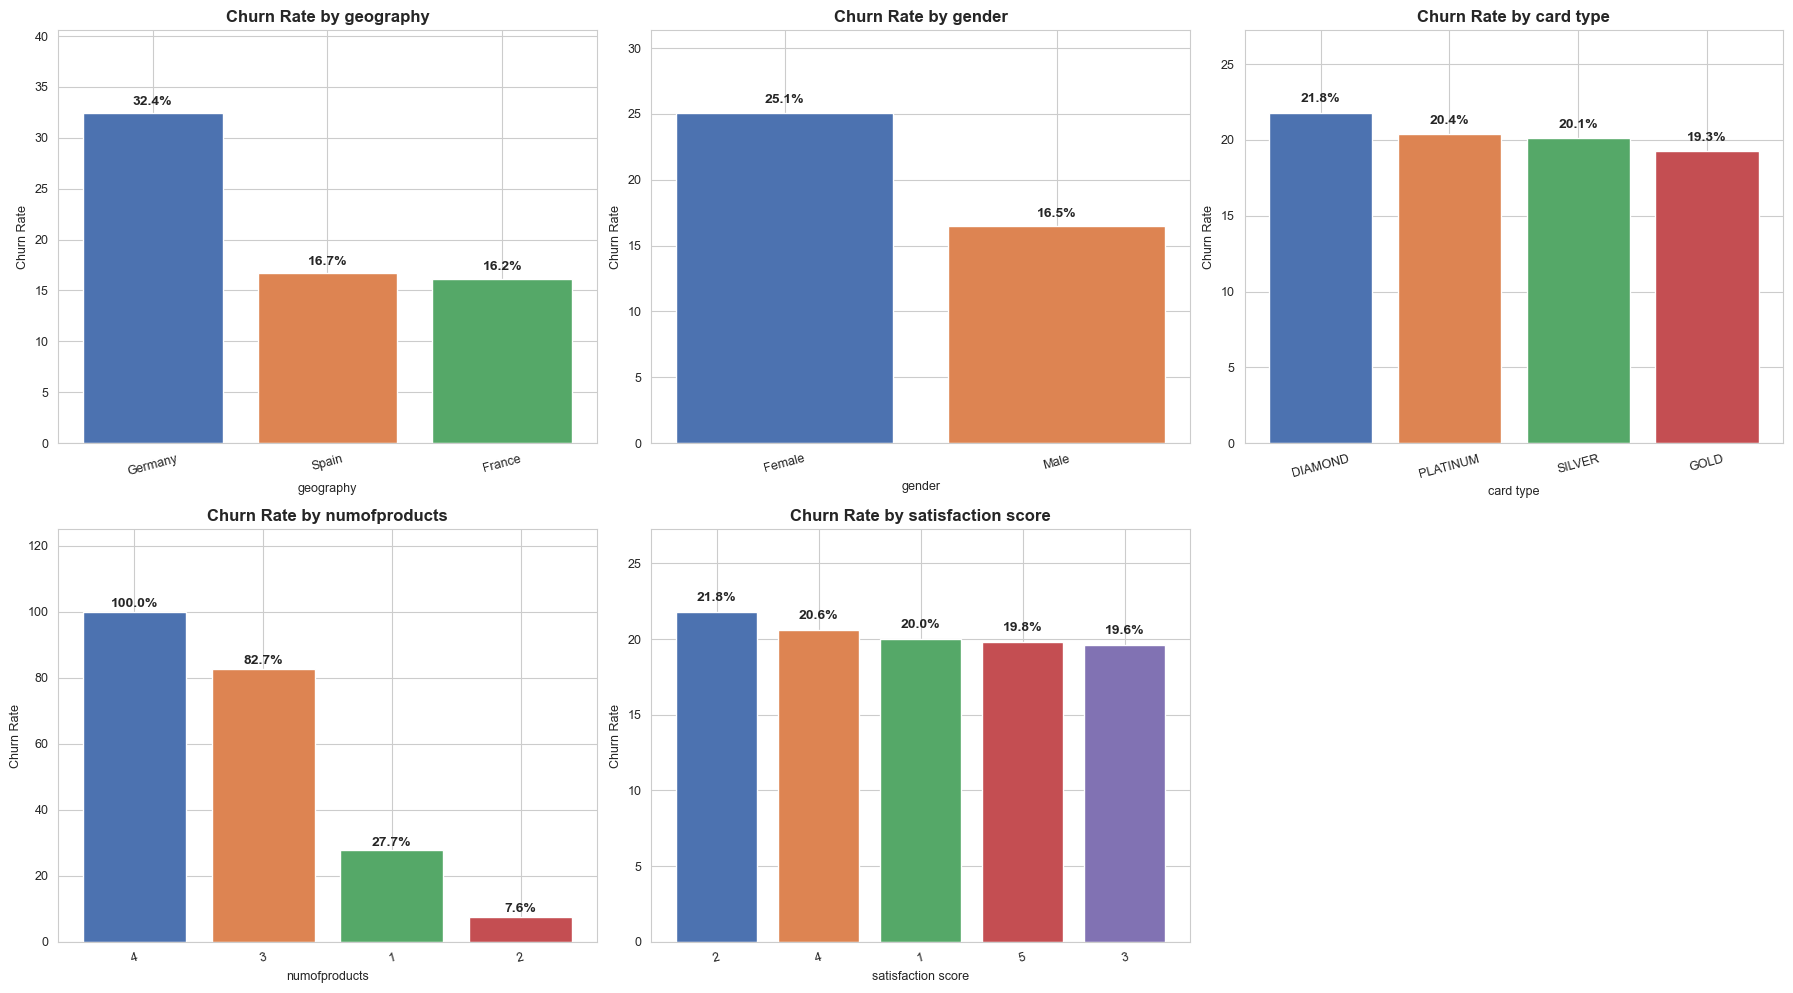

In [181]:
cat_features = ['geography', 'gender', 'card type', 'numofproducts', 'satisfaction score']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    churn_rate = df.groupby(feat)['exited'].mean().sort_values(ascending=False) * 100
    bars = axes[i].bar(churn_rate.index.astype(str), churn_rate.values,
                       color=sns.color_palette('deep', len(churn_rate)),
                       edgecolor='white', linewidth=1)
    for bar, val in zip(bars, churn_rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
    axes[i].set_title(f'Churn Rate by {feat}', fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Churn Rate')
    axes[i].set_xlabel(feat)
    axes[i].set_ylim(0, churn_rate.max() * 1.25)
    axes[i].tick_params(axis='x', rotation=15)

# Hide empty subplot
axes[5].set_visible(False)
plt.tight_layout()
plt.show()

**Geography**: German customers churn at 32%, more than double the rate of French (16%) and Spanish (17%) customers.
- **Gender**: Female customers have a notably higher churn rate (25%) than males (16%).
- **Card Type**: Churn rates are relatively consistent across card types (20%), meaning card tier is not a significant retention factor.
- **NumOfProducts**: Customers with 3 or 4 products show dramatically higher churn (83–100%), which is counter-intuitive and may reflect forced cross-selling or dissatisfaction with bundled products.
- **Satisfaction Score**: Customers with score 1 churn most (50%), while higher scores drop to 20%. There is no strong monotonic trend beyond the extreme low end.

### Correlation heatmap :

Correlation with exited:
exited                1.000000
complain              0.995693
age                   0.285296
balance               0.118577
estimatedsalary       0.012490
point earned         -0.004628
satisfaction score   -0.005849
hascrcard            -0.006976
tenure               -0.013656
creditscore          -0.026771
numofproducts        -0.047611
isactivemember       -0.156356
Name: exited, dtype: float64


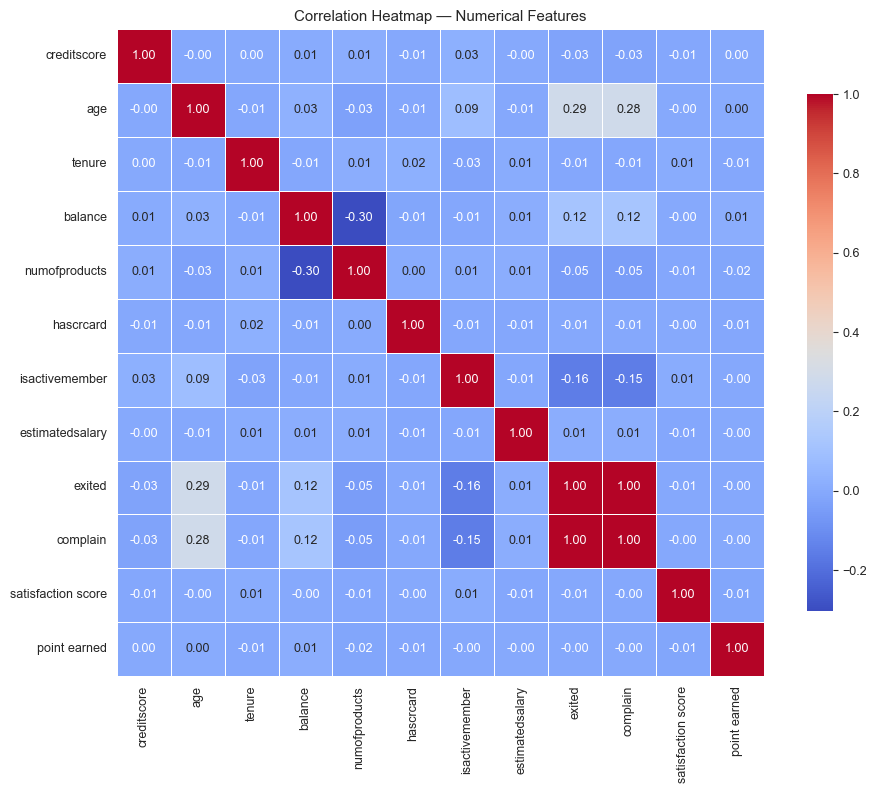

In [182]:
num_cols = ['creditscore', 'age', 'tenure', 'balance', 'numofproducts',
            'hascrcard', 'isactivemember', 'estimatedsalary', 'exited',
            'complain', 'satisfaction score', 'point earned']

corr = df[num_cols].corr()

print('Correlation with exited:')
print(corr['exited'].sort_values(ascending=False))

plt.figure(figsize=(10, 8))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8})

plt.title('Correlation Heatmap — Numerical Features')
plt.tight_layout()
plt.show()

**Interpretation — Figure 4:**
- **Complain and exited (r ≈ 1.0)**: An almost perfect positive correlation — nearly all customers who complained ended up churning. This feature would dominate any model and must be handled carefully (potential data leakage).
- **Age and Exited (r ≈ +0.29)**: Moderate positive correlation confirming that older customers are more likely to churn.
- **IsActiveMember and Exited (r ≈ −0.16)**: Active members are less likely to churn.
- **Balance and NumOfProducts (r ≈ −0.30)**: Customers with more products tend to have lower balances.
- Most other features show weak correlations with the target.

### Plot-5 : Churn rate by geography and gender .

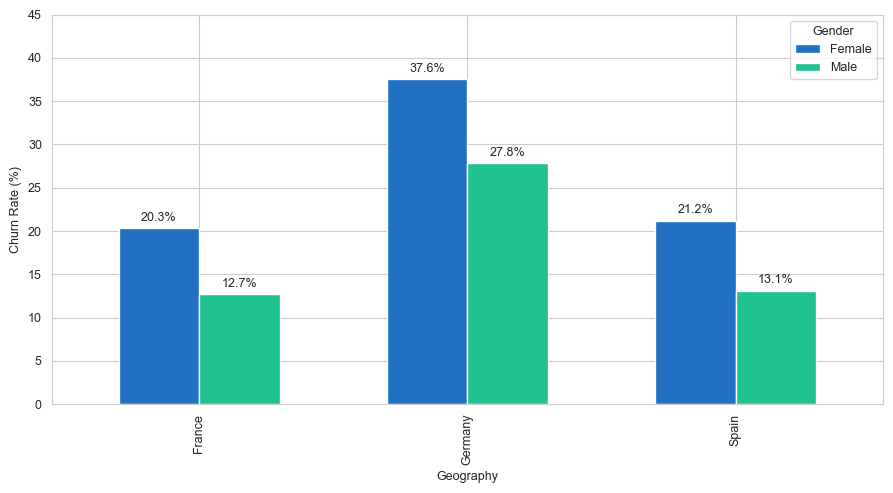

In [183]:
pivot = df.groupby(['geography', 'gender'])['exited'].mean().unstack() * 100

ax = pivot.plot(kind='bar', figsize=(9, 5),
                color=['#2171c2', '#21c292'],
                edgecolor='white', width=0.6)

ax.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
ax.bar_label(ax.containers[1], fmt='%.1f%%', padding=3)

ax.set_xlabel('Geography')
ax.set_ylabel('Churn Rate (%)')
ax.set_ylim(0, 45)
ax.legend(title='Gender')

plt.tight_layout()
plt.show()

**Interpretation — Figure 5:**
The combined Geography–Gender breakdown reveals that (German females) churn at the highest rate (38%), followed by (German males) (25%). In France and Spain, females still churn more than males but the gap is smaller. This interaction suggests that retention strategies should be doubly targeted: geography (Germany) and gender (female) together form the highest-risk segment.

__________________________________________________________________________________________________________________________________________________

## Task 2 — Data Preprocessing

### Drop Irrelevant Columns

In [184]:
copy = df.drop(columns=['rownumber', 'customerid', 'surname'])
print('Shape after dropping identifiers:', copy.shape)
print('\n Remaining columns:', copy.columns.tolist())


Shape after dropping identifiers: (10000, 15)

 Remaining columns: ['creditscore', 'geography', 'gender', 'age', 'tenure', 'balance', 'numofproducts', 'hascrcard', 'isactivemember', 'estimatedsalary', 'exited', 'complain', 'satisfaction score', 'card type', 'point earned']


Interpretation : (RowNumber, CustomerId, and Surname) are identifiers with no predictive value and would introduce noise or data leakage into the model.

_______________________________________________________________________________________________________________________________________________

### Nulls imputation

In [185]:
numeric_features = ['creditscore','age','tenure','balance','numofproducts','estimatedsalary','point earned', 'satisfaction score']
categorical_features = ['geography', 'gender', 'card type']

for col in categorical_features:
    if col in df.columns:
        df[col] = df[col].fillna(df[col].mode()[0])

for col in numeric_features:
    df[col] = df[col].fillna(df[col].mean())

Actually there are no any nulls , but i hava to do my job.

____________________________________________________________________________________________________________________________________

### Reomving outliers :

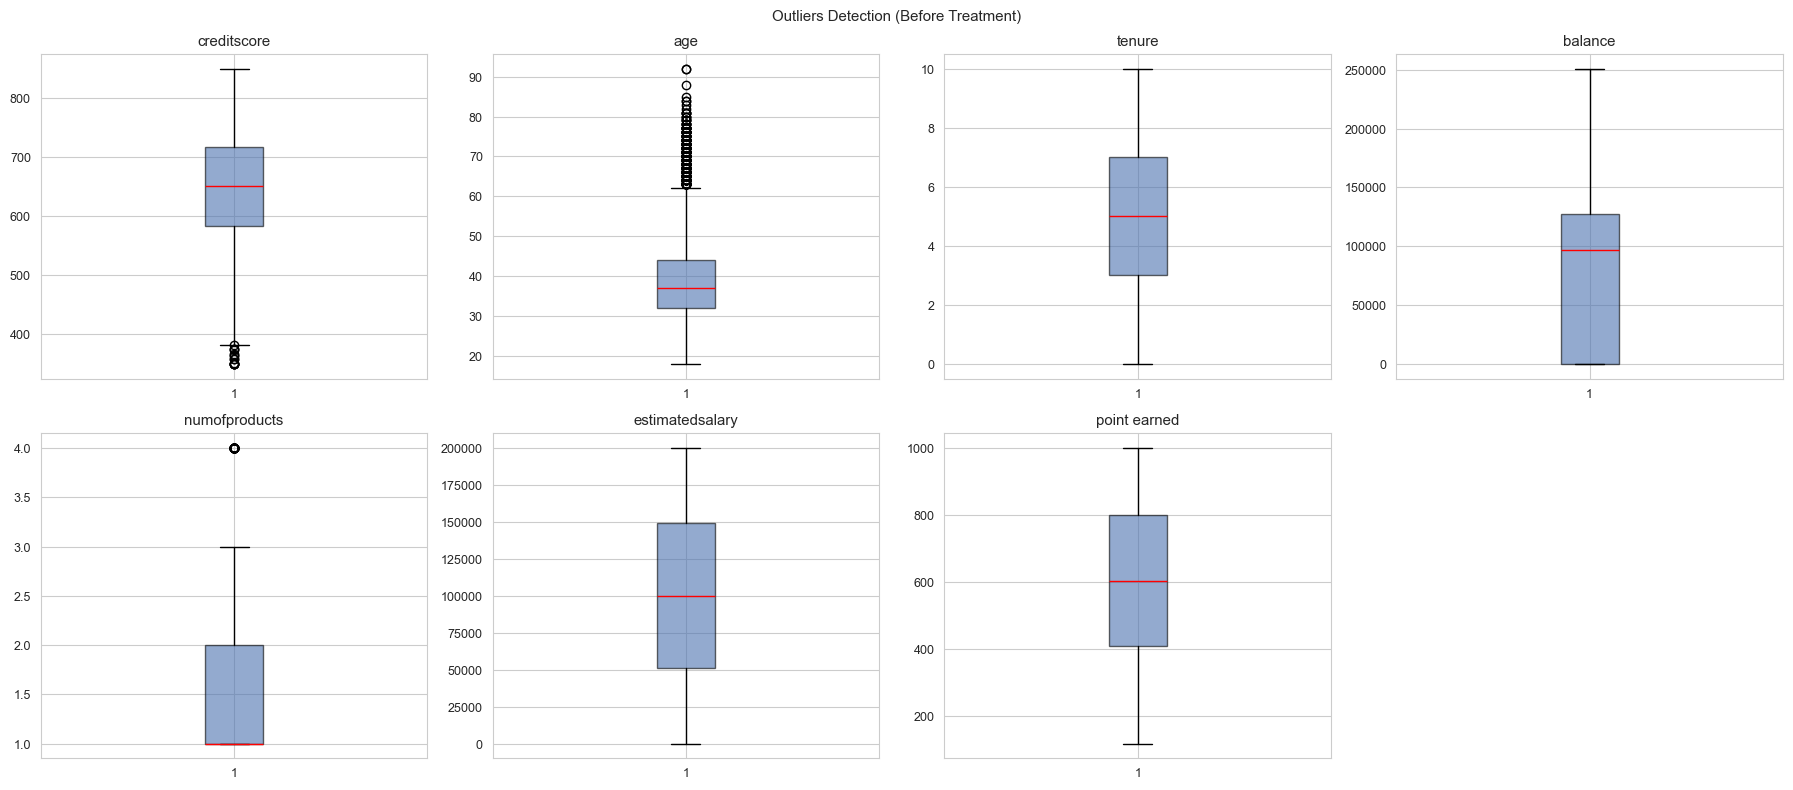

Outliers Summary:
creditscore: 15 outliers (0.15%)
age: 359 outliers (3.60%)
tenure: 0 outliers (0.00%)
balance: 0 outliers (0.00%)
numofproducts: 58 outliers (0.60%)
estimatedsalary: 0 outliers (0.00%)
point earned: 0 outliers (0.00%)
satisfaction score: 0 outliers (0.00%)


In [186]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].boxplot(copy[col].dropna(), patch_artist=True,
                    boxprops=dict(facecolor='#4C72B0', alpha=0.6),
                    medianprops=dict(color='red'))

    axes[i].set_title(col)

axes[-1].set_visible(False)

plt.suptitle('Outliers Detection (Before Treatment)')
plt.tight_layout()
plt.show()



print("Outliers Summary:")

for col in numeric_features:
    Q1 = copy[col].quantile(0.25)
    Q3 = copy[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask = (copy[col] < lower) | (copy[col] > upper)

    outliers_count = mask.sum()
    outliers_percentage = mask.mean() * 100
    copy = copy[(copy[col] >= lower) & (copy[col] <= upper)]

    print(f"{col}: {outliers_count} outliers ({outliers_percentage:.2f}%)")
# because there are 4 rows less than 1000
copy = copy[copy['estimatedsalary'] > 1000]

*Justification — Outlier Treatment:**
We applied  (IQR capping) to the five continuous features. This approach was chosen over row deletion to preserve all 10,000 records, which is especially important given the class imbalance. Features like `Balance` had valid zero entries representing customers with empty accounts, so capping was applied only at the upper/lower IQR boundaries rather than treating zeros as outliers.

### Encoding Categorical Features

In [187]:
print('BEFORE encoding:')
print(copy[['geography', 'gender', 'card type']].head(5))

le= LabelEncoder()
copy['gender'] = le.fit_transform(copy['gender'])  # Female=0, Male=1
copy= pd.get_dummies(copy, columns=['geography', 'card type'], drop_first=False)

print('\nAFTER encoding:')
print(copy.head(5))
print('\nNew shape:', copy.shape)

BEFORE encoding:
  geography  gender card type
0    France  Female   DIAMOND
1     Spain  Female   DIAMOND
2    France  Female   DIAMOND
3    France  Female      GOLD
4     Spain  Female      GOLD

AFTER encoding:
   creditscore  gender  age  tenure    balance  numofproducts  hascrcard  \
0          619       0   42       2       0.00              1          1   
1          608       0   41       1   83807.86              1          0   
2          502       0   42       8  159660.80              3          1   
3          699       0   39       1       0.00              2          0   
4          850       0   43       2  125510.82              1          1   

   isactivemember  estimatedsalary  exited  complain  satisfaction score  \
0               1        101348.88       1         1                   2   
1               1        112542.58       0         1                   3   
2               0        113931.57       1         1                   3   
3               0        

Label encoding is the best choice for binary featues and one hot encoding in better for non ordinal features .

In [188]:
target_col = 'exited'
X = copy.drop(columns=[target_col])
y = copy[target_col]

scale_cols = ['creditscore', 'age', 'tenure', 'balance',
              'estimatedsalary', 'point earned', 'satisfaction score']

print('BEFORE scaling (first 5 rows):')
print(X[scale_cols].head(5))

X['age'] = np.log(X['age'])

Mscaler = MinMaxScaler()

X[scale_cols] = Mscaler.fit_transform(X[scale_cols])

print('\nAFTER scaling (first 5 rows):')
print(X[scale_cols].head(5))

BEFORE scaling (first 5 rows):
   creditscore  age  tenure    balance  estimatedsalary  point earned  \
0          619   42       2       0.00        101348.88           464   
1          608   41       1   83807.86        112542.58           456   
2          502   42       8  159660.80        113931.57           377   
3          699   39       1       0.00         93826.63           350   
4          850   43       2  125510.82         79084.10           425   

   satisfaction score  
0                   2  
1                   3  
2                   3  
3                   5  
4                   5  

AFTER scaling (first 5 rows):
   creditscore       age  tenure   balance  estimatedsalary  point earned  \
0     0.505353  0.685093     0.2  0.000000         0.504279      0.391600   
1     0.481799  0.665609     0.1  0.334031         0.560531      0.382520   
2     0.254818  0.685093     0.8  0.636357         0.567512      0.292849   
3     0.676660  0.625172     0.1  0.000000     

Justification: StandardScaler (zero mean, unit variance) is preferred for
clustering algorithms (K-Medoids) and PCA, which are sensitive to feature
 magnitude. It handles Gaussian-like distributions well and does not compress
 extreme values as aggressively as MinMaxScaler.

__________________________________________________________________________________________________________________________________________________

## Task 3: K-Medoid Clustering

### Get the optimal number of clusters using the Elbow Method and Silhouette Score

In [189]:
inertia = []
silhouette_avg = []
k_range = range(2, 11)

for k in k_range:
    kmedoids = KMedoids(n_clusters=k, metric="manhattan", init="random", random_state=42)
    kmedoids.fit(X)
    inertia.append(kmedoids.inertia_)
    silhouette_avg.append(silhouette_score(X, kmedoids.labels_))

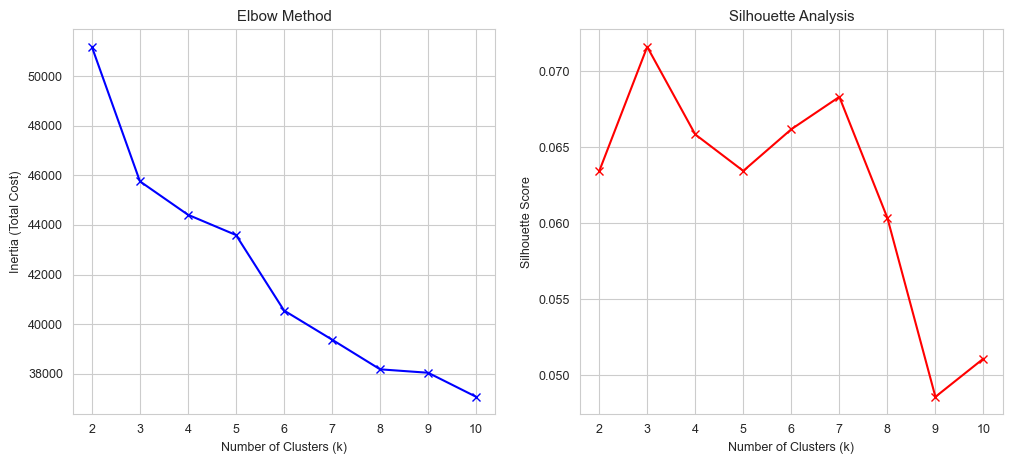

In [190]:
# Elbow Method
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Total Cost)')
plt.title('Elbow Method')

# Silhouette Score
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_avg, 'rx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Analysis')
plt.show()

The Elbow Method shows the steepest decrease in inertia levels off at k=6, indicating the optimal point where adding more clusters stops being beneficial.

The Silhouette Score peaks at k=6 (≈0.074), meaning clusters are most cohesive and well-separated at this value.

Result: K=6 balances model complexity with cluster quality—capturing natural groupings without over-segmentation.

### Fit the model and analyze each cluster profile

In [206]:
kmedoids = KMedoids(n_clusters=3, metric='manhattan', init='k-medoids++', random_state=42)
copy['Cluster'] = kmedoids.fit_predict(X)

In [209]:
class ClusterVisualizer:
    """Comprehensive cluster visualization and analysis"""

    def __init__(self, copy, cluster_col='Cluster'):
        self.copy = copy
        self.cluster_col = cluster_col
        self.n_clusters = copy[cluster_col].nunique()
        self.colors = sns.color_palette("husl", self.n_clusters)

        # Set style
        sns.set_style("whitegrid")
        plt.rcParams['figure.figsize'] = (16, 10)
        plt.rcParams['font.size'] = 9


    def _get_geography(self, row):
        """Extract geography from one-hot encoded columns"""
        if row['geography_France'] == 1:
            return 'France'
        elif row['geography_Germany'] == 1:
            return 'Germany'
        elif row['geography_Spain'] == 1:
            return 'Spain'
        return 'Unknown'

    def _get_card_type(self, row):
        """Extract card type from one-hot encoded columns"""
        if row['card type_DIAMOND'] == 1:
            return 'DIAMOND'
        elif row['card type_GOLD'] == 1:
            return 'GOLD'
        elif row['card type_PLATINUM'] == 1:
            return 'PLATINUM'
        elif row['card type_SILVER'] == 1:
            return 'SILVER'
        return 'Unknown'

    def _prepare_data(self):
        """Prepare decoded geography and card type columns"""
        data = self.copy.copy()
        data['geography'] = data.apply(self._get_geography, axis=1)
        data['card_type'] = data.apply(self._get_card_type, axis=1)
        data['gender'] = data['gender'].map({0: 'Female', 1: 'Male'})
        return data

    # ========================================================================
    # VISUALIZATION 1: DEMOGRAPHIC PROFILE
    # ========================================================================

    def viz_demographic_profile(self):
        """View 1: Demographic analysis across clusters"""
        data = self._prepare_data()

        fig = plt.figure(figsize=(22, 5))
        gs = fig.add_gridspec(1, 5, hspace=0.35, wspace=0.3)

        fig.suptitle('DEMOGRAPHIC PROFILE BY CLUSTER', fontsize=18, fontweight='bold', y=0.98)

        # 1. Age Distribution
        ax1 = fig.add_subplot(gs[0, 0])
        age_data = [data[data[self.cluster_col] == i]['age'].values
                    for i in sorted(data[self.cluster_col].unique())]
        bp1 = ax1.boxplot(age_data, labels=[f'C{i}' for i in range(self.n_clusters)],
                          patch_artist=True, widths=0.6)
        for patch, color in zip(bp1['boxes'], self.colors):
            patch.set_facecolor(color)
        ax1.set_title('Age Distribution', fontweight='bold', fontsize=11)
        ax1.set_ylabel('Age (years)', fontweight='bold')
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.set_ylim(20, 80)

        means = [data[data[self.cluster_col] == i]['age'].mean()
                for i in range(self.n_clusters)]
        ax1.plot(range(1, self.n_clusters + 1), means, 'r*', markersize=15, label='Mean')
        ax1.legend()

        # 2. Gender Distribution
        ax2 = fig.add_subplot(gs[0, 1])
        gender_data = pd.crosstab(data[self.cluster_col], data['gender'])
        gender_pct = gender_data.div(gender_data.sum(axis=1), axis=0) * 100
        gender_pct.plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4'], edgecolor='black', linewidth=1.5)
        ax2.set_title('Gender Distribution (%)', fontweight='bold', fontsize=11)
        ax2.set_ylabel('Percentage', fontweight='bold')
        ax2.set_xlabel('Cluster', fontweight='bold')
        ax2.set_xticklabels([f'C{i}' for i in range(self.n_clusters)], rotation=0)
        ax2.legend(title='Gender', loc='upper right')
        ax2.grid(True, alpha=0.3, axis='y')

        # 3. Geography Distribution
        ax3 = fig.add_subplot(gs[0, 2])
        geo_data = pd.crosstab(data[self.cluster_col], data['geography'])
        geo_pct = geo_data.div(geo_data.sum(axis=1), axis=0) * 100
        geo_pct.plot(kind='bar', ax=ax3, color=['#FFD93D', '#6BCB77', '#FF6B9D'],
                    edgecolor='black', linewidth=1.5)
        ax3.set_title('Geography Distribution (%)', fontweight='bold', fontsize=11)
        ax3.set_ylabel('Percentage', fontweight='bold')
        ax3.set_xlabel('Cluster', fontweight='bold')
        ax3.set_xticklabels([f'C{i}' for i in range(self.n_clusters)], rotation=0)
        ax3.legend(title='Geography', loc='upper right')
        ax3.grid(True, alpha=0.3, axis='y')


        # 4. Cluster Size
        ax5 = fig.add_subplot(gs[0, 3])
        sizes = data[self.cluster_col].value_counts().sort_index()
        percentages = (sizes / len(data) * 100).round(1)
        bars = ax5.bar([f'C{i}' for i in range(self.n_clusters)], sizes,
                      color=self.colors, edgecolor='black', linewidth=2)
        ax5.set_title('Cluster Size Distribution', fontweight='bold', fontsize=11)
        ax5.set_ylabel('Number of Customers', fontweight='bold')
        ax5.set_xlabel('Cluster', fontweight='bold')
        ax5.grid(True, alpha=0.3, axis='y')

        for i, (bar, pct) in enumerate(zip(bars, percentages)):
            height = bar.get_height()
            ax5.text(bar.get_x() + bar.get_width()/2., height,
                    f'{int(height)}\n({pct}%)',
                    ha='center', va='bottom', fontweight='bold', fontsize=9)


        # 5. Card Type Distribution
        ax4 = fig.add_subplot(gs[0, 4])
        card_data = pd.crosstab(data[self.cluster_col], data['card_type'])
        card_pct = card_data.div(card_data.sum(axis=1), axis=0) * 100
        card_colors = ['#FFB6C1', '#FFD700', '#87CEEB', '#D3D3D3']
        card_pct.plot(kind='bar', ax=ax4, color=card_colors, edgecolor='black', linewidth=1.5)
        ax4.set_title('Card Type Distribution (%)', fontweight='bold', fontsize=11)
        ax4.set_ylabel('Percentage', fontweight='bold')
        ax4.set_xlabel('Cluster', fontweight='bold')
        ax4.set_xticklabels([f'C{i}' for i in range(self.n_clusters)], rotation=0)
        ax4.legend(title='Card Type', loc='upper right', fontsize=8)
        ax4.grid(True, alpha=0.3, axis='y')


        plt.tight_layout()
        return fig
    # ========================================================================
    # VISUALIZATION 2: FINANCIAL PROFILE
    # ========================================================================

    def viz_financial_profile(self):
        """View 2: Financial characteristics and wealth indicators"""
        fig = plt.figure(figsize=(20, 5))
        gs = fig.add_gridspec(1, 4, hspace=0.35, wspace=0.3)

        fig.suptitle('FINANCIAL PROFILE BY CLUSTER', fontsize=18, fontweight='bold', y=0.98)

        # 1. Balance Distribution
        ax1 = fig.add_subplot(gs[0, 0])
        balance_data = [self.copy[self.copy[self.cluster_col] == i]['balance'].values
                       for i in range(self.n_clusters)]
        bp1 = ax1.boxplot(balance_data, labels=[f'C{i}' for i in range(self.n_clusters)],
                         patch_artist=True, widths=0.6)
        for patch, color in zip(bp1['boxes'], self.colors):
            patch.set_facecolor(color)
        ax1.set_title('Account Balance Distribution', fontweight='bold', fontsize=11)
        ax1.set_ylabel('Balance ($)', fontweight='bold')
        ax1.grid(True, alpha=0.3, axis='y')
        ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

        # 2. Salary Distribution
        ax2 = fig.add_subplot(gs[0, 1])
        salary_data = [self.copy[self.copy[self.cluster_col] == i]['estimatedsalary'].values
                      for i in range(self.n_clusters)]
        bp2 = ax2.boxplot(salary_data, labels=[f'C{i}' for i in range(self.n_clusters)],
                         patch_artist=True, widths=0.6)
        for patch, color in zip(bp2['boxes'], self.colors):
            patch.set_facecolor(color)
        ax2.set_title('Estimated Salary Distribution', fontweight='bold', fontsize=11)
        ax2.set_ylabel('Salary ($)', fontweight='bold')
        ax2.grid(True, alpha=0.3, axis='y')
        ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

        # 3. Credit Score Distribution
        ax3 = fig.add_subplot(gs[0, 2])
        credit_data = [self.copy[self.copy[self.cluster_col] == i]['creditscore'].values
                      for i in range(self.n_clusters)]
        bp3 = ax3.boxplot(credit_data, labels=[f'C{i}' for i in range(self.n_clusters)],
                         patch_artist=True, widths=0.6)
        for patch, color in zip(bp3['boxes'], self.colors):
            patch.set_facecolor(color)
        ax3.set_title('Credit Score Distribution', fontweight='bold', fontsize=11)
        ax3.set_ylabel('Credit Score', fontweight='bold')
        ax3.grid(True, alpha=0.3, axis='y')

        # 4. Median Balance vs Salary (Scatter)
        ax4 = fig.add_subplot(gs[0, 3])
        for i in range(self.n_clusters):
            cluster_data = self.copy[self.copy[self.cluster_col] == i]
            ax4.scatter(cluster_data['estimatedsalary'].median(),
                       cluster_data['balance'].median(),
                       s=500, alpha=0.7, color=self.colors[i], edgecolors='black', linewidth=2,
                       label=f'C{i}')
            ax4.annotate(f'C{i}',
                        (cluster_data['estimatedsalary'].median(), cluster_data['balance'].median()),
                        ha='center', va='center', fontweight='bold', fontsize=10)

        ax4.set_xlabel('Median Salary ($)', fontweight='bold')
        ax4.set_ylabel('Median Balance ($)', fontweight='bold')
        ax4.set_xlim(0, 120000)
        ax4.set_ylim(0, 120000)
        ax4.set_title('Salary vs Balance Position', fontweight='bold', fontsize=11)
        ax4.grid(True, alpha=0.3)
        ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
        ax4.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))


        plt.tight_layout()
        return fig

    # ========================================================================
    # VISUALIZATION 3: ENGAGEMENT & BEHAVIOR
    # ========================================================================

    def viz_engagement_behavior(self):
        """View 3: Customer engagement and behavioral patterns"""
        fig = plt.figure(figsize=(18, 12))
        gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

        fig.suptitle('ENGAGEMENT & BEHAVIORAL PROFILE BY CLUSTER', fontsize=18, fontweight='bold', y=0.98)

        # 1. Active Member Rate
        ax1 = fig.add_subplot(gs[0, 0])
        active_rates = [self.copy[self.copy[self.cluster_col] == i]['isactivemember'].mean() * 100
                       for i in range(self.n_clusters)]
        bars = ax1.bar([f'C{i}' for i in range(self.n_clusters)], active_rates,
                      color=self.colors, edgecolor='black', linewidth=2)
        ax1.set_title('Active Member Rate (%)', fontweight='bold', fontsize=11)
        ax1.set_ylabel('Percentage (%)', fontweight='bold')
        ax1.set_ylim(0, 100)
        ax1.axhline(np.mean(active_rates), color='red', linestyle='--', linewidth=2, label='Average')

        for bar, rate in zip(bars, active_rates):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{rate:.0f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

        ax1.grid(True, alpha=0.3, axis='y')
        ax1.legend()

        # 2. Number of Products
        ax2 = fig.add_subplot(gs[0, 1])
        num_products = [self.copy[self.copy[self.cluster_col] == i]['numofproducts'].mean()
                       for i in range(self.n_clusters)]
        bars = ax2.bar([f'C{i}' for i in range(self.n_clusters)], num_products,
                      color=self.colors, edgecolor='black', linewidth=2)
        ax2.set_title('Average Number of Products', fontweight='bold', fontsize=11)
        ax2.set_ylabel('Number of Products', fontweight='bold')
        ax2.axhline(np.mean(num_products), color='red', linestyle='--', linewidth=2, label='Average')

        for bar, num in zip(bars, num_products):
            height = bar.get_height()
            ax2.text(bar.get_x() + bar.get_width()/2., height,
                    f'{num:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

        ax2.grid(True, alpha=0.3, axis='y')
        ax2.legend()
        ax2.set_ylim(1, 2)

        # 3. Product Distribution
        ax3 = fig.add_subplot(gs[0, 2])
        for i in range(self.n_clusters):
            cluster_data = self.copy[self.copy[self.cluster_col] == i]
            products = cluster_data['numofproducts'].value_counts().sort_index()
            ax3.plot(products.index, products.values / len(cluster_data) * 100,
                    marker='o', label=f'C{i}', linewidth=2, markersize=8, color=self.colors[i])

        ax3.set_xlabel('Number of Products', fontweight='bold')
        ax3.set_ylabel('Percentage of Customers (%)', fontweight='bold')
        ax3.set_title('Product Distribution Pattern', fontweight='bold', fontsize=11)
        ax3.legend()
        ax3.grid(True, alpha=0.3)

        # 4. Points Earned
        ax4 = fig.add_subplot(gs[1, 0])
        points = [self.copy[self.copy[self.cluster_col] == i]['point earned'].mean()
                 for i in range(self.n_clusters)]
        bars = ax4.bar([f'C{i}' for i in range(self.n_clusters)], points,
                      color=self.colors, edgecolor='black', linewidth=2)
        ax4.set_title('Average Points Earned', fontweight='bold', fontsize=11)
        ax4.set_ylabel('Points', fontweight='bold')
        ax4.axhline(np.mean(points), color='red', linestyle='--', linewidth=2, label='Average')

        for bar, p in zip(bars, points):
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{p:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

        ax4.grid(True, alpha=0.3, axis='y')
        ax4.legend()

        # 5. Satisfaction Score
        ax5 = fig.add_subplot(gs[1, 1])
        satisfaction = [self.copy[self.copy[self.cluster_col] == i]['satisfaction score'].mean()
                       for i in range(self.n_clusters)]
        bars = ax5.bar([f'C{i}' for i in range(self.n_clusters)], satisfaction,
                      color=self.colors, edgecolor='black', linewidth=2)
        ax5.set_title('Average Satisfaction Score', fontweight='bold', fontsize=11)
        ax5.set_ylabel('Satisfaction (1-5)', fontweight='bold')
        ax5.set_ylim(0, 5)
        ax5.axhline(np.mean(satisfaction), color='red', linestyle='--', linewidth=2, label='Average')

        for bar, sat in zip(bars, satisfaction):
            height = bar.get_height()
            ax5.text(bar.get_x() + bar.get_width()/2., height,
                    f'{sat:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

        ax5.grid(True, alpha=0.3, axis='y')
        ax5.legend()

        # 6. Engagement vs Satisfaction
        ax6 = fig.add_subplot(gs[1, 2])
        for i in range(self.n_clusters):
            cluster_data = self.copy[self.copy[self.cluster_col] == i]
            ax6.scatter(cluster_data['isactivemember'].mean() * 100,
                       cluster_data['satisfaction score'].mean(),
                       s=500, alpha=0.7, color=self.colors[i], edgecolors='black', linewidth=2,
                       label=f'C{i}')
            ax6.annotate(f'C{i}',
                        (cluster_data['isactivemember'].mean() * 100,
                        cluster_data['satisfaction score'].mean()),
                        ha='center', va='center', fontweight='bold', fontsize=10)

        ax6.set_xlabel('Active Member Rate (%)', fontweight='bold')
        ax6.set_ylabel('Satisfaction Score', fontweight='bold')
        ax6.set_title('Engagement vs Satisfaction', fontweight='bold', fontsize=11)
        ax6.grid(True, alpha=0.3)
        ax6.legend()


        plt.tight_layout()
        return fig

    # ========================================================================
    # VISUALIZATION 4: CHURN & LOYALTY RISK
    # ========================================================================

    def viz_churn_loyalty(self):
        """View 4: Churn risk and loyalty indicators"""
        fig = plt.figure(figsize=(18, 14))
        gs = fig.add_gridspec(4, 3, hspace=0.4, wspace=0.3)

        fig.suptitle('CHURN RISK & LOYALTY PROFILE BY CLUSTER', fontsize=18, fontweight='bold', y=0.98)

        # 1. Exit Rate (Churn)
        ax1 = fig.add_subplot(gs[0, 0])
        exit_rates = [self.copy[self.copy[self.cluster_col] == i]['exited'].mean() * 100
                     for i in range(self.n_clusters)]
        bars = ax1.bar([f'C{i}' for i in range(self.n_clusters)], exit_rates,
                      color=['#e74c3c' if rate > 20 else '#f39c12' if rate > 15 else '#27ae60'
                            for rate in exit_rates],
                      edgecolor='black', linewidth=2)
        ax1.set_title('Customer Exit Rate (%) - CHURN RISK', fontweight='bold', fontsize=11, color='red')
        ax1.set_ylabel('Exit Rate (%)', fontweight='bold')
        ax1.set_ylim(0, 30)

        overall_exit = self.copy['exited'].mean() * 100
        ax1.axhline(overall_exit, color='red', linestyle='--', linewidth=2, label=f'Overall: {overall_exit:.1f}%')

        for bar, rate in zip(bars, exit_rates):
            height = bar.get_height()
            ax1.text(bar.get_x() + bar.get_width()/2., height,
                    f'{rate:.1f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)

        ax1.grid(True, alpha=0.3, axis='y')
        ax1.legend()

        # 2. Churn Risk Categories
        ax2 = fig.add_subplot(gs[0, 1])
        churn_categories = []
        for i in range(self.n_clusters):
            cluster_data = self.copy[self.copy[self.cluster_col] == i]
            high_risk = (cluster_data['exited'] == 1).sum()
            low_risk = (cluster_data['exited'] == 0).sum()
            churn_categories.append([high_risk, low_risk])

        churn_arr = np.array(churn_categories).T
        x_pos = np.arange(self.n_clusters)

        ax2.bar(x_pos, churn_arr[0], label='Exited', color='#e74c3c', edgecolor='black', linewidth=1.5)
        ax2.bar(x_pos, churn_arr[1], bottom=churn_arr[0], label='Active', color='#27ae60', edgecolor='black', linewidth=1.5)

        ax2.set_title('Customer Status Distribution', fontweight='bold', fontsize=11)
        ax2.set_ylabel('Number of Customers', fontweight='bold')
        ax2.set_xticks(x_pos)
        ax2.set_xticklabels([f'C{i}' for i in range(self.n_clusters)])
        ax2.legend()
        ax2.grid(True, alpha=0.3, axis='y')

        # 3. Risk Matrix
        ax3 = fig.add_subplot(gs[0, 2])

        risk_scores = []
        for i in range(self.n_clusters):
            cluster_data = self.copy[self.copy[self.cluster_col] == i]
            churn_rate = cluster_data['exited'].mean()
            engagement = cluster_data['isactivemember'].mean()
            balance = cluster_data['balance'].mean()

            risk = (churn_rate * 100 + (1 - engagement) * 50 - balance / 2000) / 2
            risk_scores.append(risk)

        colors_risk = ['#c0392b' if r > 20 else '#e67e22' if r > 10 else '#f39c12' if r > 5 else '#27ae60'
                      for r in risk_scores]
        bars = ax3.barh([f'C{i}' for i in range(self.n_clusters)], risk_scores,
                       color=colors_risk, edgecolor='black', linewidth=2)
        ax3.set_xlabel('Composite Risk Score', fontweight='bold')
        ax3.set_title('Overall Churn Risk Assessment', fontweight='bold', fontsize=11)

        for i, (bar, risk) in enumerate(zip(bars, risk_scores)):
            width = bar.get_width()
            risk_level = "CRITICAL" if risk > 20 else "HIGH" if risk > 10 else "MEDIUM" if risk > 5 else "LOW"
            ax3.text(width, bar.get_y() + bar.get_height()/2.,
                    f'{risk:.1f} ({risk_level})', ha='left', va='center', fontweight='bold', fontsize=9)

        ax3.grid(True, alpha=0.3, axis='x')

        # 4. Loyalty Indicators
        ax4 = fig.add_subplot(gs[1, 0])
        loyalty_scores = []
        for i in range(self.n_clusters):
            cluster_data = self.copy[self.copy[self.cluster_col] == i]
            loyalty = ((1 - cluster_data['exited'].mean()) * 50 +
                      cluster_data['isactivemember'].mean() * 30 +
                      cluster_data['numofproducts'].mean() * 10 +
                      cluster_data['satisfaction score'].mean() * 5) / 5
            loyalty_scores.append(loyalty)

        bars = ax4.bar([f'C{i}' for i in range(self.n_clusters)], loyalty_scores,
                      color=['#27ae60' if s > 75 else '#f39c12' if s > 60 else '#e74c3c'
                            for s in loyalty_scores],
                      edgecolor='black', linewidth=2)
        ax4.set_title('Loyalty Score', fontweight='bold', fontsize=11)
        ax4.set_ylabel('Loyalty Index (0-100)', fontweight='bold')
        ax4.set_ylim(0, 100)

        for bar, score in zip(bars, loyalty_scores):
            height = bar.get_height()
            ax4.text(bar.get_x() + bar.get_width()/2., height,
                    f'{score:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

        ax4.grid(True, alpha=0.3, axis='y')

        # 5. Churn vs Products
        ax5 = fig.add_subplot(gs[1, 1])
        for i in range(self.n_clusters):
            cluster_data = self.copy[self.copy[self.cluster_col] == i]
            ax5.scatter(cluster_data['numofproducts'].mean(),
                       cluster_data['exited'].mean() * 100,
                       s=500, alpha=0.7, color=self.colors[i], edgecolors='black', linewidth=2,
                       label=f'C{i}')
            ax5.annotate(f'C{i}',
                        (cluster_data['numofproducts'].mean(),
                        cluster_data['exited'].mean() * 100),
                        ha='center', va='center', fontweight='bold', fontsize=10)

        ax5.set_xlabel('Average Products Held', fontweight='bold')
        ax5.set_ylabel('Exit Rate (%)', fontweight='bold')
        ax5.set_title('Product Diversification vs Churn', fontweight='bold', fontsize=11)
        ax5.grid(True, alpha=0.3)
        ax5.legend()

        # 6. Churn vs Engagement
        ax6 = fig.add_subplot(gs[1, 2])
        for i in range(self.n_clusters):
            cluster_data = self.copy[self.copy[self.cluster_col] == i]
            ax6.scatter(cluster_data['isactivemember'].mean() * 100,
                       cluster_data['exited'].mean() * 100,
                       s=500, alpha=0.7, color=self.colors[i], edgecolors='black', linewidth=2,
                       label=f'C{i}')
            ax6.annotate(f'C{i}',
                        (cluster_data['isactivemember'].mean() * 100,
                        cluster_data['exited'].mean() * 100),
                        ha='center', va='center', fontweight='bold', fontsize=10)

        ax6.set_xlabel('Active Member Rate (%)', fontweight='bold')
        ax6.set_ylabel('Exit Rate (%)', fontweight='bold')
        ax6.set_title('Engagement vs Churn Paradox', fontweight='bold', fontsize=11, color='red')
        ax6.grid(True, alpha=0.3)
        ax6.legend()


        plt.tight_layout()
        return fig

    # ========================================================================
    # VISUALIZATION 5: HOLISTIC CLUSTER COMPARISON (RADAR)
    # ========================================================================

    def viz_holistic_radar(self):
        """View 5: Complete cluster profile using radar charts"""
        from math import pi

        fig = plt.figure(figsize=(25, 10))

        fig.suptitle('HOLISTIC CLUSTER PROFILE - RADAR ANALYSIS', fontsize=18, fontweight='bold', y=0.98)

        dimensions = ['Age', 'Balance', 'Salary', 'Credit Score', 'Activity', 'Products', 'Points', 'Satisfaction']
        n_dims = len(dimensions)
        angles = [n / float(n_dims) * 2 * pi for n in range(n_dims)]
        angles += angles[:1]

        radar_data = {}
        for i in range(self.n_clusters):
            cluster_data = self.copy[self.copy[self.cluster_col] == i]

            age_norm = (cluster_data['age'].mean() - self.copy['age'].min()) / (self.copy['age'].max() - self.copy['age'].min()) * 100
            balance_norm = (cluster_data['balance'].mean() - self.copy['balance'].min()) / (self.copy['balance'].max() - self.copy['balance'].min()) * 100
            salary_norm = (cluster_data['estimatedsalary'].mean() - self.copy['estimatedsalary'].min()) / (self.copy['estimatedsalary'].max() - self.copy['estimatedsalary'].min()) * 100
            credit_norm = (cluster_data['creditscore'].mean() - self.copy['creditscore'].min()) / (self.copy['creditscore'].max() - self.copy['creditscore'].min()) * 100
            activity_norm = cluster_data['isactivemember'].mean() * 100
            products_norm = (cluster_data['numofproducts'].mean() - 1) / (self.copy['numofproducts'].max() - 1) * 100
            points_norm = (cluster_data['point earned'].mean() - self.copy['point earned'].min()) / (self.copy['point earned'].max() - self.copy['point earned'].min()) * 100
            satisfaction_norm = cluster_data['satisfaction score'].mean() / 5 * 100

            radar_data[i] = [age_norm, balance_norm, salary_norm, credit_norm, activity_norm, products_norm, points_norm, satisfaction_norm]

        for idx in range(self.n_clusters):
            ax = fig.add_subplot(2, 3, idx + 1, projection='polar')

            values = radar_data[idx]
            values += values[:1]

            ax.plot(angles, values, 'o-', linewidth=2.5, color=self.colors[idx], markersize=8)
            ax.fill(angles, values, alpha=0.25, color=self.colors[idx])

            ax.set_xticks(angles[:-1])
            ax.set_xticklabels(dimensions, size=10, fontweight='bold')
            ax.set_ylim(0, 100)
            ax.set_yticks([20, 40, 60, 80, 100])
            ax.set_yticklabels(['20', '40', '60', '80', '100'], size=8)
            ax.grid(True, linewidth=0.5)

            ax.set_title(f'Cluster {idx}', fontsize=12, fontweight='bold', pad=20)

        plt.tight_layout()
        return fig

In [210]:
profile = ClusterVisualizer(copy, cluster_col='Cluster')

#### DEMOGRAPHIC PROFILE

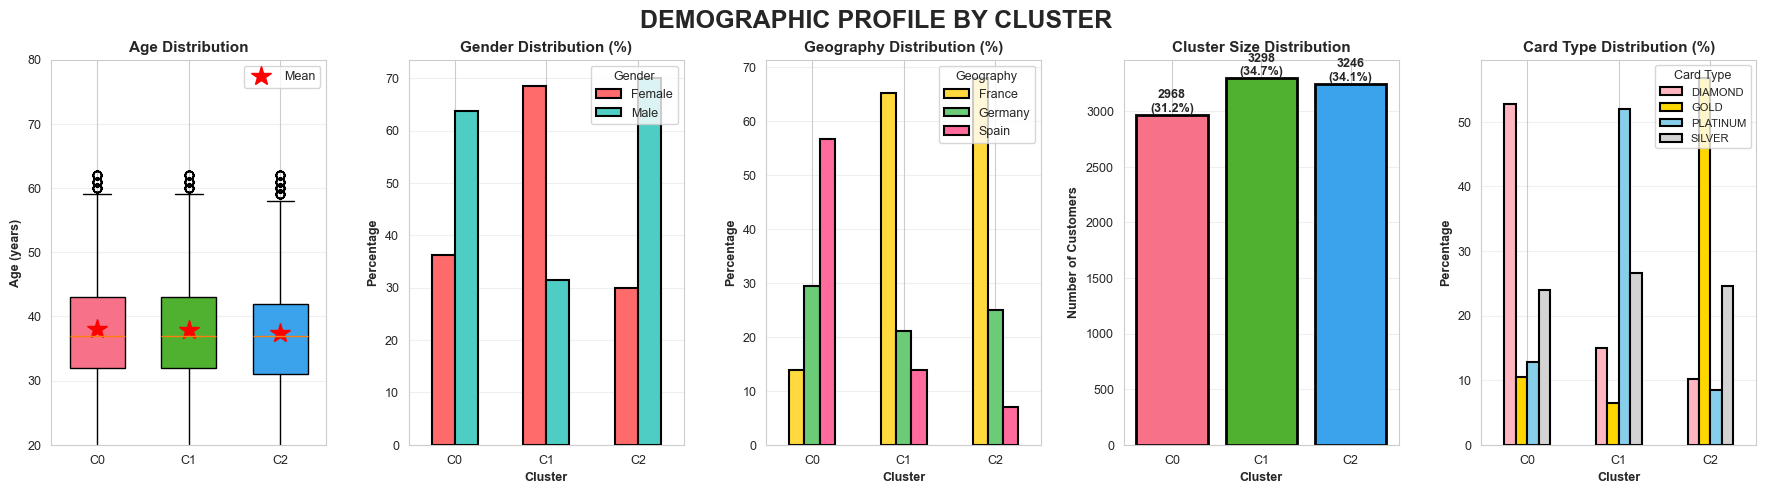

In [211]:
profile.viz_demographic_profile();

The clusters are primarily differentiated by **geographic** concentration and **card type** preference, not by fundamental demographic differences. The customer base is homogeneous in age and broadly similar in gender distribution.

#### FINANCIAL PROFILE

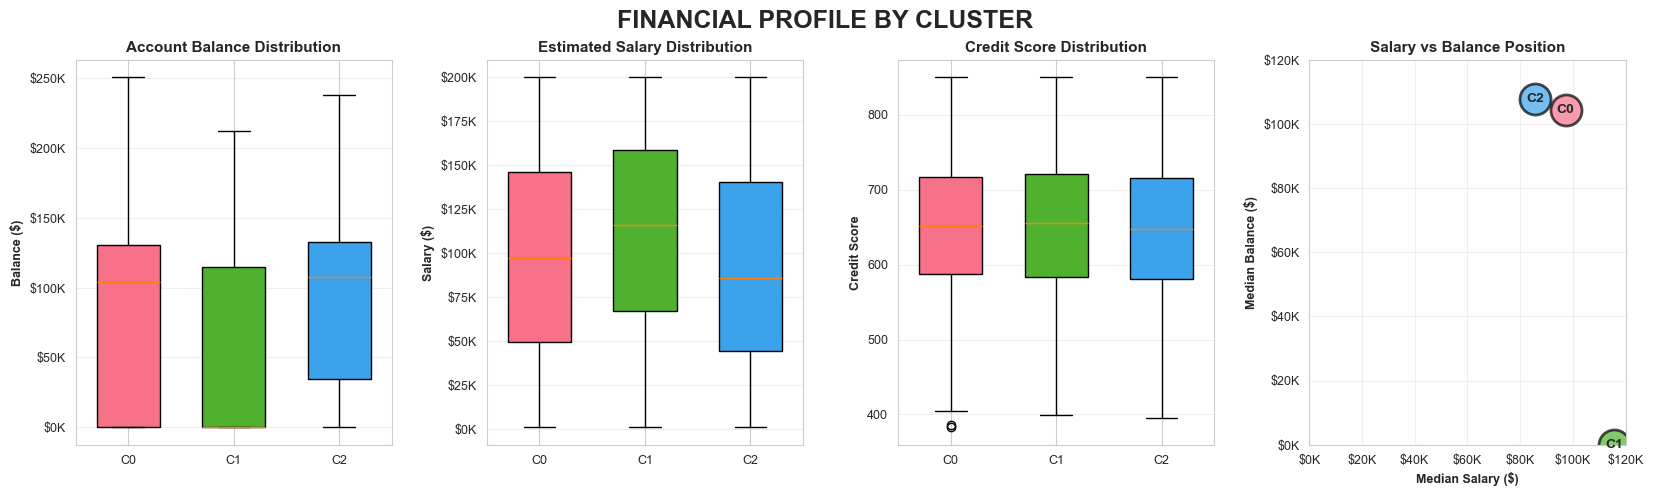

In [212]:
profile.viz_financial_profile();

#### ENGAGEMENT & BEHAVIOR

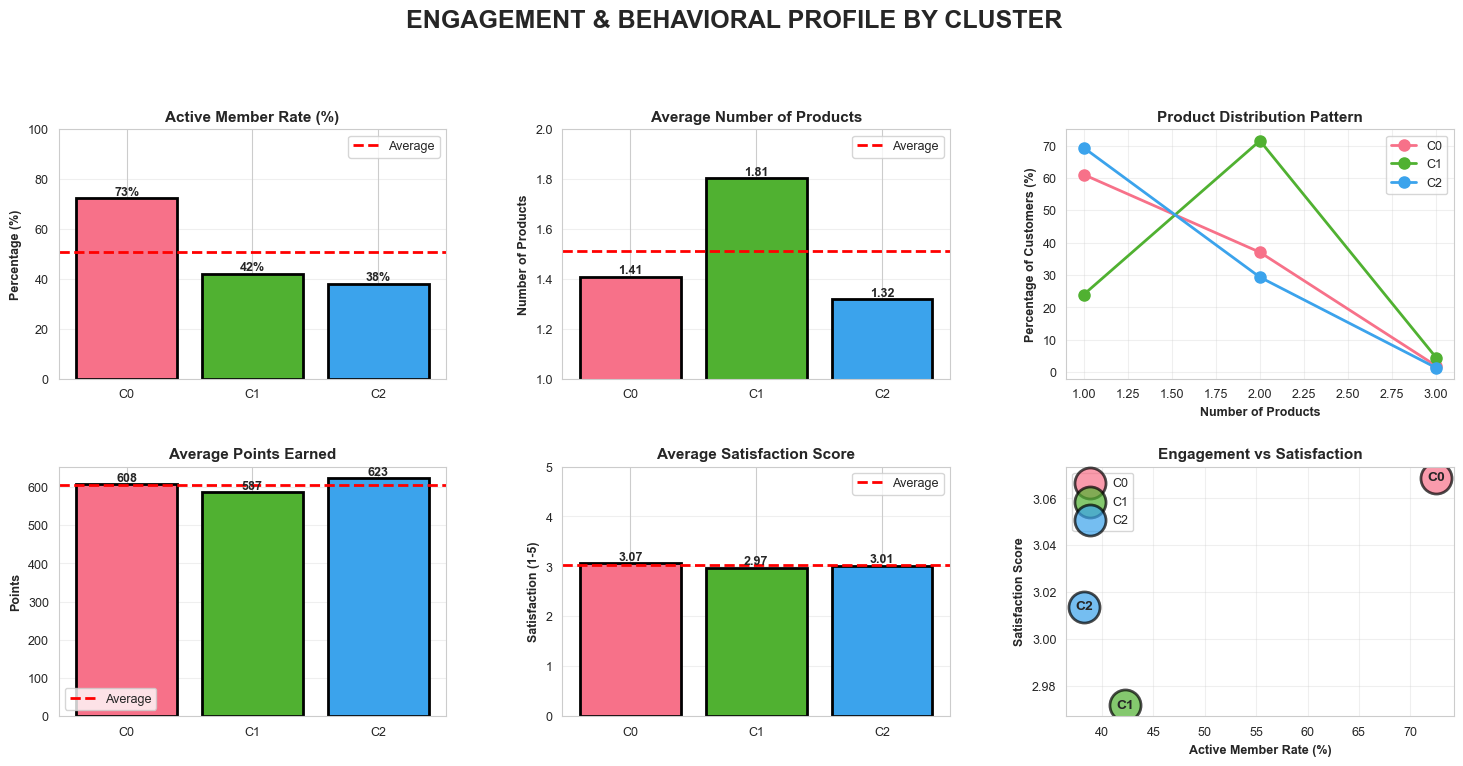

In [213]:
profile.viz_engagement_behavior();

#### CHURN & LOYALTY RISK

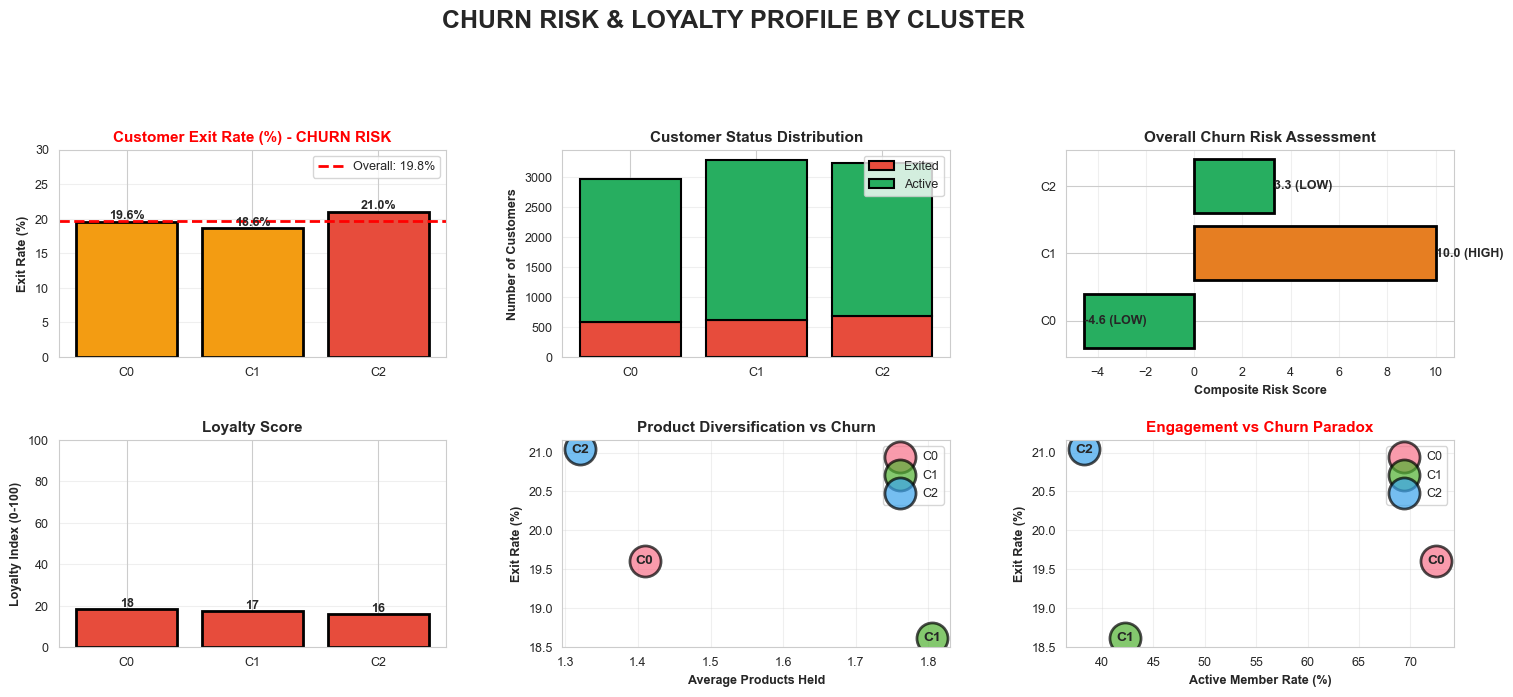

In [214]:
profile.viz_churn_loyalty();

#### HOLISTIC CLUSTER COMPARISON

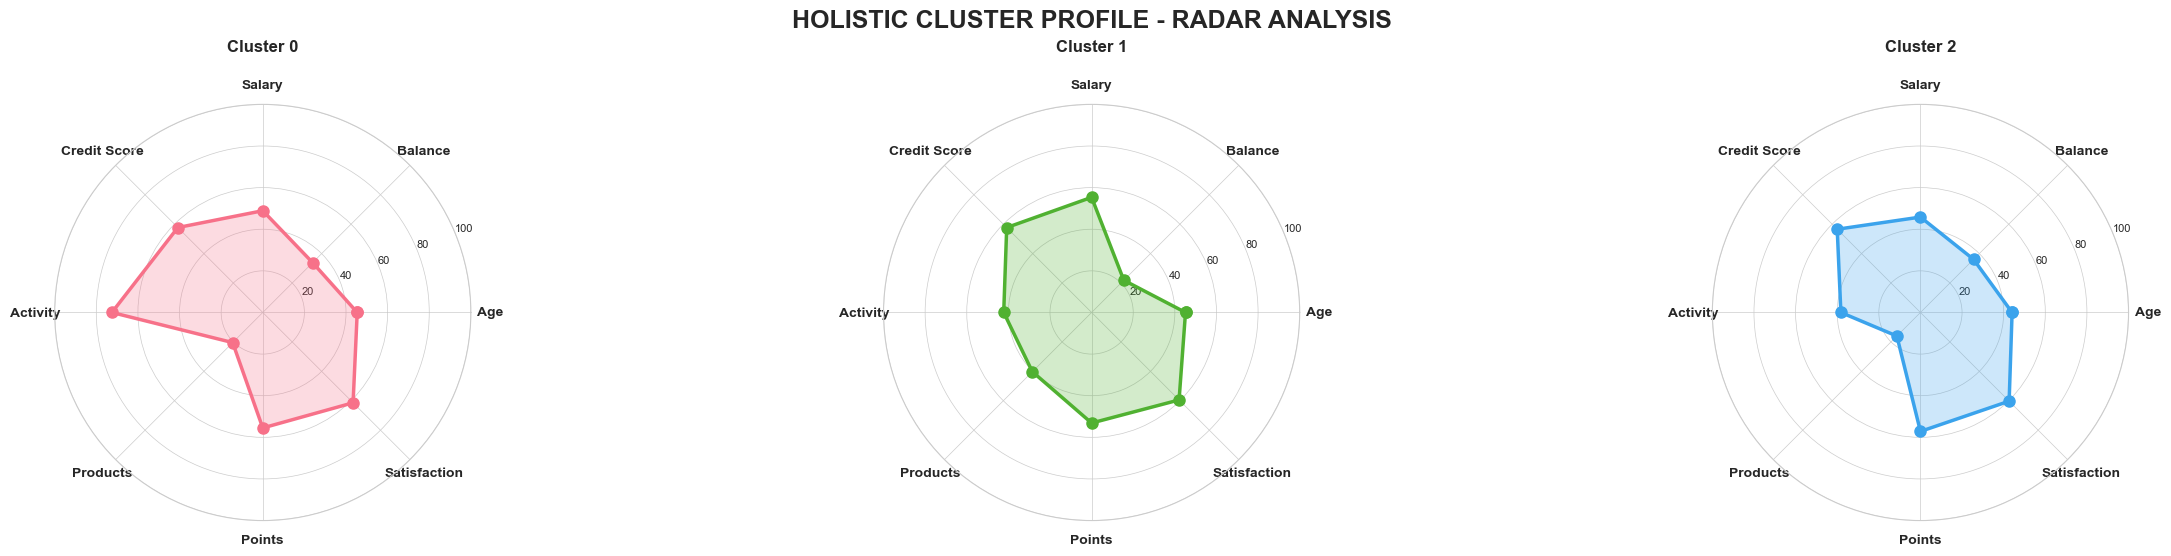

In [215]:
profile.viz_holistic_radar();

## Task 4 — Hierarchical Clustering

### Getting The best K in each method by elbow and Silhouette methods

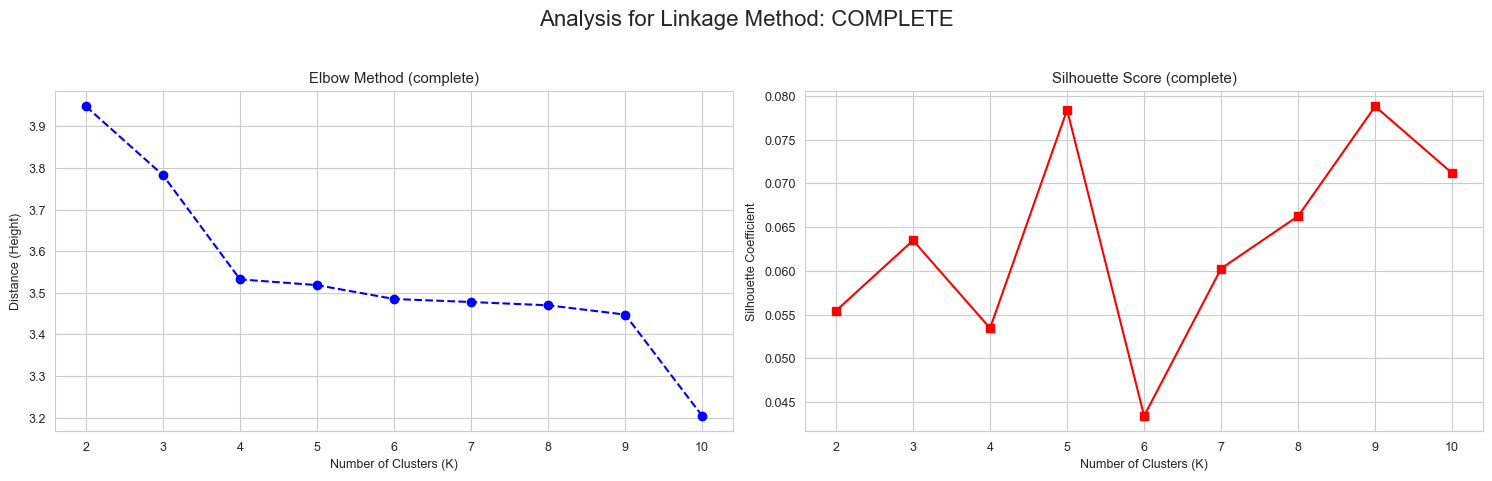

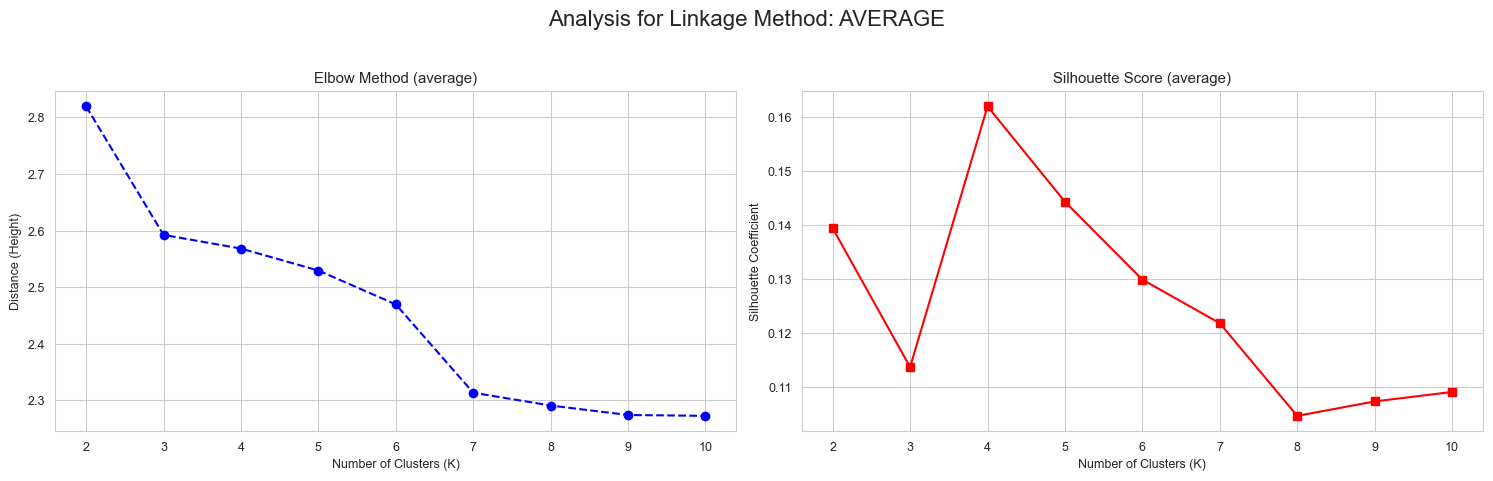

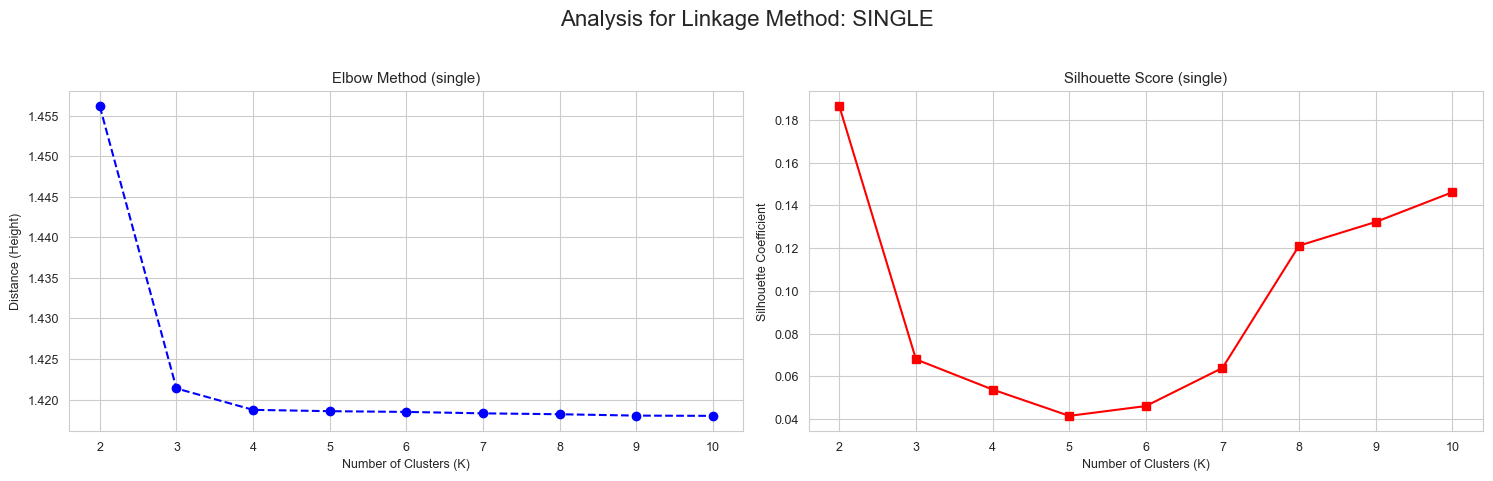

In [216]:
linkage_methods = [ 'complete', 'average', 'single']

k_range = range(2, 11)

for method in linkage_methods:
    Z = linkage(X, method=method,metric='euclidean')


    distances = Z[-9:, 2]
    distances_rev = distances[::-1]

    s_scores = []
    for k in k_range:
        labels = fcluster(Z, t=k, criterion='maxclust')
        s_scores.append(silhouette_score(X, labels))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Analysis for Linkage Method: {method.upper()}', fontsize=16)

    ax1.plot(k_range, distances_rev, marker='o', color='b', linestyle='--')
    ax1.set_title(f'Elbow Method ({method})')
    ax1.set_xlabel('Number of Clusters (K)')
    ax1.set_ylabel('Distance (Height)')
    ax1.grid(True)

    ax2.plot(k_range, s_scores, marker='s', color='r', linestyle='-')
    ax2.set_title(f'Silhouette Score ({method})')
    ax2.set_xlabel('Number of Clusters (K)')
    ax2.set_ylabel('Silhouette Coefficient')
    ax2.grid(True)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


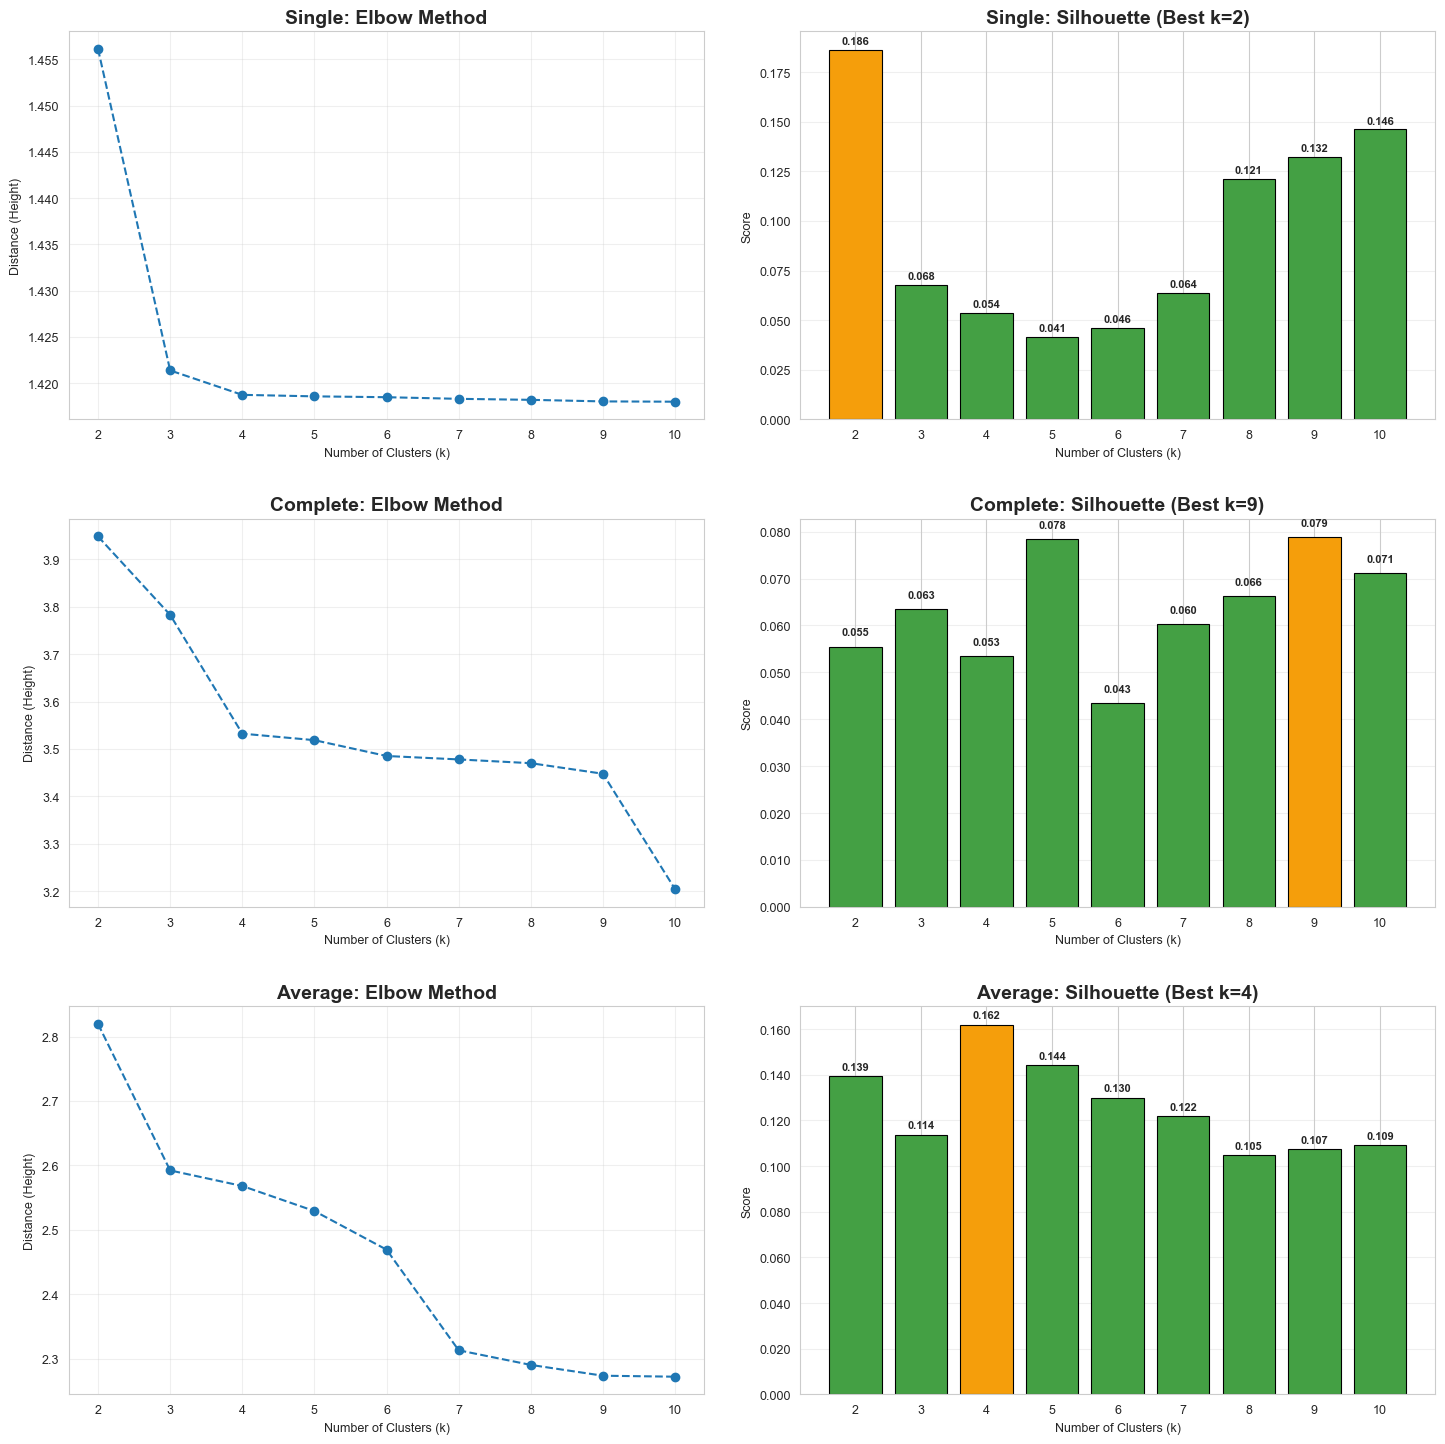

In [218]:
k_range = range(2, 11)
linkage_methods = ['single', 'complete', 'average'] 
num_methods = len(linkage_methods)


fig, axes = plt.subplots(num_methods, 2, figsize=(15, 5 * num_methods))

if num_methods == 1:
    axes = np.expand_dims(axes, axis=0) 

for i, method in enumerate(linkage_methods):
    Z = linkage(X, method=method, metric='euclidean')

    distances = Z[-(len(k_range)):, 2][::-1] 
    
    s_scores = []
    for k in k_range:
        labels = fcluster(Z, t=k, criterion='maxclust')
        s_scores.append(silhouette_score(X, labels))
    
    ax1 = axes[i, 0]
    ax1.plot(k_range, distances, marker='o', color='#1f77b4', linestyle='--')
    ax1.set_title(f'{method.capitalize()}: Elbow Method', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of Clusters (k)')
    ax1.set_ylabel('Distance (Height)')
    ax1.grid(True, alpha=0.3)

    ax2 = axes[i, 1]
    best_score_idx = np.argmax(s_scores)
    best_k = k_range[best_score_idx]
    
    colors = ['#44a044'] * len(s_scores) 
    colors[best_score_idx] = '#f59e0b' 
    
    bars = ax2.bar(k_range, s_scores, color=colors, edgecolor='black', linewidth=0.8)
    
    for bar in bars:
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + 0.002,
                 f'{height:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')
    
    ax2.set_title(f'{method.capitalize()}: Silhouette (Best k={best_k})', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of Clusters (k)')
    ax2.set_ylabel('Score')
    ax2.set_xticks(k_range)
    ax2.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
    ax2.grid(axis='y', linestyle='-', alpha=0.3)

plt.tight_layout(pad=3.0)
plt.show()

#### HOLISTIC CLUSTER COMPARISON

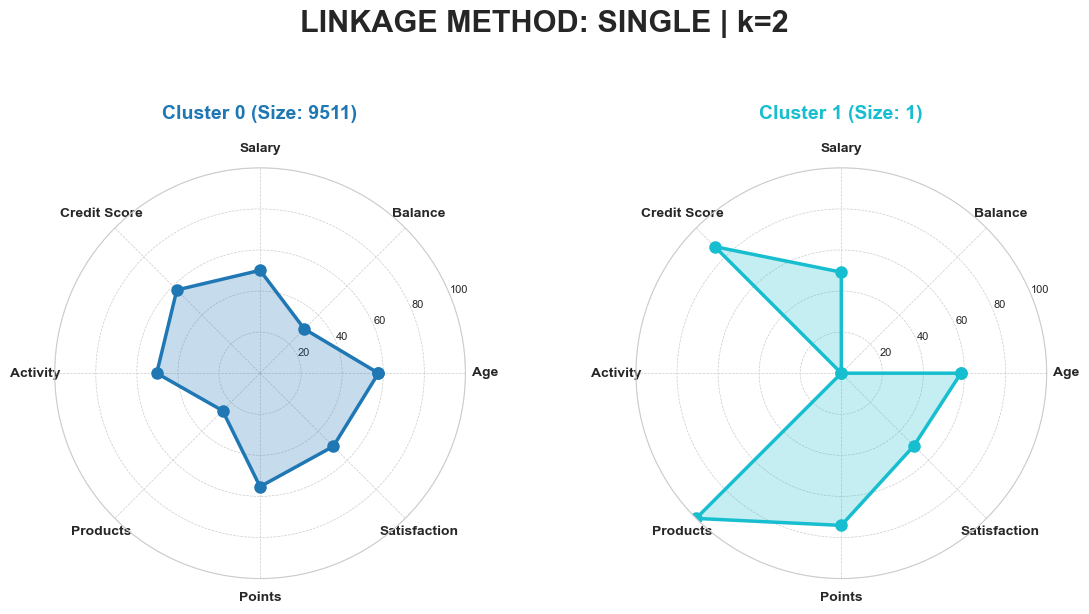

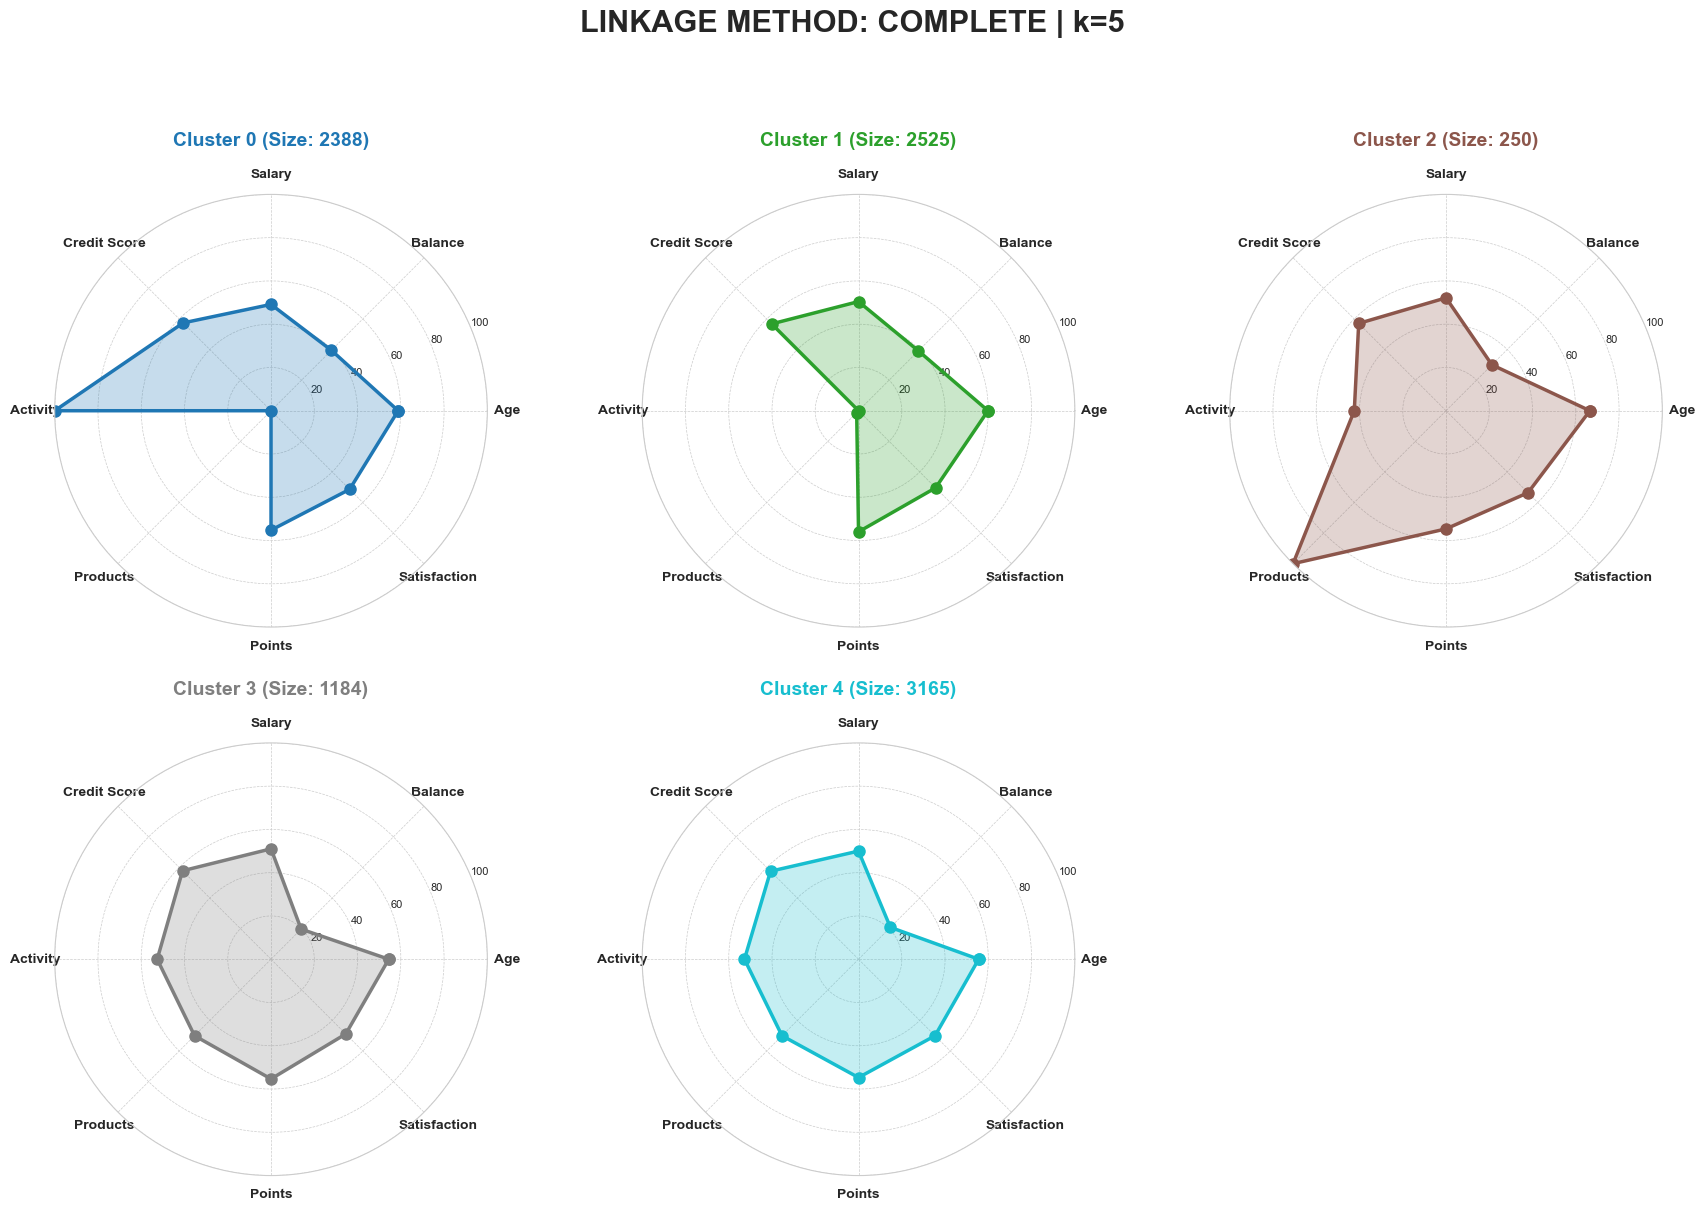

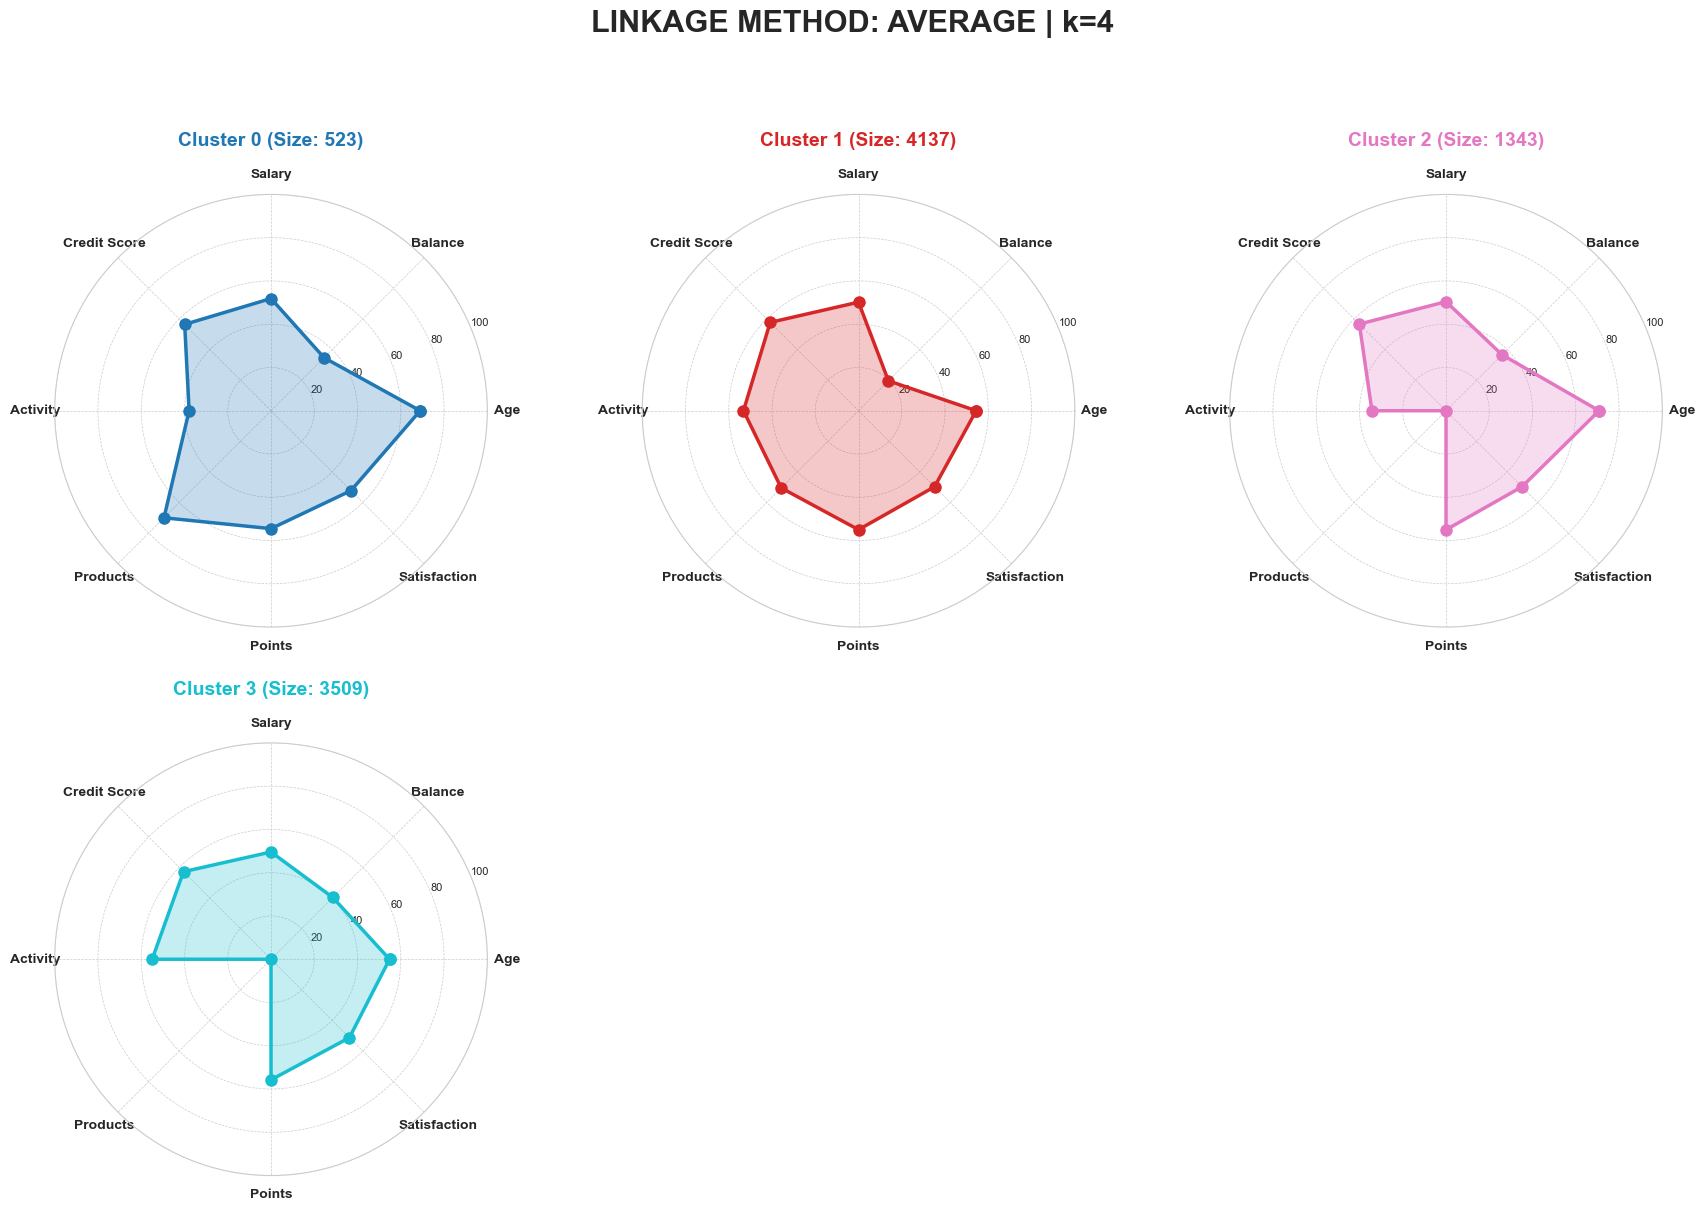

In [221]:
methods_k = {
    'single': 2,
    'complete': 5   ,
    'average': 4
}

for method, k_val in methods_k.items():
    Z = linkage(X.select_dtypes(include=[np.number]), method=method, metric='euclidean')
   
    X_temp = X.copy()
    X_temp['Cluster'] = fcluster(Z, t=k_val, criterion='maxclust')

    dimensions = ['Age', 'Balance', 'Salary', 'Credit Score', 'Activity', 'Products', 'Points', 'Satisfaction']
    n_dims = len(dimensions)
    angles = [n / float(n_dims) * 2 * pi for n in range(n_dims)]
    angles += angles[:1]

    color_map = plt.cm.get_cmap('tab10', k_val)

    n_cols = 3 if k_val > 3 else k_val
    n_rows = (k_val + n_cols - 1) // n_cols

    fig = plt.figure(figsize=(n_cols * 6, n_rows * 6))
    fig.suptitle(f'LINKAGE METHOD: {method.upper()} | k={k_val}', fontsize=22, fontweight='bold', y=1.02)

    for idx in range(k_val):
        cluster_data = X_temp[X_temp['Cluster'] == (idx + 1)]
        cluster_size = len(cluster_data)
        age_norm = (cluster_data['age'].mean() - X['age'].min()) / (X['age'].max() - X['age'].min()) * 100
        balance_norm = (cluster_data['balance'].mean() - X['balance'].min()) / (X['balance'].max() - X['balance'].min()) * 100
        salary_norm = (cluster_data['estimatedsalary'].mean() - X['estimatedsalary'].min()) / (X['estimatedsalary'].max() - X['estimatedsalary'].min()) * 100
        credit_norm = (cluster_data['creditscore'].mean() - X['creditscore'].min()) / (X['creditscore'].max() - X['creditscore'].min()) * 100
        activity_norm = cluster_data['isactivemember'].mean() * 100
        products_norm = (cluster_data['numofproducts'].mean() - X['numofproducts'].min()) / (X['numofproducts'].max() - X['numofproducts'].min()) * 100
        points_norm = (cluster_data['point earned'].mean() - X['point earned'].min()) / (X['point earned'].max() - X['point earned'].min()) * 100
        satisfaction_norm = (cluster_data['satisfaction score'].mean() / X['satisfaction score'].max()) * 100

        values = [age_norm, balance_norm, salary_norm, credit_norm, activity_norm, products_norm, points_norm, satisfaction_norm]
        values += values[:1]

        ax = fig.add_subplot(n_rows, n_cols, idx + 1, projection='polar')

        current_color = color_map(idx)
        ax.plot(angles, values, 'o-', linewidth=2.5, color=current_color, markersize=8)
        ax.fill(angles, values, alpha=0.25, color=current_color)

        ax.set_xticks(angles[:-1])
        ax.set_xticklabels(dimensions, size=10, fontweight='bold')
        ax.set_ylim(0, 100)
        ax.set_yticks([20, 40, 60, 80, 100])
        ax.set_yticklabels(['20', '40', '60', '80', '100'], size=8)
        ax.grid(True, linewidth=0.5, linestyle='--')

        ax.set_title(f'Cluster {idx} (Size: {cluster_size})', fontsize=14, fontweight='bold', pad=35, color=current_color)

    plt.tight_layout(pad=3.0)
    plt.show()
    print("="*100)

In [222]:
def plot_churn_loyalty_dashboard(df_final, n_clusters, method_name):
    """
    df_final: DataFrame contains original data + 'Cluster' column
    n_clusters: number of clusters (k)
    method_name: name of linkage method for the title
    """
    fig = plt.figure(figsize=(20, 12))
    gs = fig.add_gridspec(2, 3, hspace=0.3, wspace=0.3)

    fig.suptitle(f'CHURN RISK & LOYALTY PROFILE - METHOD: {method_name.upper()}',
                 fontsize=22, fontweight='bold', y=0.98)

    colors_list = ['#ff4d4d', '#4dff4d', '#4da6ff', '#f59e0b', '#8b5cf6', '#00ced1', '#ff1493']

    # 1. Exit Rate (Churn)
    ax1 = fig.add_subplot(gs[0, 0])
    exit_rates = [df_final[df_final['Cluster'] == i]['exited'].mean() * 100 for i in range(1, n_clusters + 1)]
    cluster_labels = [f'C{i-1}' for i in range(1, n_clusters + 1)]

    bars = ax1.bar(cluster_labels, exit_rates,
                  color=['#e74c3c' if r > 20 else '#f39c12' if r > 15 else '#27ae60' for r in exit_rates],
                  edgecolor='black', linewidth=1.5)

    ax1.set_title('Customer Exit Rate (%) - CHURN RISK', fontweight='bold', color='red')
    ax1.axhline(df_final['exited'].mean() * 100, color='red', linestyle='--', label='Overall Avg')
    ax1.set_ylim(0, max(exit_rates + [30]) * 1.2)
    ax1.legend()

    # 2. Status Distribution (Stacked Bar)
    ax2 = fig.add_subplot(gs[0, 1])
    active = [len(df_final[(df_final['Cluster'] == i) & (df_final['exited'] == 0)]) for i in range(1, n_clusters + 1)]
    exited = [len(df_final[(df_final['Cluster'] == i) & (df_final['exited'] == 1)]) for i in range(1, n_clusters + 1)]

    ax2.bar(cluster_labels, exited, label='Exited', color='#e74c3c', edgecolor='black')
    ax2.bar(cluster_labels, active, bottom=exited, label='Active', color='#27ae60', edgecolor='black')
    ax2.set_title('Customer Status Distribution', fontweight='bold')
    ax2.legend()

    # 3. Composite Risk Score
    ax3 = fig.add_subplot(gs[0, 2])
    risk_scores = []
    for i in range(1, n_clusters + 1):
        c_data = df_final[df_final['Cluster'] == i]
        risk = (c_data['exited'].mean() * 100 + (1 - c_data['isactivemember'].mean()) * 50) / 2
        risk_scores.append(risk)

    ax3.barh(cluster_labels, risk_scores, color='#34495e', edgecolor='black')
    ax3.set_title('Overall Churn Risk Assessment', fontweight='bold')
    ax3.set_xlabel('Risk Score (0-100)')

    # 4. Loyalty Score
    ax4 = fig.add_subplot(gs[1, 0])
    loyalty_scores = []
    for i in range(1, n_clusters + 1):
        c_data = df_final[df_final['Cluster'] == i]
        loyalty = ((1 - c_data['exited'].mean()) * 50 + c_data['isactivemember'].mean() * 50)
        loyalty_scores.append(loyalty)

    ax4.bar(cluster_labels, loyalty_scores, color='#2ecc71', edgecolor='black')
    ax4.set_title('Loyalty Score Index', fontweight='bold')
    ax4.set_ylim(0, 100)

    # 5. Products vs Churn (Scatter)
    ax5 = fig.add_subplot(gs[1, 1])
    for i in range(1, n_clusters + 1):
        c_data = df_final[df_final['Cluster'] == i]
        ax5.scatter(c_data['numofproducts'].mean(), c_data['exited'].mean() * 100,
                    s=1000, alpha=0.6, color=colors_list[(i-1)%len(colors_list)], edgecolors='black', label=f'C{i-1}')
        ax5.text(c_data['numofproducts'].mean(), c_data['exited'].mean() * 100, f'C{i-1}', ha='center', va='center', fontweight='bold')

    ax5.set_title('Product Diversification vs Churn', fontweight='bold')
    ax5.set_xlabel('Avg Products')
    ax5.set_ylabel('Exit Rate %')

    # 6. Engagement Paradox
    ax6 = fig.add_subplot(gs[1, 2])
    for i in range(1, n_clusters + 1):
        c_data = df_final[df_final['Cluster'] == i]
        ax6.scatter(c_data['isactivemember'].mean() * 100, c_data['exited'].mean() * 100,
                    s=1000, alpha=0.6, color=colors_list[(i-1)%len(colors_list)], edgecolors='black')
        ax6.text(c_data['isactivemember'].mean() * 100, c_data['exited'].mean() * 100, f'C{i-1}', ha='center', va='center', fontweight='bold')

    ax6.set_title('Engagement vs Churn Paradox', fontweight='bold', color='red')
    ax6.set_xlabel('Active Member Rate %')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


#### CHURN & LOYALTY RISK

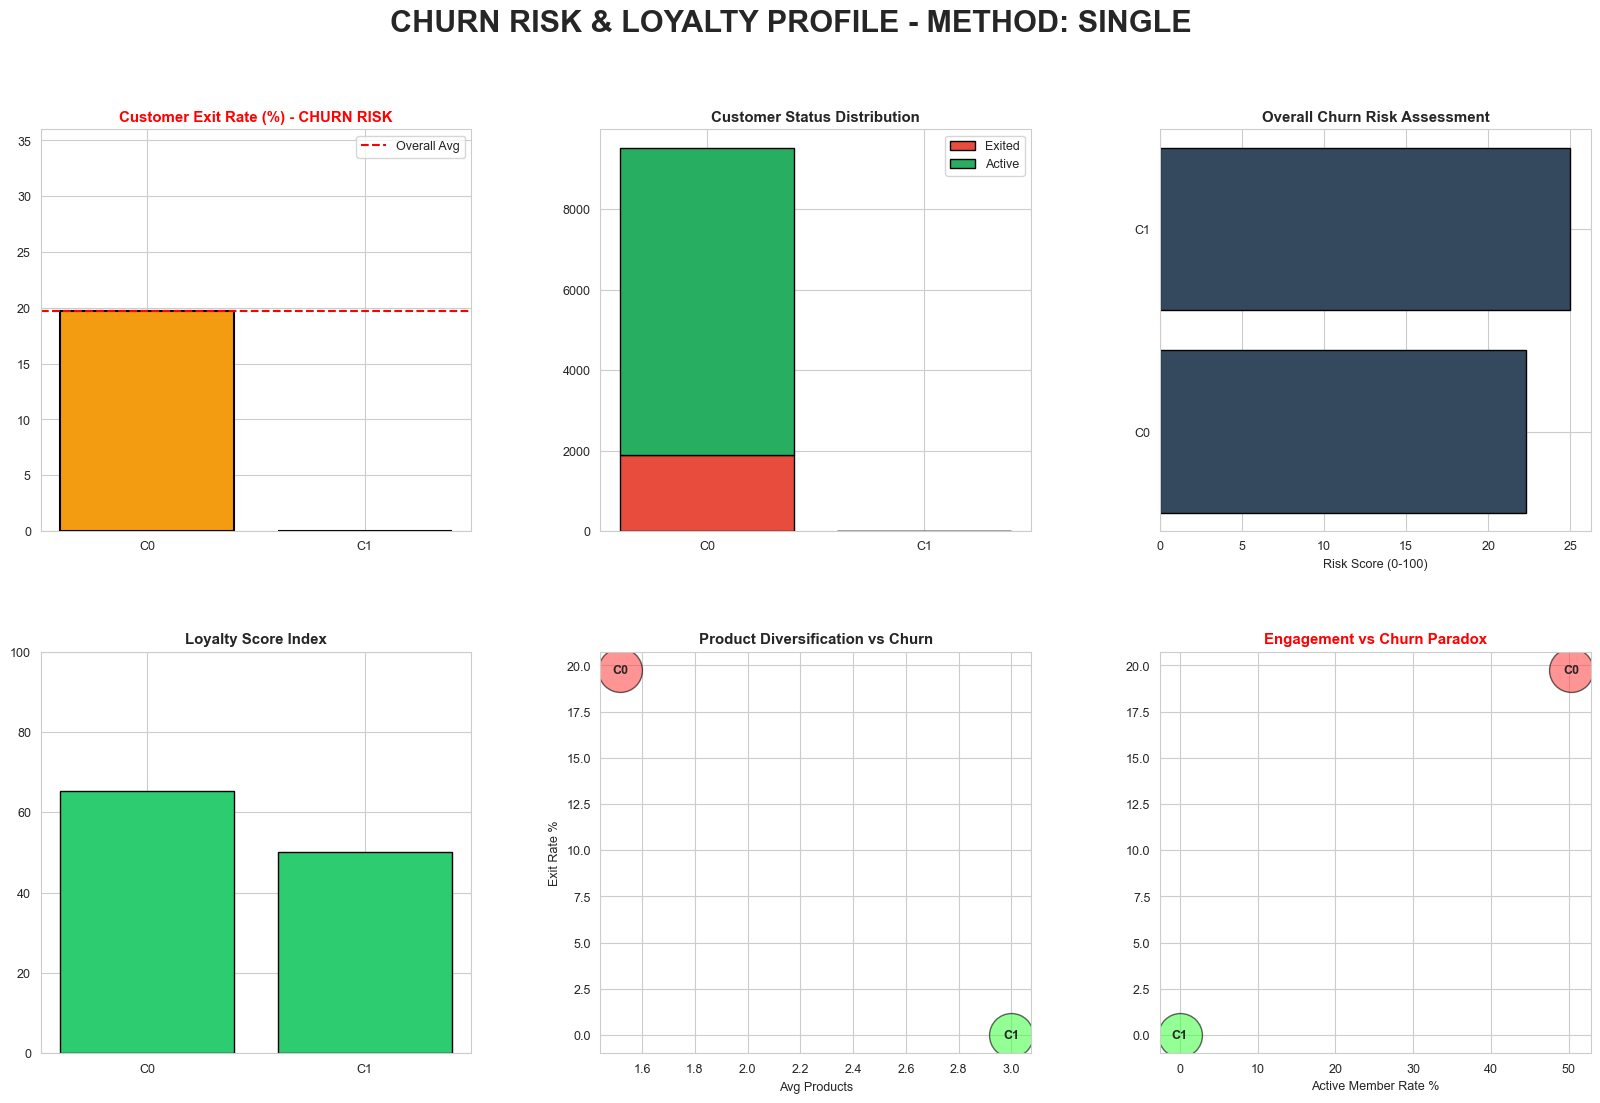

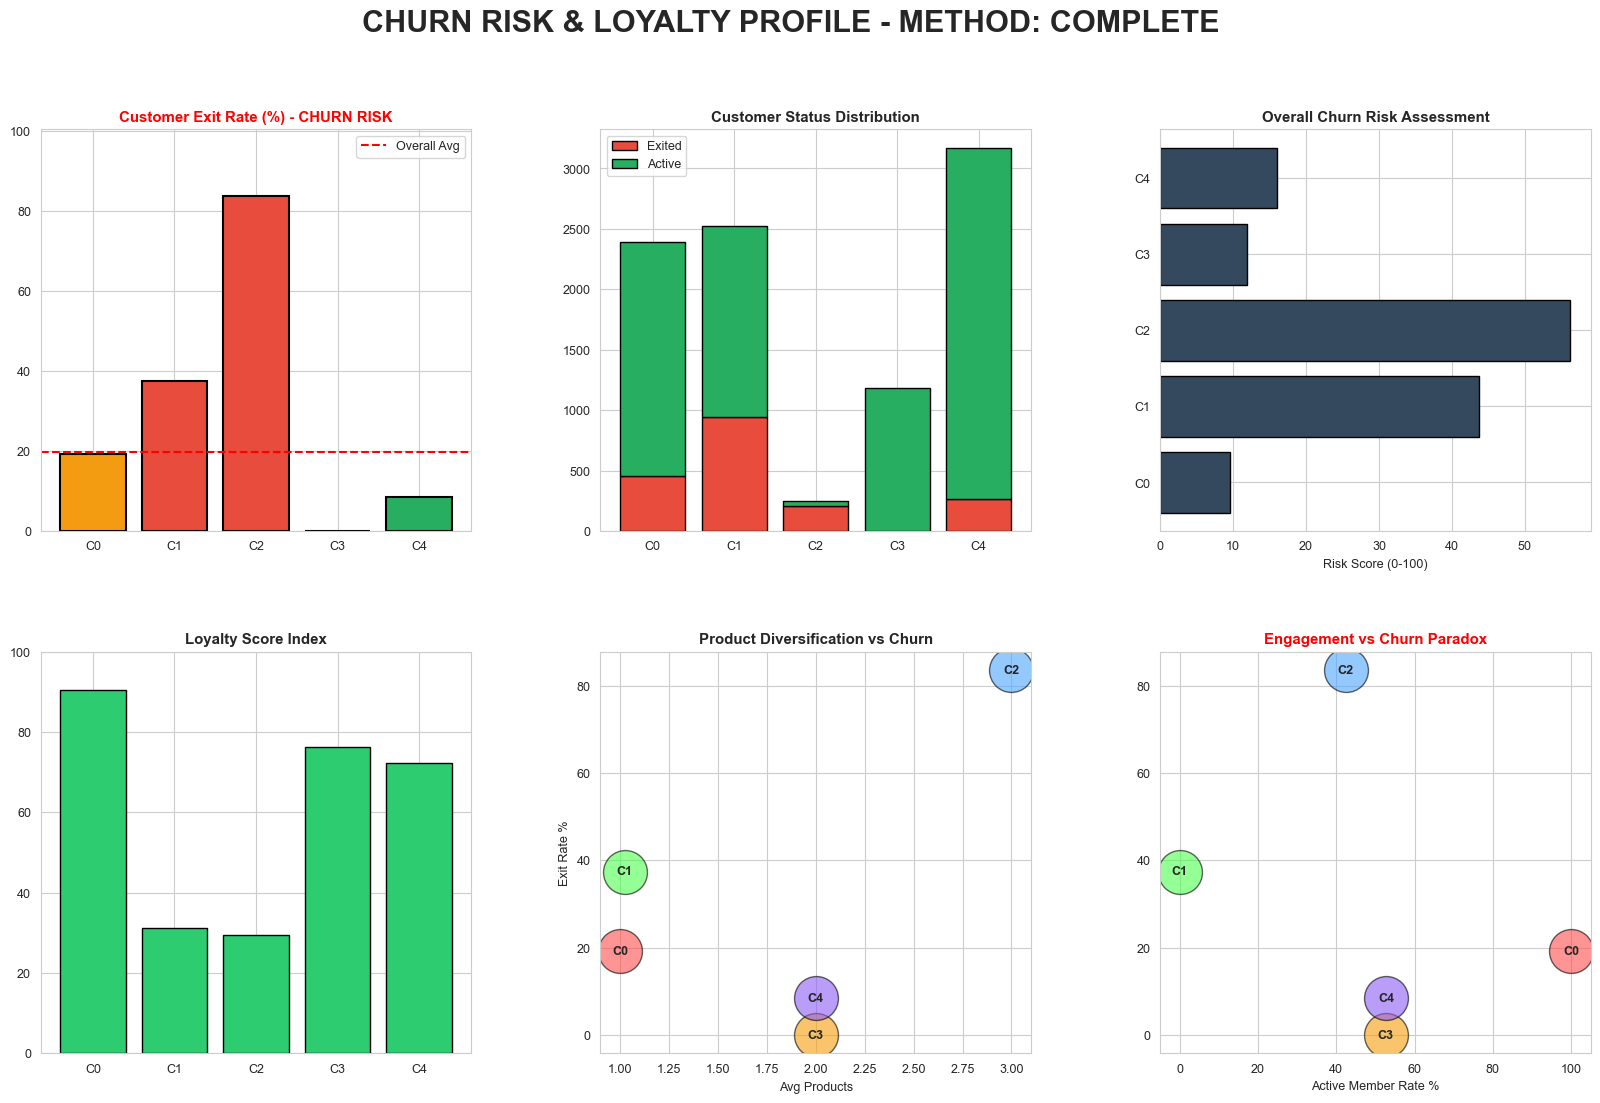

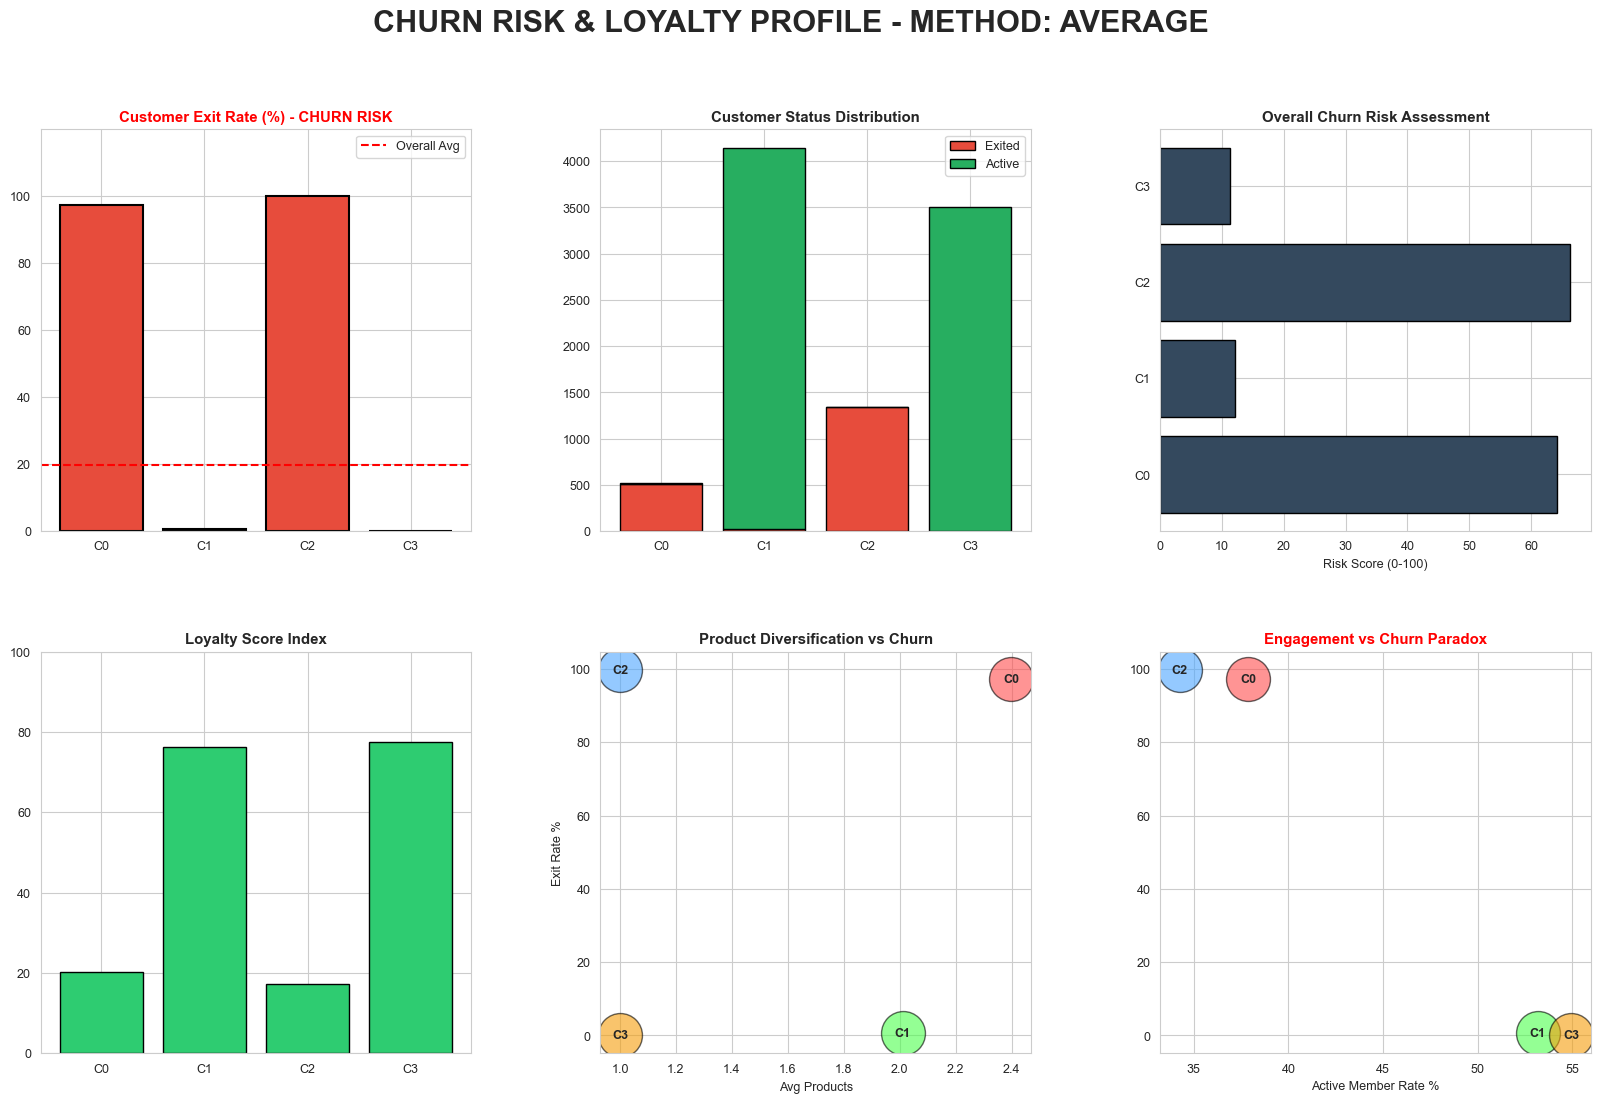

In [224]:
for method, k in {'single': 2, 'complete': 5, 'average': 4}.items():
    Z =linkage(X.select_dtypes(include=[np.number]), method=method, metric='euclidean')

    df_demo = df.loc[X.index].copy()
    df_demo['Cluster'] = fcluster(Z, t=k, criterion='maxclust')

    plot_churn_loyalty_dashboard(df_demo, k, method)

#### DEMOGRAPHIC PROFILE

In [225]:


def plot_demographic_dashboard_final(df_final, n_clusters, method_name):
    fig = plt.figure(figsize=(24, 6))
    gs = fig.add_gridspec(1, 5, hspace=0.35, wspace=0.4)

    fig.suptitle(f'DEMOGRAPHIC PROFILE - METHOD: {method_name.upper()} (k={n_clusters})',
                 fontsize=20, fontweight='bold', y=1.05)

    colors_list = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEEAD', '#D4A5A5', '#9B59B6', '#34495E', '#F1C40F']
    current_colors = colors_list[:n_clusters]

    # 1. Age
    ax1 = fig.add_subplot(gs[0, 0])
    age_data = [df_final[df_final['Cluster'] == i]['age'] for i in range(1, n_clusters + 1)]
    bp1 = ax1.boxplot(age_data, labels=[f'C{i-1}' for i in range(1, n_clusters + 1)], patch_artist=True, widths=0.6)
    for patch, color in zip(bp1['boxes'], current_colors):
        patch.set_facecolor(color)
    ax1.set_title('Age Distribution', fontweight='bold')

    # 2. Gender
    ax2 = fig.add_subplot(gs[0, 1])
    gender_data = pd.crosstab(df_final['Cluster'], df_final['gender'])
    gender_pct = gender_data.div(gender_data.sum(axis=1), axis=0) * 100
    gender_pct.plot(kind='bar', ax=ax2, color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
    ax2.set_title('Gender (%)', fontweight='bold')
    ax2.set_xticklabels([f'C{i-1}' for i in range(1, n_clusters + 1)], rotation=0)

    # 3. Geography
    ax3 = fig.add_subplot(gs[0, 2])
    geo_data = pd.crosstab(df_final['Cluster'], df_final['geography'])
    geo_pct = geo_data.div(geo_data.sum(axis=1), axis=0) * 100
    geo_pct.plot(kind='bar', ax=ax3, edgecolor='black')
    ax3.set_title('Geography (%)', fontweight='bold')
    ax3.set_xticklabels([f'C{i-1}' for i in range(1, n_clusters + 1)], rotation=0)

    # 4. Cluster Size
    ax4 = fig.add_subplot(gs[0, 3])
    sizes = df_final['Cluster'].value_counts().sort_index()
    ax4.bar([f'C{i-1}' for i in range(1, n_clusters + 1)], sizes, color=current_colors, edgecolor='black')
    ax4.set_title('Cluster Size', fontweight='bold')


    plt.tight_layout()
    plt.show()



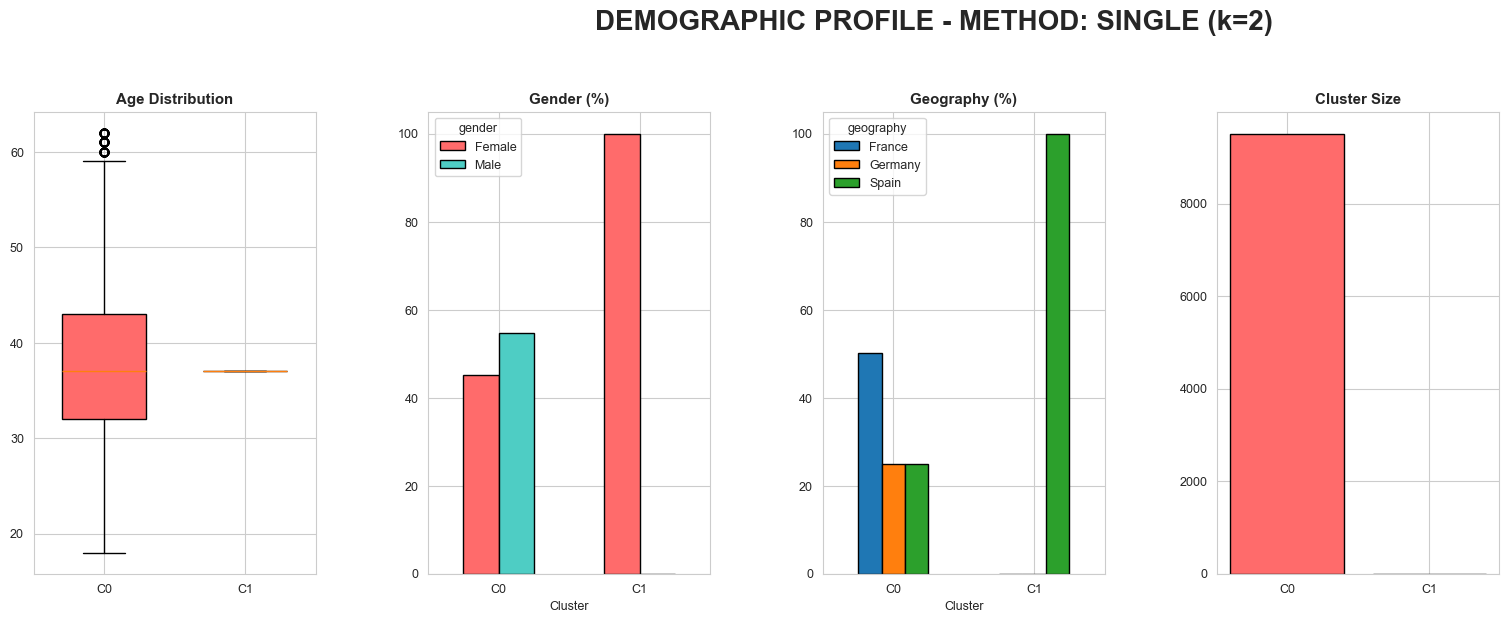

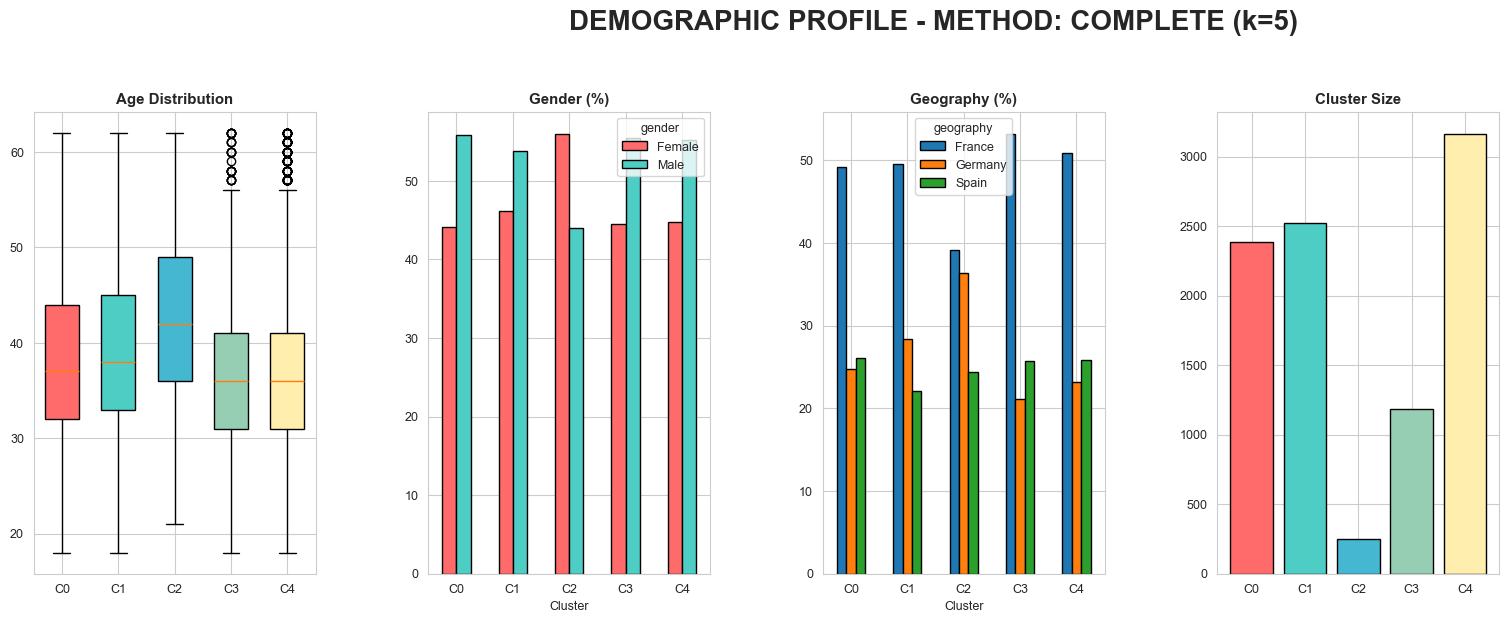

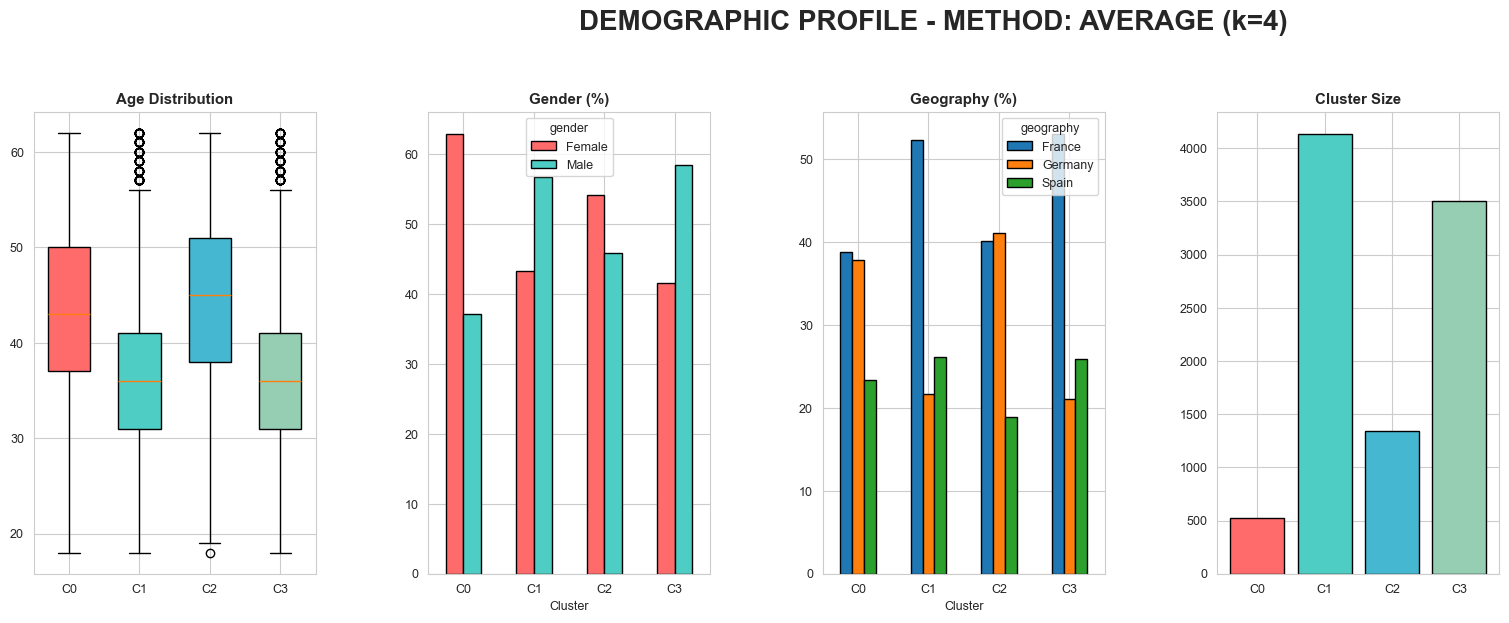

In [226]:
for method, k in {'single': 2, 'complete': 5, 'average': 4}.items():
    Z = linkage(X.select_dtypes(include=[np.number]), method=method, metric='euclidean')

    df_demo = df.loc[X.index].copy()
    df_demo['Cluster'] = fcluster(Z, t=k, criterion='maxclust')

    plot_demographic_dashboard_final(df_demo, k, method)

#### ENGAGEMENT & BEHAVIOR

In [227]:
def plot_behavioral_dashboard(df_final, n_clusters, method_name):
    fig = plt.figure(figsize=(18, 12))
    gs = fig.add_gridspec(2, 3, hspace=0.35, wspace=0.3)
    fig.suptitle(f'ENGAGEMENT & BEHAVIORAL PROFILE - {method_name.upper()} (k={n_clusters})',
                 fontsize=18, fontweight='bold', y=.98)

    colors_list = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEEAD', '#D4A5A5', '#9B59B6', '#34495E', '#F1C40F']
    current_colors = colors_list[:n_clusters]

    # 1. Active Member Rate
    ax1 = fig.add_subplot(gs[0, 0])
    active_rates = [df_final[df_final['Cluster'] == i]['isactivemember'].mean() * 100 for i in range(1, n_clusters+1)]
    bars = ax1.bar([f'C{i-1}' for i in range(1, n_clusters+1)], active_rates, color=current_colors, edgecolor='black')
    ax1.set_title('Active Member Rate (%)', fontweight='bold')
    ax1.axhline(np.mean(active_rates), color='red', linestyle='--', label='Average')
    ax1.legend()

    # 2. Average Number of Products
    ax2 = fig.add_subplot(gs[0, 1])
    avg_prods = [df_final[df_final['Cluster'] == i]['numofproducts'].mean() for i in range(1, n_clusters+1)]
    ax2.bar([f'C{i-1}' for i in range(1, n_clusters+1)], avg_prods, color=current_colors, edgecolor='black')
    ax2.set_title('Average Number of Products', fontweight='bold')
    ax2.axhline(np.mean(avg_prods), color='red', linestyle='--')

    # 3. Product Distribution Pattern
    ax3 = fig.add_subplot(gs[0, 2])
    for i in range(1, n_clusters+1):
        cluster_data = df_final[df_final['Cluster'] == i]
        prods = cluster_data['numofproducts'].value_counts().sort_index()
        ax3.plot(prods.index, prods.values / len(cluster_data) * 100, marker='o', label=f'C{i-1}', color=current_colors[i-1])
    ax3.set_title('Product Distribution Pattern', fontweight='bold')
    ax3.legend()

    # 4. Average Points Earned
    ax4 = fig.add_subplot(gs[1, 0])
    points = [df_final[df_final['Cluster'] == i]['point earned'].mean() for i in range(1, n_clusters+1)]
    ax4.bar([f'C{i-1}' for i in range(1, n_clusters+1)], points, color=current_colors, edgecolor='black')
    ax4.set_title('Average Points Earned', fontweight='bold')

    # 5. Average Satisfaction Score
    ax5 = fig.add_subplot(gs[1, 1])
    sat_score = [df_final[df_final['Cluster'] == i]['satisfaction score'].mean() for i in range(1, n_clusters+1)]
    ax5.bar([f'C{i-1}' for i in range(1, n_clusters+1)], sat_score, color=current_colors, edgecolor='black')
    ax5.set_title('Average Satisfaction Score', fontweight='bold')
    ax5.set_ylim(0, 5)

    # 6. Engagement vs Satisfaction (Scatter)
    ax6 = fig.add_subplot(gs[1, 2])
    for i in range(1, n_clusters+1):
        c_data = df_final[df_final['Cluster'] == i]
        ax6.scatter(c_data['isactivemember'].mean()*100, c_data['satisfaction score'].mean(),
                    s=300, color=current_colors[i-1], edgecolors='black', label=f'C{i-1}')
    ax6.set_title('Engagement vs Satisfaction', fontweight='bold')
    ax6.set_xlabel('Active Rate %')
    ax6.set_ylabel('Satisfaction')

    plt.tight_layout()
    plt.show()


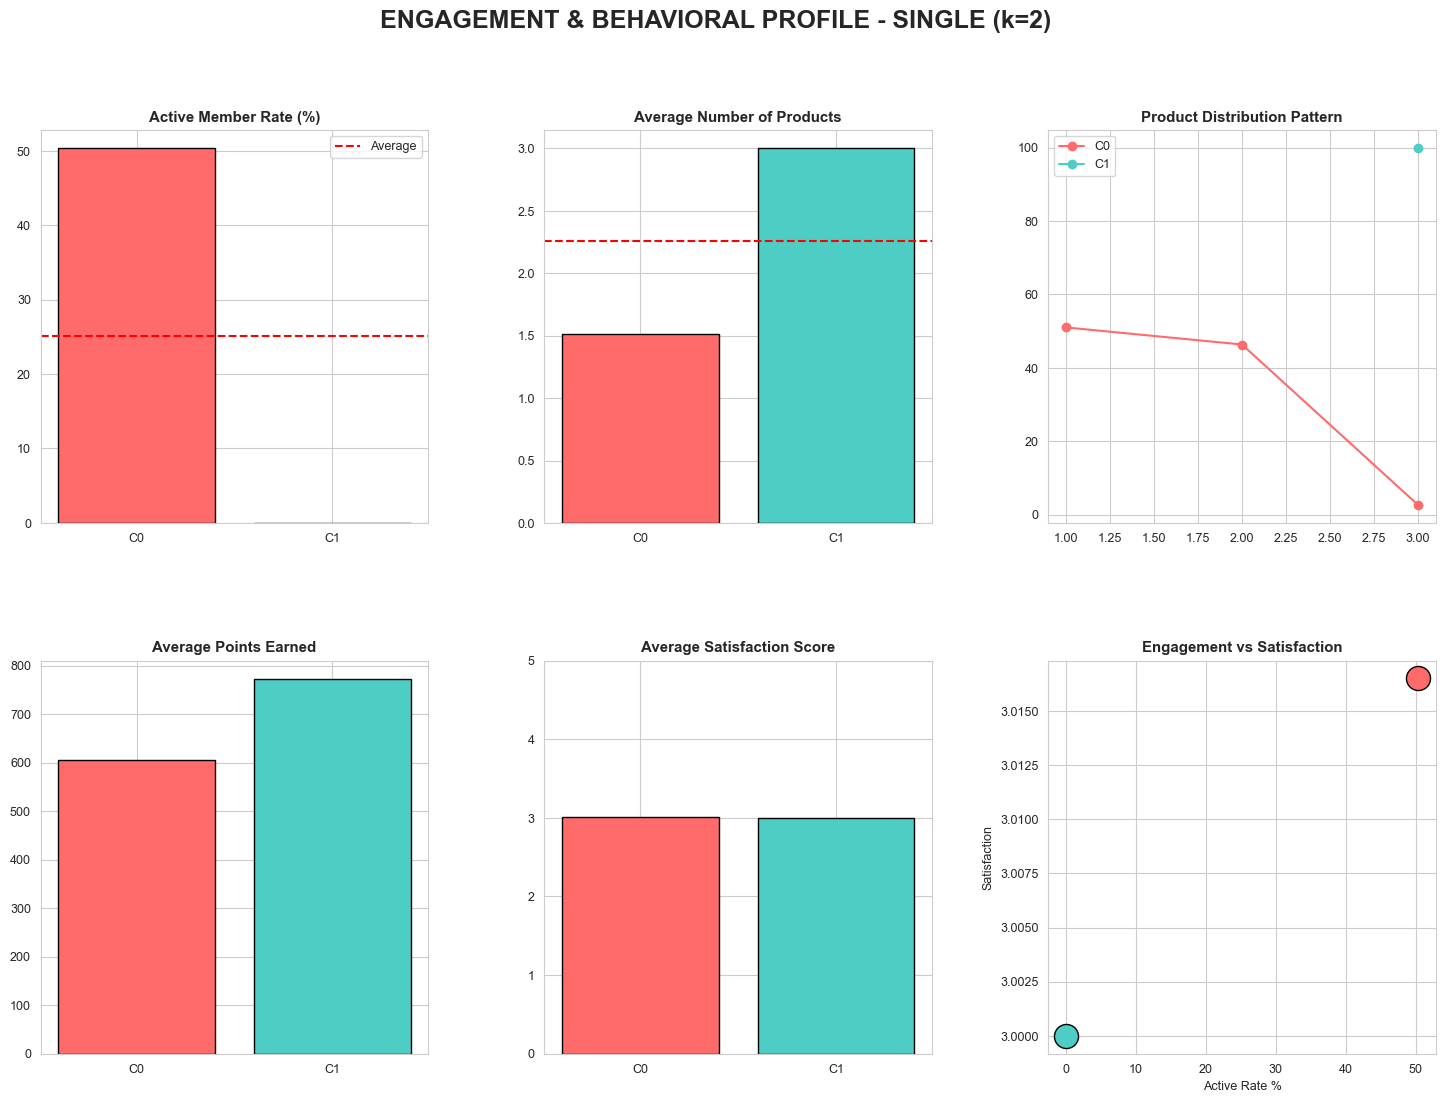

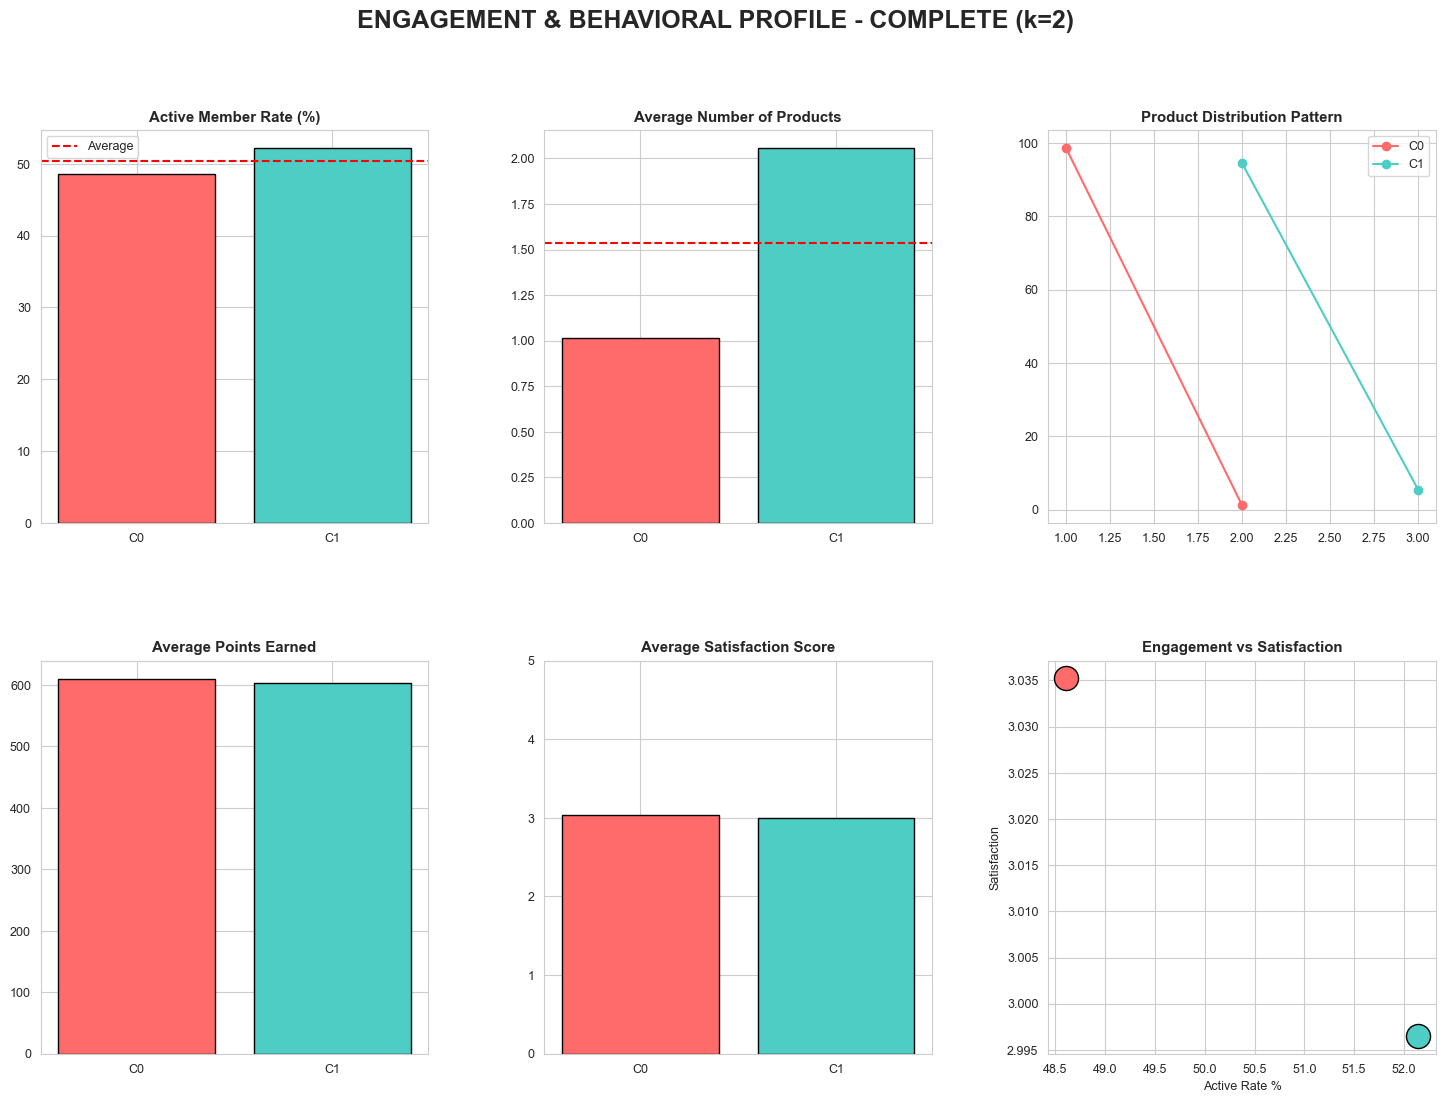

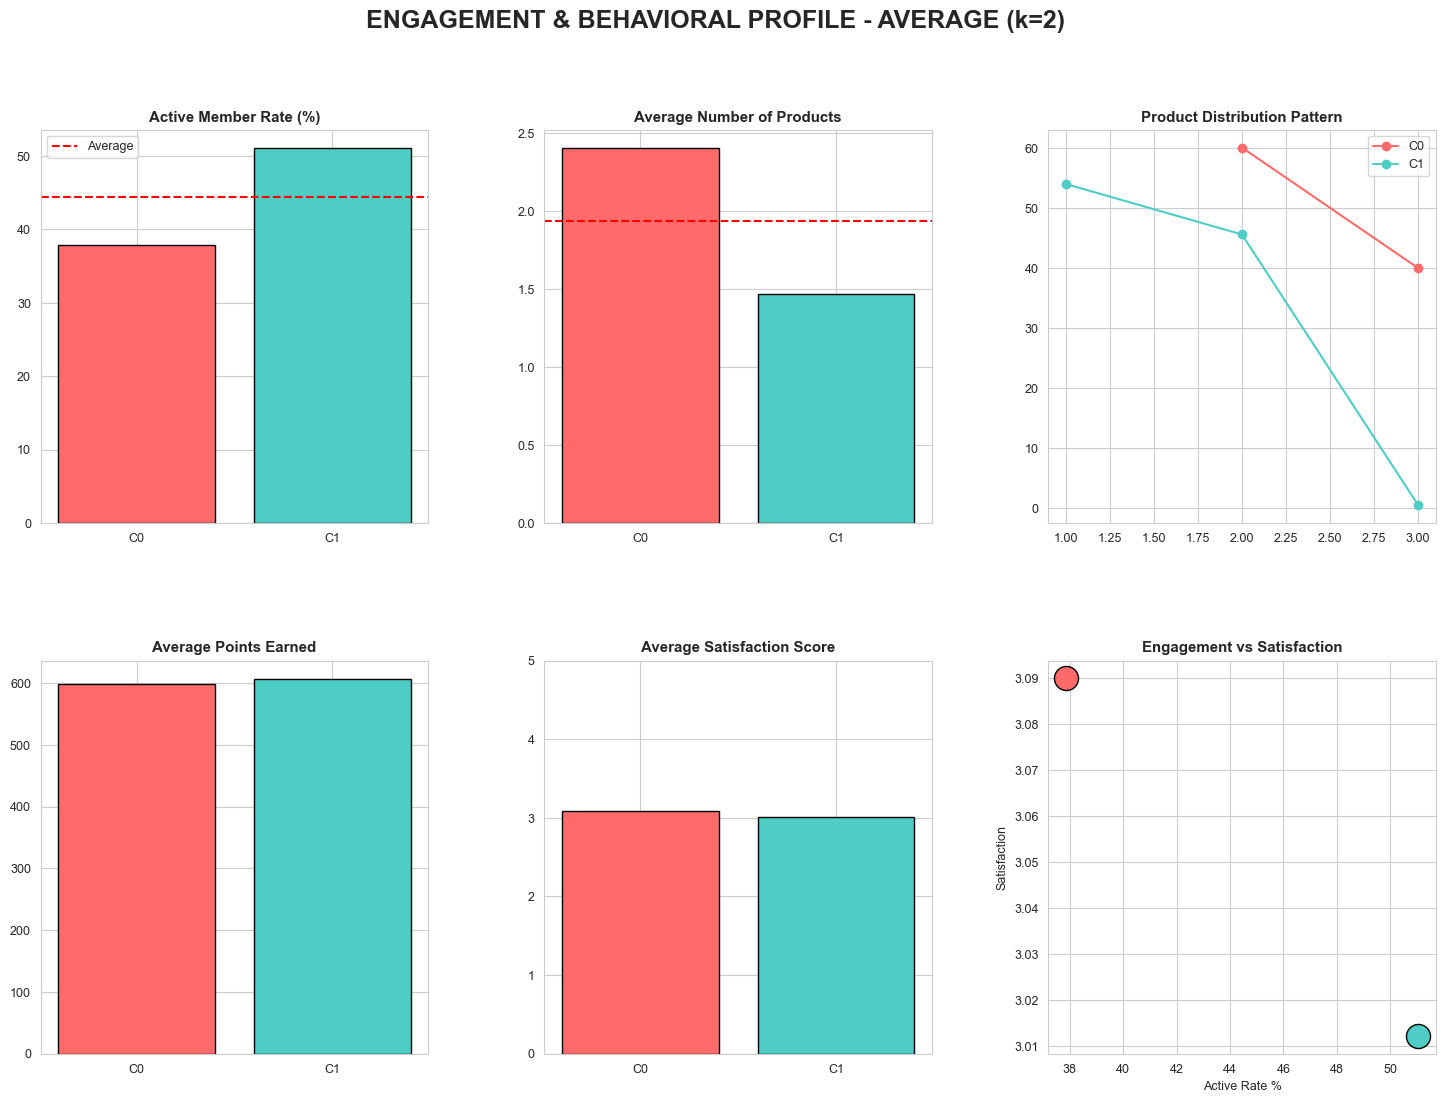

In [228]:
for method, k in {'single': 2, 'complete': 2
, 'average': 2}.items():
    Z =linkage(X.select_dtypes(include=[np.number]), method=method)

    df_demo = df.loc[X.index].copy()
    df_demo['Cluster'] = fcluster(Z, t=k, criterion='maxclust')

    plot_behavioral_dashboard(df_demo, k, method)

## Task 5 — Fuzzy Logic Inference System

### 1.setting the Antecedent & Consequent

In [229]:
age = ctrl.Antecedent(np.arange(2.9, 4.15, 0.01), 'age')
balance = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'balance')
activity = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'activity')
satisfaction = ctrl.Antecedent(np.arange(0, 1.01, 0.01), 'satisfaction')
cluster = ctrl.Antecedent(np.arange(0, 3, 1), 'cluster')

churn = ctrl.Consequent(np.arange(0, 101, 1), 'churn')

### 2.making our triangle MF

In [230]:
age['young'] = fuzz.trimf(age.universe, [2.9, 2.9, 3.4])
age['middle'] = fuzz.trimf(age.universe, [2.9, 3.6, 3.7])
age['old'] = fuzz.trimf(age.universe, [3.6, 4.15, 4.15])

# BALANCE
balance['low'] = fuzz.trimf(balance.universe, [0, 0, 0.5])
balance['medium'] = fuzz.trimf(balance.universe, [0.2, 0.5, 0.8])
balance['high'] = fuzz.trimf(balance.universe, [0.5, 1, 1])

# ACTIVITY
activity['low'] = fuzz.trimf(activity.universe, [0, 0, 0.5])
activity['high'] = fuzz.trimf(activity.universe, [0.5, 1, 1])

# SATISFACTION
satisfaction['low'] = fuzz.trimf(satisfaction.universe, [0, 0, 0.5])
satisfaction['medium'] = fuzz.trimf(satisfaction.universe, [0.2, 0.5, 0.8])
satisfaction['high'] = fuzz.trimf(satisfaction.universe, [0.5, 1, 1])

# CLUSTER (soft influence only)
cluster['c0'] = fuzz.trimf(cluster.universe, [0, 0, 1])
cluster['c1'] = fuzz.trimf(cluster.universe, [0, 1, 2])
cluster['c2'] = fuzz.trimf(cluster.universe, [1, 2, 2])

# OUTPUT
churn['low'] = fuzz.trimf(churn.universe, [0, 0, 40])
churn['medium'] = fuzz.trimf(churn.universe, [30, 50, 70])
churn['high'] = fuzz.trimf(churn.universe, [60, 100, 100])

### 3.Setting Rules

In [231]:
rules = [

    # =====================
    # CORE BEHAVIOR RULES
    # =====================
    ctrl.Rule(activity['low'] & satisfaction['low'], churn['high']),
    ctrl.Rule(activity['high'] & satisfaction['high'], churn['low']),
    ctrl.Rule(activity['low'] & satisfaction['medium'], churn['medium']),

    # =====================
    # AGE EFFECT
    # =====================
    ctrl.Rule(age['old'] & activity['low'], churn['high']),
    ctrl.Rule(age['young'] & activity['high'], churn['low']),

    # =====================
    # BALANCE EFFECT
    # =====================
    ctrl.Rule(balance['high'] & activity['low'], churn['high']),
    ctrl.Rule(balance['low'] & activity['high'], churn['low']),

    # =====================
    # SATISFACTION DOMINANCE
    # =====================
    ctrl.Rule(satisfaction['low'], churn['high']),
    ctrl.Rule(satisfaction['high'] & activity['high'], churn['low']),

    # =====================
    # CLUSTER (WEAK INFLUENCE)
    # =====================
    ctrl.Rule(cluster['c2'] & satisfaction['low'], churn['high']),
    ctrl.Rule(cluster['c1'] & activity['high'], churn['low']),
    ctrl.Rule(cluster['c0'] & activity['low'], churn['medium']),

    # =====================
    # MIXED INTELLIGENT RULES
    # =====================
    ctrl.Rule(age['middle'] & balance['medium'] & activity['high'], churn['low']),
    ctrl.Rule(age['old'] & balance['low'] & satisfaction['low'], churn['high']),
    ctrl.Rule(balance['high'] & satisfaction['high'], churn['medium']),
]

### 4.Views

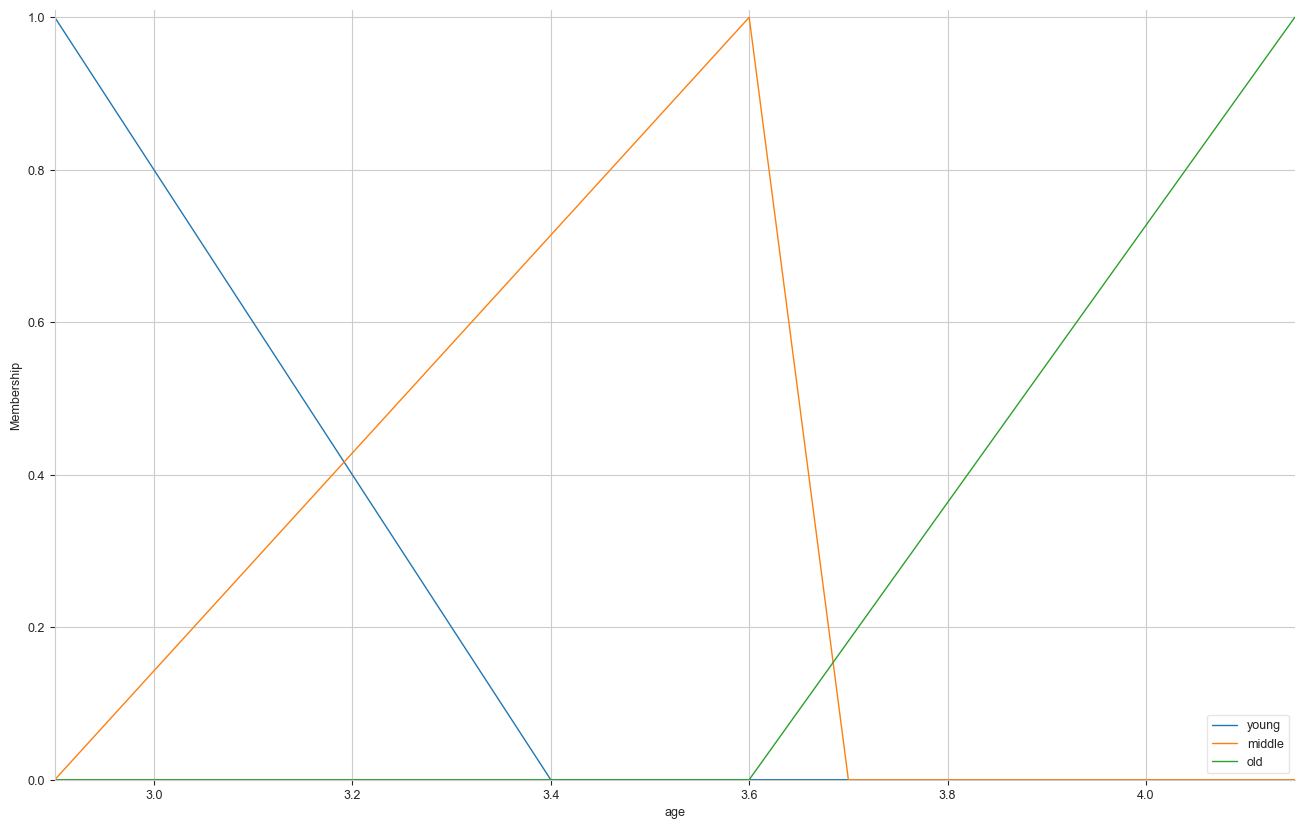

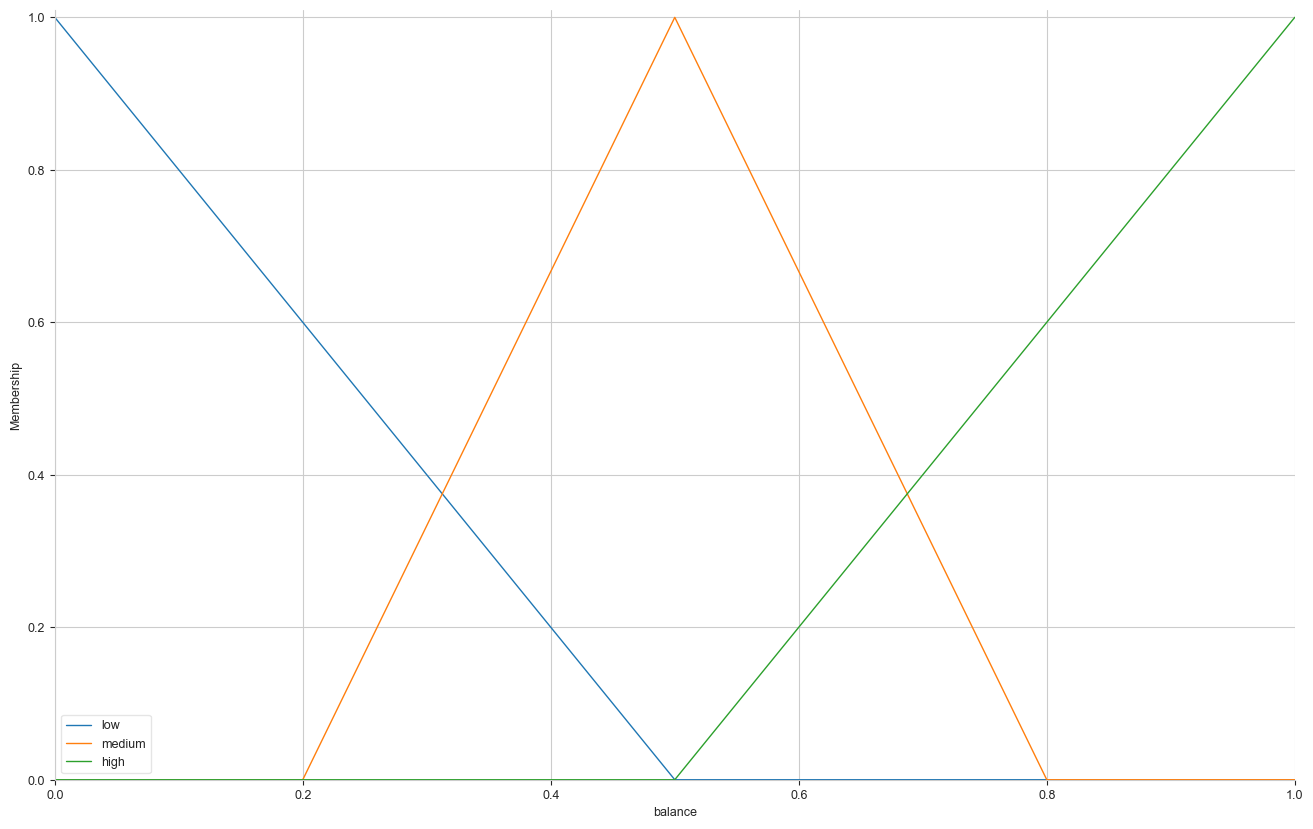

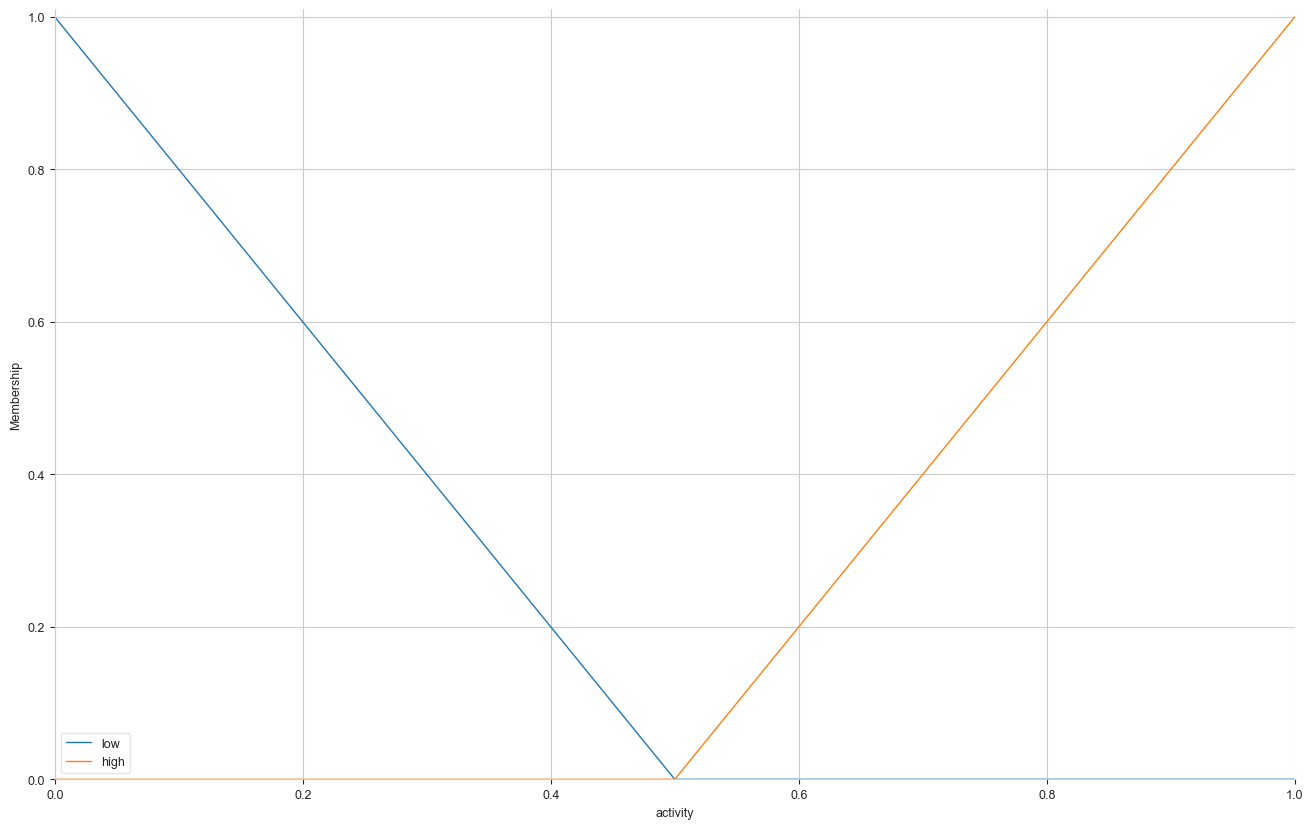

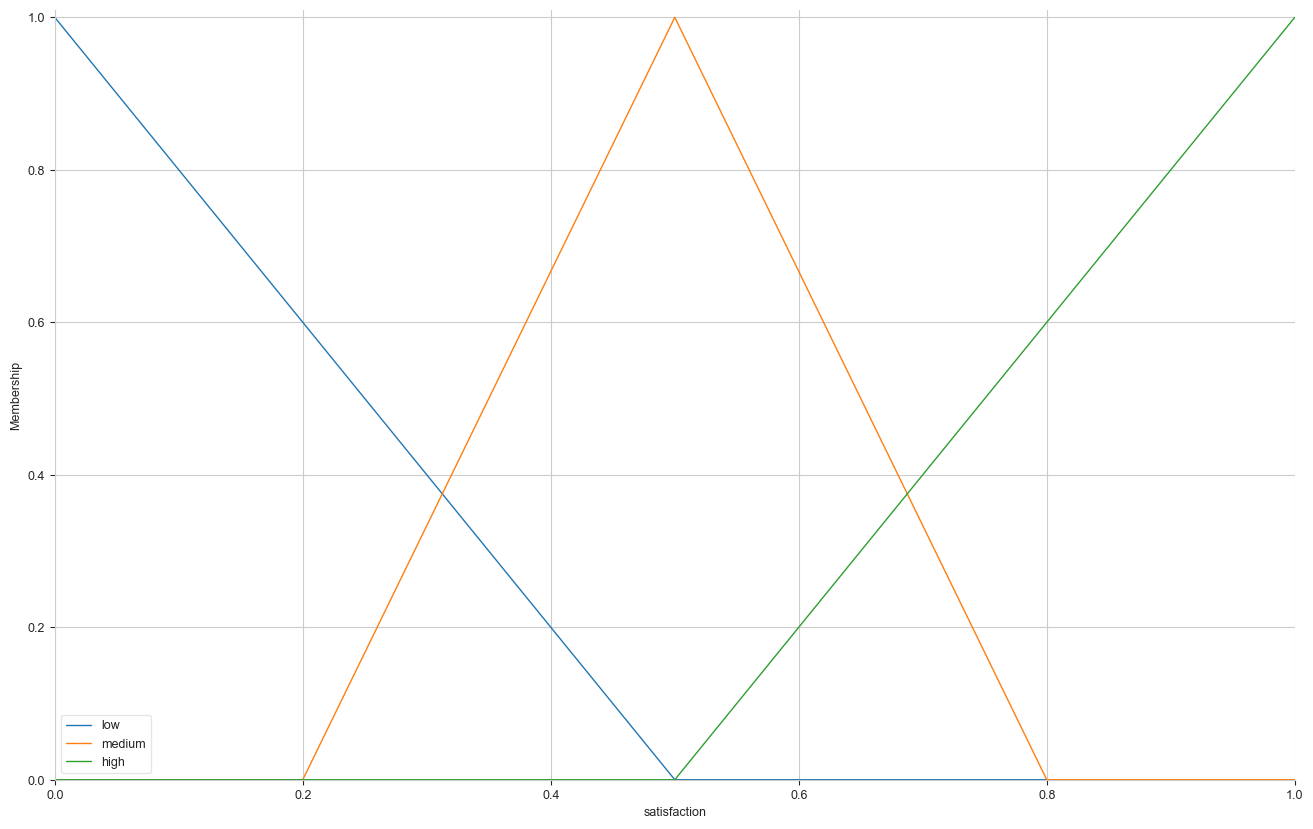

In [232]:
age.view()
balance.view()
activity.view()
satisfaction.view()

### 5.Putting rules inside a system

In [233]:
system = ctrl.ControlSystem(rules)
sim = ctrl.ControlSystemSimulation(system)

In [234]:
def classify_churn(churn_score):
    if churn_score < 40:
        return "No immediate action. Keep engagement programs."
    elif churn_score < 70:
        return "Send offers, improve engagement, monitor behavior."
    else:
        return "Immediate intervention: call customer, special offers, support."

In [236]:
for i in range(5):
    # Inputs
    age_val = X.iloc[i]['age']
    balance_val = X.iloc[i]['balance']
    activity_val = X.iloc[i]['isactivemember']
    satisfaction_val = X.iloc[i]['satisfaction score']
    cluster_val = copy.iloc[i]['Cluster']

    # Assign to fuzzy system
    sim.input['age'] = age_val
    sim.input['balance'] = balance_val
    sim.input['activity'] = activity_val
    sim.input['satisfaction'] = satisfaction_val
    sim.input['cluster'] = cluster_val

    # 🔍 Print inputs (both original + scaled)
    print(f"Customer {i}")
    print(f"Original Age: {copy.iloc[i]['age']} | Scaled: {age_val:.2f}")
    print(f"Original Balance: {copy.iloc[i]['balance']} | Scaled: {balance_val:.2f}")
    print(f"Activity (isActiveMember): {activity_val:.2f}")
    print(f"Satisfaction: {satisfaction_val:.2f}")
    print(f"Cluster: {cluster_val}")

    sim.compute()

    print(f"Predicted churn: {sim.output['churn']:.2f}")
    print(f"action to take: {classify_churn(sim.output['churn'])}")
    print("-" * 50)

Customer 0
Original Age: 42 | Scaled: 0.69
Original Balance: 0.0 | Scaled: 0.00
Activity (isActiveMember): 1.00
Satisfaction: 0.25
Cluster: 1
Predicted churn: 43.81
action to take: Send offers, improve engagement, monitor behavior.
--------------------------------------------------
Customer 1
Original Age: 41 | Scaled: 0.67
Original Balance: 83807.86 | Scaled: 0.33
Activity (isActiveMember): 1.00
Satisfaction: 0.50
Cluster: 0
Predicted churn: 13.33
action to take: No immediate action. Keep engagement programs.
--------------------------------------------------
Customer 2
Original Age: 42 | Scaled: 0.69
Original Balance: 159660.8 | Scaled: 0.64
Activity (isActiveMember): 0.00
Satisfaction: 0.50
Cluster: 1
Predicted churn: 60.29
action to take: Send offers, improve engagement, monitor behavior.
--------------------------------------------------
Customer 3
Original Age: 39 | Scaled: 0.63
Original Balance: 0.0 | Scaled: 0.00
Activity (isActiveMember): 0.00
Satisfaction: 1.00
Cluster: 1
Pre

### Predictions from our dataset

In [237]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

POP_SIZE       = 30    # individuals per generation
N_GENERATIONS  = 50    # total generations to run
CROSSOVER_RATE = 0.80  # probability two parents swap genetic material
MUTATION_RATE  = 0.06  # probability each gene flips  (~1 / chromosome_length)
ELITISM_COUNT  = 2     # best N individuals copied unchanged each generation
TOURNAMENT_K   = 3     # competitors per tournament selection round

print(f"GA Settings: pop={POP_SIZE}, gens={N_GENERATIONS}, "
      f"cx={CROSSOVER_RATE}, mut={MUTATION_RATE}, elite={ELITISM_COUNT}")


GA Settings: pop=30, gens=50, cx=0.8, mut=0.06, elite=2


# Task 6 — Genatic Algorithm

## Section 1— Fitness Function

**fitness_function(chromosome, X, y)**

- Selects only the columns where the chromosome has a `1`
- Evaluates Logistic Regression using **3-fold stratified cross-validation**
- Returns the **weighted F1-score** (higher = better)
- Returns `0.0` if fewer than 2 features are selected (penalty for useless chromosomes)


In [238]:
def fitness_function(chromosome, X, y):
    selected = [i for i, bit in enumerate(chromosome) if bit == 1]
    if len(selected) < 2:
        return 0.0

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    scores = cross_val_score(
        LogisticRegression(max_iter=300, random_state=RANDOM_SEED),
        X.iloc[:, selected], y,
        cv=cv, scoring="f1_weighted"
    )
    return float(np.mean(scores))


## Dropping complain before logistic regression


In [241]:
X=X.drop(columns=['complain'])

## Section 5 — Genetic Algorithm Components

| Component | Definition |
|-----------|-----------|
| **Chromosome** | Binary list of length 18 — one bit per feature |
| **Gene** | A single bit: `1` = include feature, `0` = exclude |
| **Population** | 30 chromosomes (candidate feature subsets) |
| **Selection** | Tournament selection (k=3) |
| **Crossover** | Single-point crossover, rate = 0.80 |
| **Mutation** | Bit-flip per gene, rate = 0.06 |
| **Elitism** | Top 2 chromosomes copied unchanged each generation |


In [245]:
# ── 5a. Chromosome & Population ─────────────────────────────────

def make_chromosome(n):
    """Random binary list of length n."""
    L=[random.randint(0, 1) for _ in range(n)]
    return L

def make_population(pop_size, n):
    """List of pop_size random chromosomes."""
    return [make_chromosome(n) for _ in range(pop_size)]


# ── 5b. Tournament Selection ─────────────────────────────────────

def tournament_select(population, fitnesses, k=TOURNAMENT_K):
    """
    Draw k random individuals; the one with the highest fitness wins.
    Returns a copy of the winner chromosome.
    """
    contestants = random.sample(range(len(population)), k)
    winner = max(contestants, key=lambda i: fitnesses[i])
    return population[winner][:]


# ── 5c. Single-point Crossover ───────────────────────────────────

def single_point_crossover(p1, p2, rate=CROSSOVER_RATE):
    """
    Pick a random cut point.
    child1 = left(p1) + right(p2)
    child2 = left(p2) + right(p1)
    If random > rate: children are clones of parents (no crossover).
    """
    if random.random() > rate or len(p1) < 2:
       c1, c2 = p1[:], p2[:]
    else:
        cut = random.randint(1, len(p1) - 1)
        c1, c2 = p1[:cut] + p2[cut:], p2[:cut] + p1[cut:]
    
   
    return c1, c2


# ── 5d. Bit-flip Mutation ────────────────────────────────────────

def bit_flip_mutate(chromosome, rate=MUTATION_RATE):
    """
    Each gene flips independently with probability rate.
    Rate ~= 1/L means ~1 flip per chromosome on average.
    """
    new_chromosome = [1 - g if random.random() < rate else g for g in chromosome]
    return new_chromosome


# ── 5e. Build Next Generation ────────────────────────────────────

def next_generation(population, fitnesses):
    """
    Elitism: copy top ELITISM_COUNT individuals unchanged.
    Fill the rest with tournament -> crossover -> mutation.
    """
    n = len(population)
    ranked  = sorted(zip(fitnesses, population), key=lambda x: x[0], reverse=True)
    new_pop = [ind[:] for _, ind in ranked[:ELITISM_COUNT]]

    while len(new_pop) < n:
        p1 = tournament_select(population, fitnesses)
        p2 = tournament_select(population, fitnesses)
        c1, c2 = single_point_crossover(p1, p2)
        new_pop.append(bit_flip_mutate(c1))
        if len(new_pop) < n:
            new_pop.append(bit_flip_mutate(c2))
    return new_pop

print("All GA components defined successfully.")

# Example: show one crossover
ex_p1 = [1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0]
ex_p2 = [0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,0]
ex_c1, ex_c2 = single_point_crossover(ex_p1, ex_p2)
print(f"\nCrossover example:")
print(f"  Parent 1 : {ex_p1}")
print(f"  Parent 2 : {ex_p2}")
print(f"  Child  1 : {ex_c1}")
print(f"  Child  2 : {ex_c2}")
print(f"  Mutated  : {bit_flip_mutate(ex_c1)}")


All GA components defined successfully.

Crossover example:
  Parent 1 : [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0]
  Parent 2 : [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0]
  Child  1 : [1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0]
  Child  2 : [0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0]
  Mutated  : [1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1]


## Section 6 — Baseline (All Features)
We evaluate Logistic Regression using **all 18 features** before any GA.
This is the reference F1-score the GA must compete against.


In [246]:
feature_names = list(X.columns)
print("Computing baseline with ALL features...")
baseline_f1 = fitness_function([1]*len(feature_names), X, y)
print(f"\nBaseline F1-score (all {len(feature_names)} features) : {baseline_f1:.4f}")


Computing baseline with ALL features...

Baseline F1-score (all 18 features) : 0.8020


## Section 7 — Run the Genetic Algorithm
The GA runs for **50 generations** with a population of **30 individuals**.
Progress is printed every 10 generations.


In [247]:
n_features = X.shape[1]

print(f"Population: {POP_SIZE}  |  Generations: {N_GENERATIONS}")
print(f"Crossover : {CROSSOVER_RATE}      |  Mutation   : {MUTATION_RATE}")
print(f"Elitism   : {ELITISM_COUNT}        |  Tournament : k={TOURNAMENT_K}")
print(f"Chr. len  : {n_features} genes")
print()

# Initialise population
population = make_population(POP_SIZE, n_features)

# Tracking
history_best    = []
history_avg     = []
best_fitness    = -1.0
best_chromosome = None

for gen in range(1, N_GENERATIONS + 1):

    # Score every individual
    fitnesses = [fitness_function(chrom, X, y) for chrom in population]

    # Stats
    gen_best = max(fitnesses)
    gen_avg  = float(np.mean(fitnesses))
    history_best.append(gen_best)
    history_avg.append(gen_avg)

    # Update global best
    best_idx = int(np.argmax(fitnesses))
    if fitnesses[best_idx] > best_fitness:
        best_fitness    = fitnesses[best_idx]
        best_chromosome = population[best_idx][:]

    # Print progress
    if gen == 1 or gen % 10 == 0:
        print(f"  Gen {gen:>3}/{N_GENERATIONS}"
              f"  |  Best F1: {gen_best:.4f}"
              f"  |  Avg F1: {gen_avg:.4f}"
              f"  |  Features in best: {sum(best_chromosome)}")

    # Evolve
    population = next_generation(population, fitnesses)

print()
print(f"GA finished.")
print(f"Best F1 found : {best_fitness:.4f}")
print(f"Features used : {sum(best_chromosome)} / {n_features}")


Population: 30  |  Generations: 50
Crossover : 0.8      |  Mutation   : 0.06
Elitism   : 2        |  Tournament : k=3
Chr. len  : 18 genes

  Gen   1/50  |  Best F1: 0.8030  |  Avg F1: 0.7465  |  Features in best: 12
  Gen  10/50  |  Best F1: 0.8044  |  Avg F1: 0.7958  |  Features in best: 13
  Gen  20/50  |  Best F1: 0.8044  |  Avg F1: 0.7999  |  Features in best: 13
  Gen  30/50  |  Best F1: 0.8046  |  Avg F1: 0.7935  |  Features in best: 13
  Gen  40/50  |  Best F1: 0.8046  |  Avg F1: 0.7978  |  Features in best: 13
  Gen  50/50  |  Best F1: 0.8046  |  Avg F1: 0.8028  |  Features in best: 13

GA finished.
Best F1 found : 0.8046
Features used : 13 / 18


## Section 8 — Best Solution Found

In [248]:
selected = [feature_names[i] for i, b in enumerate(best_chromosome) if b == 1]
excluded = [feature_names[i] for i, b in enumerate(best_chromosome) if b == 0]
diff     = best_fitness - baseline_f1

print("=" * 55)
print("  RESULTS SUMMARY")
print("=" * 55)
print(f"  Best chromosome   : {best_chromosome}")
print(f"  Features selected : {len(selected)} / {n_features}")
print()
print("  Included features:")
for f in selected:
    print(f"    [+]  {f}")
print()
print("  Excluded features:")
for f in excluded:
    print(f"    [-]  {f}")
print()
print(f"  Baseline F1  (all {n_features} features) : {baseline_f1:.4f}")
print(f"  GA best F1   ({len(selected)} features)       : {best_fitness:.4f}")
sign = '+' if diff >= 0 else ''
print(f"  Difference                         : {sign}{diff:.4f}")
if diff >= 0:
    print("  -> GA found a subset that MATCHES or IMPROVES baseline.")
else:
    print("  -> GA found a compact subset with a slight trade-off.")
    print("     Fewer features = simpler model, less risk of overfitting.")


  RESULTS SUMMARY
  Best chromosome   : [1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 1, 0]
  Features selected : 13 / 18

  Included features:
    [+]  creditscore
    [+]  gender
    [+]  age
    [+]  tenure
    [+]  numofproducts
    [+]  isactivemember
    [+]  estimatedsalary
    [+]  satisfaction score
    [+]  point earned
    [+]  geography_Germany
    [+]  geography_Spain
    [+]  card type_GOLD
    [+]  card type_PLATINUM

  Excluded features:
    [-]  balance
    [-]  hascrcard
    [-]  geography_France
    [-]  card type_DIAMOND
    [-]  card type_SILVER

  Baseline F1  (all 18 features) : 0.8020
  GA best F1   (13 features)       : 0.8046
  Difference                         : +0.0026
  -> GA found a subset that MATCHES or IMPROVES baseline.


## Plot 3 — Fitness Evolution Across Generations
Shows how the GA improves over time.
- **Blue line** = best individual each generation
- **Orange dashed** = population average each generation
- **Red dotted** = baseline (all features)


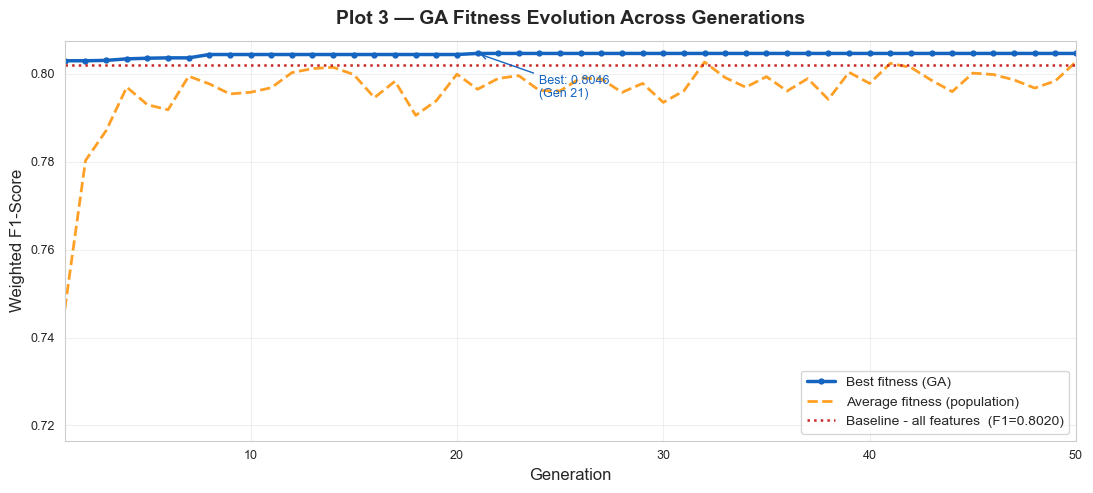

In [249]:
gens = list(range(1, N_GENERATIONS + 1))

fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(gens, history_best, color='#1565C0', lw=2.5,
        marker='o', markersize=3.5, label='Best fitness (GA)')
ax.plot(gens, history_avg,  color='#FF8F00', lw=2,
        linestyle='--', alpha=0.85, label='Average fitness (population)')
ax.axhline(baseline_f1, color='#C62828', lw=1.8,
           linestyle=':', label=f'Baseline - all features  (F1={baseline_f1:.4f})')

# Annotate best point
best_gen = int(np.argmax(history_best)) + 1
ax.annotate(f'Best: {max(history_best):.4f}\n(Gen {best_gen})',
            xy=(best_gen, max(history_best)),
            xytext=(best_gen + 3, max(history_best) - 0.01),
            arrowprops=dict(arrowstyle='->', color='#1565C0'),
            fontsize=9, color='#1565C0')

ax.set_title('Plot 3 — GA Fitness Evolution Across Generations',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Generation', fontsize=12)
ax.set_ylabel('Weighted F1-Score', fontsize=12)
ax.legend(fontsize=10, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim(1, N_GENERATIONS)
ax.set_ylim(bottom=max(0, min(history_avg) - 0.03))

plt.tight_layout()
plt.savefig('plot3_fitness_evolution.png', dpi=150, bbox_inches='tight')
plt.show()


## Plot 4 — Selected vs Excluded Features
Horizontal bar chart showing which features the GA kept and which it dropped.


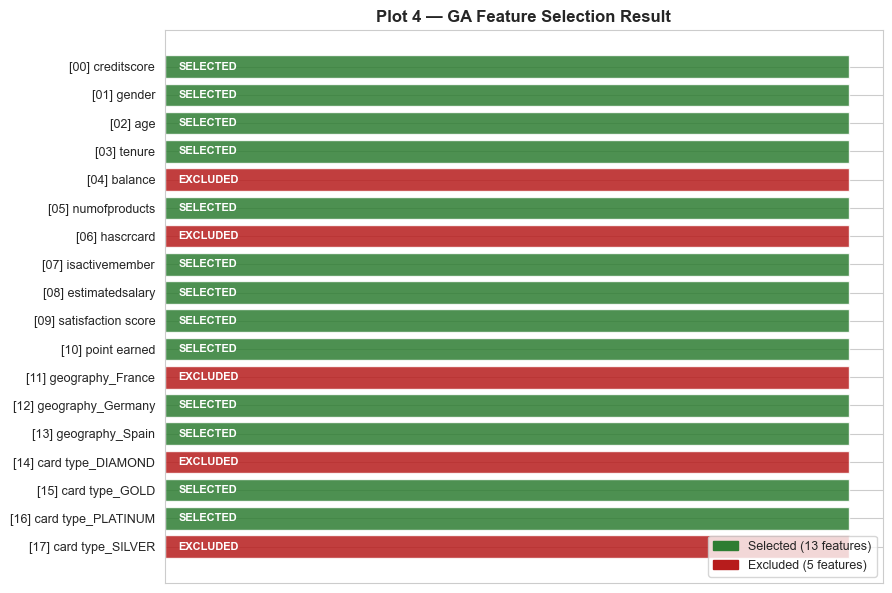

In [250]:
feat_colors_result = ['#2E7D32' if b == 1 else '#B71C1C'
                      for b in best_chromosome]
feat_labels_result = ['SELECTED' if b == 1 else 'EXCLUDED'
                      for b in best_chromosome]

fig, ax = plt.subplots(figsize=(9, 6))
y_pos = range(len(feature_names))
bars  = ax.barh(y_pos, [1]*len(feature_names),
                color=feat_colors_result, edgecolor='white', alpha=0.85)

ax.set_yticks(y_pos)
ax.set_yticklabels([f"[{i:02d}] {n}" for i, n in enumerate(feature_names)], fontsize=9)
ax.set_xticks([])
ax.invert_yaxis()
ax.set_title('Plot 4 — GA Feature Selection Result',
             fontsize=12, fontweight='bold')

# Labels on bars
for i, (bar, label) in enumerate(zip(bars, feat_labels_result)):
    ax.text(0.02, bar.get_y() + bar.get_height()/2,
            label, va='center', fontsize=8,
            color='white', fontweight='bold')

patch_sel = mpatches.Patch(color='#2E7D32', label=f'Selected ({len(selected)} features)')
patch_exc = mpatches.Patch(color='#B71C1C', label=f'Excluded ({len(excluded)} features)')
ax.legend(handles=[patch_sel, patch_exc], loc='lower right', fontsize=9)
ax.grid(axis='x', alpha=0.2)
plt.tight_layout()
plt.savefig('plot4_feature_selection.png', dpi=150, bbox_inches='tight')
plt.show()


## Plot 5 — Baseline vs GA Comparison
Side-by-side comparison of the baseline score vs the GA best score,
plus the reduction in number of features.


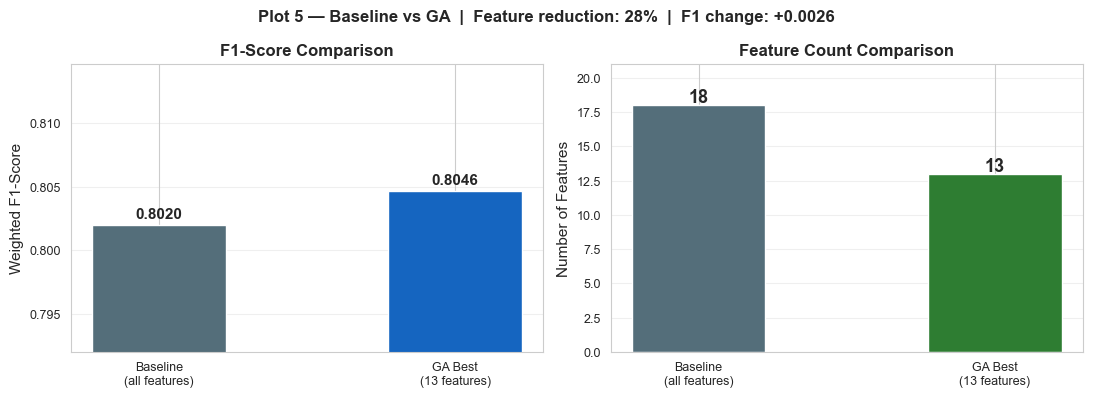

Feature reduction : 18 -> 13  (28% fewer features)
F1 change         : 0.8020 -> 0.8046  (+0.0026)


In [251]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# -- F1 comparison --
methods = ['Baseline\n(all features)', f'GA Best\n({len(selected)} features)']
scores  = [baseline_f1, best_fitness]
colors  = ['#546E7A', '#1565C0']
bars = axes[0].bar(methods, scores, color=colors, width=0.45, edgecolor='white')
for bar, val in zip(bars, scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                 f'{val:.4f}', ha='center', fontweight='bold', fontsize=11)
axes[0].set_ylim(min(scores) - 0.01, max(scores) + 0.01)
axes[0].set_ylabel('Weighted F1-Score', fontsize=11)
axes[0].set_title('F1-Score Comparison', fontsize=12, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# -- Feature count --
feat_counts = [n_features, len(selected)]
colors2     = ['#546E7A', '#2E7D32']
bars2 = axes[1].bar(methods, feat_counts, color=colors2, width=0.45, edgecolor='white')
for bar, val in zip(bars2, feat_counts):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                 str(val), ha='center', fontweight='bold', fontsize=13)
axes[1].set_ylim(0, n_features + 3)
axes[1].set_ylabel('Number of Features', fontsize=11)
axes[1].set_title('Feature Count Comparison', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

reduction = (1 - len(selected)/n_features) * 100
fig.suptitle(f'Plot 5 — Baseline vs GA  |  '
             f'Feature reduction: {reduction:.0f}%  |  '
             f'F1 change: {best_fitness - baseline_f1:+.4f}',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('plot5_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Feature reduction : {n_features} -> {len(selected)}  ({reduction:.0f}% fewer features)")
print(f"F1 change         : {baseline_f1:.4f} -> {best_fitness:.4f}  ({best_fitness-baseline_f1:+.4f})")


## PCA and comparison with genatic

Total features                    : 18
Components needed for 95% variance: 13


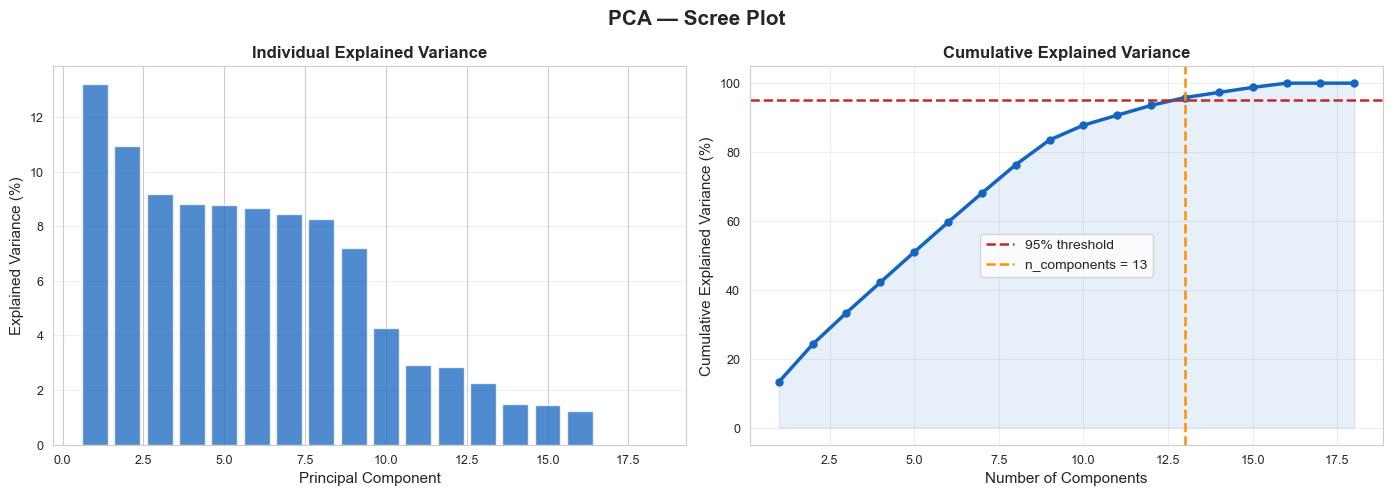

In [252]:
pca_full = PCA(random_state=42)
pca_full.fit(X)

explained_var   = pca_full.explained_variance_ratio_
cumulative_var  = np.cumsum(explained_var)
n_components_95 = np.argmax(cumulative_var >= 0.95) + 1

print(f"Total features                    : {X.shape[1]}")
print(f"Components needed for 95% variance: {n_components_95}")

# ── Scree Plot ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA — Scree Plot", fontsize=15, fontweight="bold")

ax = axes[0]
ax.bar(range(1, len(explained_var) + 1), explained_var * 100,
       color="#1565C0", alpha=0.75, edgecolor="white")
ax.set_xlabel("Principal Component", fontsize=11)
ax.set_ylabel("Explained Variance (%)", fontsize=11)
ax.set_title("Individual Explained Variance", fontsize=12, fontweight="bold")
ax.grid(axis="y", alpha=0.3)

ax = axes[1]
ax.plot(range(1, len(cumulative_var) + 1), cumulative_var * 100,
        marker="o", color="#1565C0", lw=2.5, markersize=5)
ax.axhline(95, color="#C62828", linestyle="--", lw=1.8,
           label="95% threshold")
ax.axvline(n_components_95, color="#FF8F00", linestyle="--", lw=1.8,
           label=f"n_components = {n_components_95}")
ax.fill_between(range(1, len(cumulative_var) + 1), cumulative_var * 100,
                alpha=0.1, color="#1565C0")
ax.set_xlabel("Number of Components", fontsize=11)
ax.set_ylabel("Cumulative Explained Variance (%)", fontsize=11)
ax.set_title("Cumulative Explained Variance", fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [253]:
pca = PCA(n_components=0.95, random_state=42)
X_pca = pca.fit_transform(X)

print(f"Original shape : {X.shape}  →  {X.shape[1]} features")
print(f"PCA shape      : {X_pca.shape}  →  {X_pca.shape[1]} components")
print(f"Variance retained: {pca.explained_variance_ratio_.sum()*100:.2f}%")

Original shape : (9512, 18)  →  18 features
PCA shape      : (9512, 13)  →  13 components
Variance retained: 95.82%


In [254]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

pca_scores = cross_val_score(
    LogisticRegression(max_iter=500, random_state=42),
    X_pca, y,
    cv=cv, scoring="f1_weighted"
)

pca_f1 = float(np.mean(pca_scores))
print(f"PCA + Logistic Regression F1 (3-fold CV): {pca_f1:.4f}")
print(f"Individual fold scores: {[f'{s:.4f}' for s in pca_scores]}")

PCA + Logistic Regression F1 (3-fold CV): 0.7398
Individual fold scores: ['0.7418', '0.7429', '0.7346']


  F1 COMPARISON SUMMARY
  Baseline  (all 18 features)         : 0.8020
  GA Best   (13 features selected)      : 0.8046
  PCA+LR    (13 components, 95% var)    : 0.7398

  🏆 Best method: GA with F1 = 0.8046


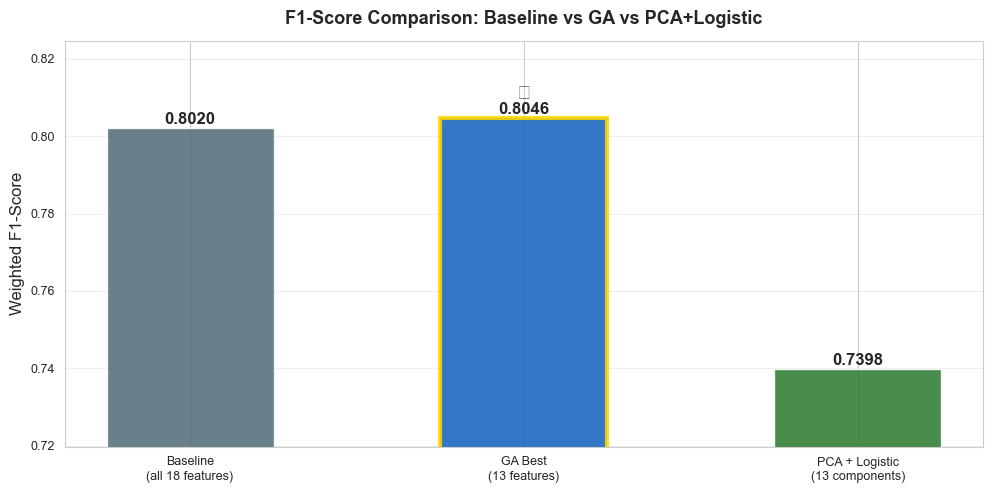

In [255]:
print("=" * 55)
print("  F1 COMPARISON SUMMARY")
print("=" * 55)
print(f"  Baseline  (all {X.shape[1]} features)         : {baseline_f1:.4f}")
print(f"  GA Best   ({sum(best_chromosome)} features selected)      : {best_fitness:.4f}")
print(f"  PCA+LR    ({X_pca.shape[1]} components, 95% var)    : {pca_f1:.4f}")
print("=" * 55)

best_method = max([(baseline_f1, 'Baseline'), (best_fitness, 'GA'), (pca_f1, 'PCA+LR')],
                  key=lambda x: x[0])
print(f"\n  🏆 Best method: {best_method[1]} with F1 = {best_method[0]:.4f}")

fig, ax = plt.subplots(figsize=(10, 5))

labels = [
    f"Baseline\n(all {X.shape[1]} features)",
    f"GA Best\n({sum(best_chromosome)} features)",
    f"PCA + Logistic\n({X_pca.shape[1]} components)"
]
scores = [baseline_f1, best_fitness, pca_f1]
colors = ["#546E7A", "#1565C0", "#2E7D32"]

bars = ax.bar(labels, scores, color=colors, edgecolor="white",
              width=0.5, alpha=0.88)

for bar, val in zip(bars, scores):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.001,
            f"{val:.4f}", ha="center", fontsize=12, fontweight="bold")

best_idx = scores.index(max(scores))
bars[best_idx].set_edgecolor("gold")
bars[best_idx].set_linewidth(3)
ax.text(best_idx, max(scores) + 0.005, "🏆", ha="center", fontsize=14)

ax.set_ylim(min(scores) - 0.02, max(scores) + 0.02)
ax.set_ylabel("Weighted F1-Score", fontsize=12)
ax.set_title("F1-Score Comparison: Baseline vs GA vs PCA+Logistic",
             fontsize=13, fontweight="bold", pad=12)
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

---
## Task 7 — System Implementation
Comprehensive function that integrates **K-Medoid Clustering**, **Fuzzy Logic**, and the **Genetic Algorithm** to analyse a single customer record and produce a meaningful, actionable output.

### Arguments
| Argument | Description |
|---|---|
| `record_index` | Row index of the customer to analyse |
| `X_data` | Pre-processed feature matrix (from Task 2) |
| `original_data` | Original decoded DataFrame |
| `kmedoids_model` | Fitted KMedoids model (from Task 3) |
| `fuzzy_sim` | Fuzzy ControlSystemSimulation (from Task 5) |
| `best_ga_chromosome` | Best binary chromosome from GA (from Task 6) |
| `feature_names` | List of feature names |

### Output
- **Module 1**: Cluster ID and profile name from K-Medoids
- **Module 2**: Churn risk score + action recommendation from Fuzzy System
- **Module 3**: GA-selected features used for evaluation
- **Integrated**: Composite risk score combining all three signals
- **Visualisation**: 3-panel chart showing cluster membership, churn gauge, and feature selection


In [261]:
copy

,creditscore,gender,age,tenure,balance,numofproducts,hascrcard,isactivemember,estimatedsalary,exited,...,satisfaction score,point earned,geography_France,geography_Germany,geography_Spain,card type_DIAMOND,card type_GOLD,card type_PLATINUM,card type_SILVER,Cluster
0,619,0,42,2,0.00,1,1,1,101348.88,1,...,2,464,True,False,False,True,False,False,False,1
1,608,0,41,1,83807.86,1,0,1,112542.58,0,...,3,456,False,False,True,True,False,False,False,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,...,3,377,True,False,False,True,False,False,False,1
3,699,0,39,1,0.00,2,0,0,93826.63,0,...,5,350,True,False,False,False,True,False,False,1
4,850,0,43,2,125510.82,1,1,1,79084.10,0,...,5,425,False,False,True,False,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,0,...,1,300,True,False,False,True,False,False,False,1
9996,516,1,35,10,57369.61,1,1,1,101699.77,0,...,5,771,True,False,False,False,False,True,False,2
9997,709,0,36,7,0.00,1,0,1,42085.58,1,...,3,564,True,False,False,False,False,False,True,2
9998,772,1,42,3,75075.31,2,1,0,92888.52,1,...,2,339,False,True,False,False,True,False,False,2


Running comprehensive analysis on 3 sample customers...



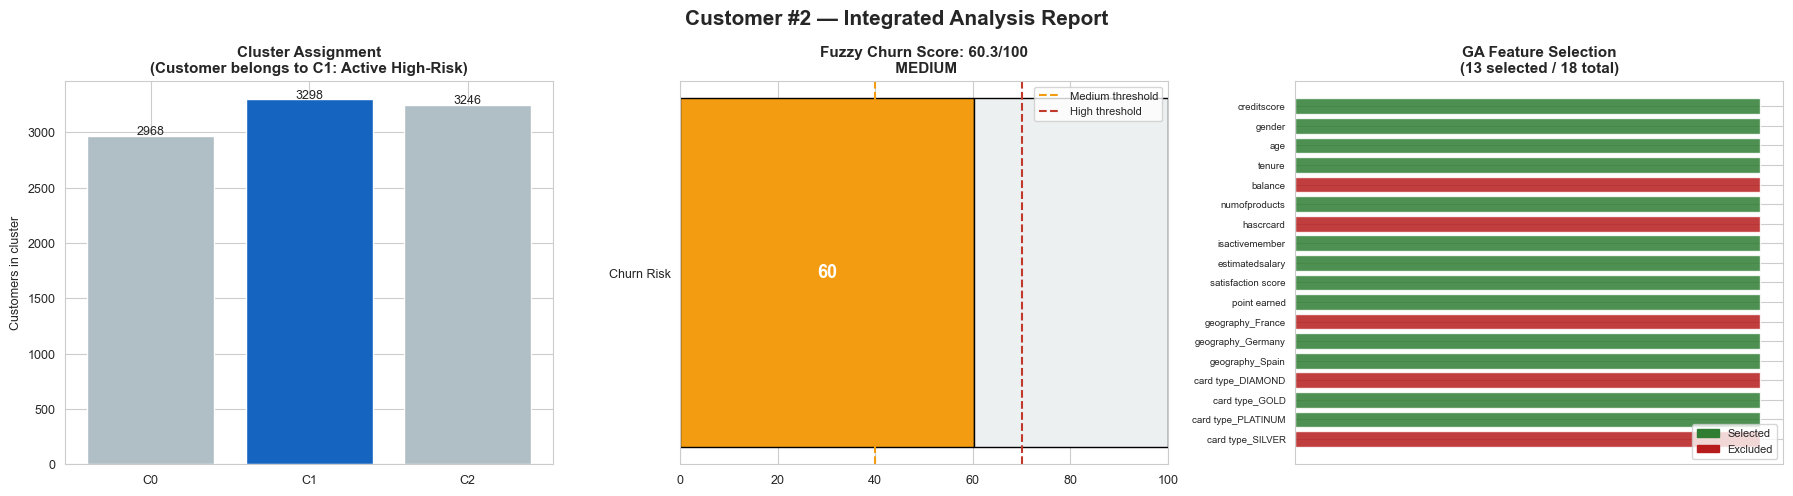

  CUSTOMER ANALYSIS REPORT   —   Record #2

  CUSTOMER PROFILE
    Age                   : 42
    Geography             : France
    Gender                : Female
    Balance               : $159,661
    Estimated Salary      : $113,932
    Products Held         : 3
    Active Member         : No
    Satisfaction          : 3/5
    Card Type             : DIAMOND
    Actual Exited         : Yes

  MODULE 1 — K-MEDOID CLUSTERING
    Cluster ID   : 1
    Cluster Name : Active High-Risk

 MODULE 2 — FUZZY LOGIC CHURN PREDICTION
    Churn Score  : 60.3 / 100
    Action       : Send targeted offers, improve engagement, monitor behaviour.

  MODULE 3 — GENETIC ALGORITHM FEATURE SELECTION
    Features used by GA : 13 / 18
    Features selected   : creditscore, gender, age, tenure, numofproducts, isactivemember, estimatedsalary, satisfaction score, point earned, geography_Germany, geography_Spain, card type_GOLD, card type_PLATINUM

  INTEGRATED RISK ASSESSMENT
    Composite Risk Score : 66.2

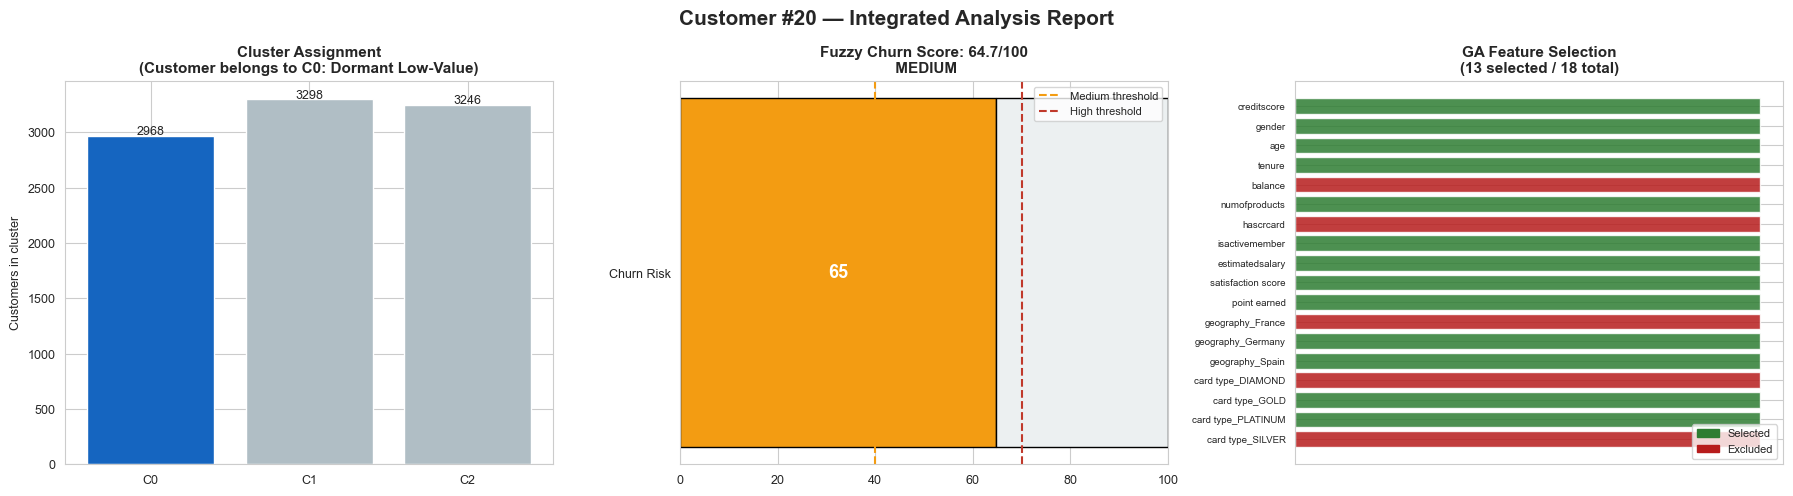

  CUSTOMER ANALYSIS REPORT   —   Record #20

  CUSTOMER PROFILE
    Age                   : 32
    Geography             : Spain
    Gender                : Female
    Balance               : $0
    Estimated Salary      : $138,555
    Products Held         : 2
    Active Member         : No
    Satisfaction          : 2/5
    Card Type             : DIAMOND
    Actual Exited         : No

  MODULE 1 — K-MEDOID CLUSTERING
    Cluster ID   : 0
    Cluster Name : Dormant Low-Value

 MODULE 2 — FUZZY LOGIC CHURN PREDICTION
    Churn Score  : 64.7 / 100
    Action       : Send targeted offers, improve engagement, monitor behaviour.

  MODULE 3 — GENETIC ALGORITHM FEATURE SELECTION
    Features used by GA : 13 / 18
    Features selected   : creditscore, gender, age, tenure, numofproducts, isactivemember, estimatedsalary, satisfaction score, point earned, geography_Germany, geography_Spain, card type_GOLD, card type_PLATINUM

  INTEGRATED RISK ASSESSMENT
    Composite Risk Score : 73.8 / 100

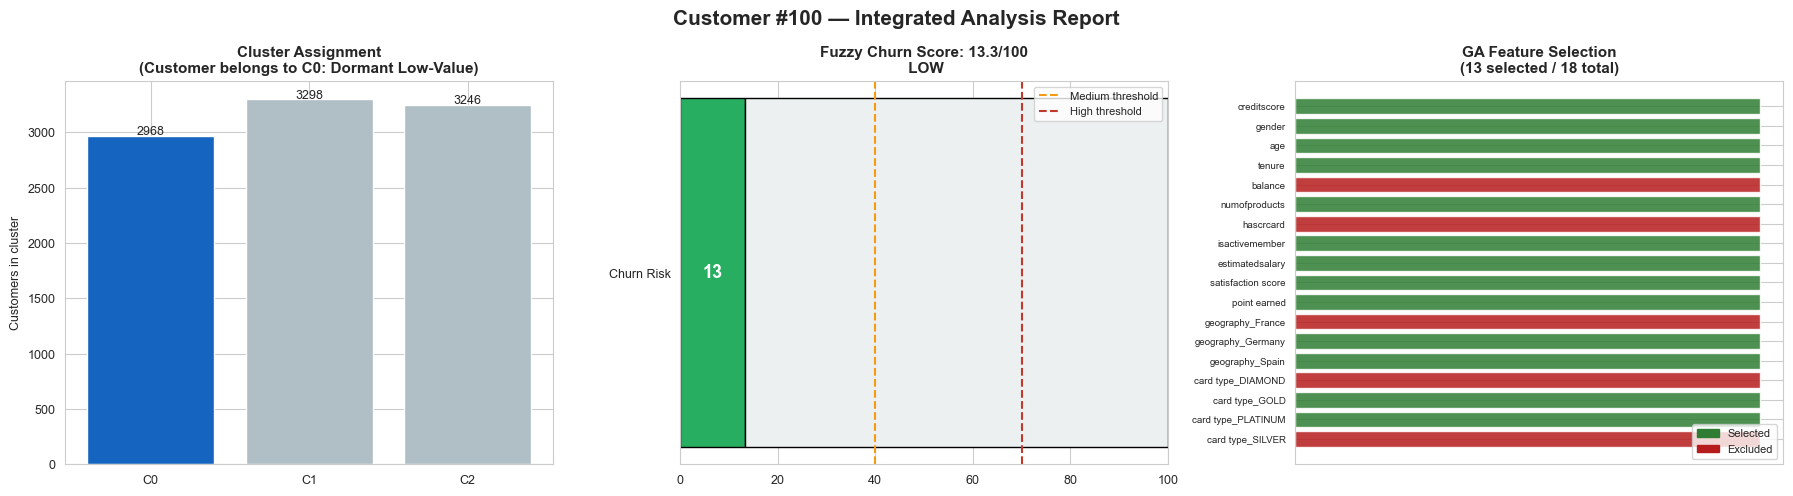

  CUSTOMER ANALYSIS REPORT   —   Record #100

  CUSTOMER PROFILE
    Age                   : 46
    Geography             : Spain
    Gender                : Female
    Balance               : $107,073
    Estimated Salary      : $30,985
    Products Held         : 2
    Active Member         : Yes
    Satisfaction          : 3/5
    Card Type             : GOLD
    Actual Exited         : Yes

  MODULE 1 — K-MEDOID CLUSTERING
    Cluster ID   : 0
    Cluster Name : Dormant Low-Value

 MODULE 2 — FUZZY LOGIC CHURN PREDICTION
    Churn Score  : 13.3 / 100
    Action       : No immediate action needed. Maintain loyalty programs.

  MODULE 3 — GENETIC ALGORITHM FEATURE SELECTION
    Features used by GA : 13 / 18
    Features selected   : creditscore, gender, age, tenure, numofproducts, isactivemember, estimatedsalary, satisfaction score, point earned, geography_Germany, geography_Spain, card type_GOLD, card type_PLATINUM

  INTEGRATED RISK ASSESSMENT
    Composite Risk Score : 18.0 / 100


In [264]:
# ============================================================
# TASK 7 — SYSTEM IMPLEMENTATION
# Comprehensive function integrating: Clustering, Fuzzy Logic,
# and Genetic Algorithm to produce a meaningful output
# for a single customer record.
# ============================================================

def analyze_customer(record_index,
                     X_data,
                     original_data,
                     kmedoids_model,
                     fuzzy_sim,
                     best_ga_chromosome,
                     feature_names):
    """
    Comprehensive customer analysis integrating all three sub-systems.

    Parameters
    ----------
    record_index      : int   — row index in X_data to analyse
    X_data            : pd.DataFrame — preprocessed feature matrix
    original_data     : pd.DataFrame — original/decoded dataframe
    kmedoids_model    : fitted KMedoids object
    fuzzy_sim         : skfuzzy ControlSystemSimulation (already built)
    best_ga_chromosome: list[int] — binary chromosome from GA
    feature_names     : list[str]  — column names matching X_data

    Returns
    -------
    dict with keys: cluster_id, churn_score, churn_action,
                    selected_features, risk_level, customer_profile
    """

    # ── 1. FETCH RECORD ─────────────────────────────────────────
    row_scaled   = X_data.iloc[record_index]
    row_original = original_data.iloc[record_index]

    # ── 2. K-MEDOID CLUSTERING ──────────────────────────────────
    cluster_id = kmedoids_model.labels_[record_index]

    cluster_profiles = {
        0: "Dormant Low-Value",
        1: "Active High-Risk",
        2: "Loyal Stable",
        3: "Engaged Brand Fan",
        4: "Premium Potential",
        5: "Passive Mid-Tier"
    }
    cluster_name = cluster_profiles.get(cluster_id, f"Cluster {cluster_id}")

    # ── 3. FUZZY LOGIC CHURN PREDICTION ─────────────────────────
    age_val          = float(row_scaled['age'])
    balance_val      = float(row_scaled['balance'])
    activity_val     = float(row_scaled['isactivemember'])
    satisfaction_val = float(row_scaled['satisfaction score'])
    cluster_val      = min(cluster_id, 2)   # fuzzy universe is [0,2]

    fuzzy_sim.input['age']          = np.clip(age_val, 2.9, 4.14)
    fuzzy_sim.input['balance']      = np.clip(balance_val, 0, 1)
    fuzzy_sim.input['activity']     = np.clip(activity_val, 0, 1)
    fuzzy_sim.input['satisfaction'] = np.clip(satisfaction_val, 0, 1)
    fuzzy_sim.input['cluster']      = float(cluster_val)
    fuzzy_sim.compute()

    churn_score = fuzzy_sim.output['churn']

    if churn_score < 40:
        churn_label  = "LOW"
        churn_action = "No immediate action needed. Maintain loyalty programs."
    elif churn_score < 70:
        churn_label  = "MEDIUM"
        churn_action = "Send targeted offers, improve engagement, monitor behaviour."
    else:
        churn_label  = "HIGH"
        churn_action = ("Immediate intervention: call customer, "
                        "special retention offer, priority support.")

    # ── 4. GENETIC ALGORITHM — SELECTED FEATURES ────────────────
    selected_feats = [feature_names[i]
                      for i, bit in enumerate(best_ga_chromosome) if bit == 1]

    # ── 5. COMPOSITE RISK SCORE ──────────────────────────────────
    # Weighted blend: fuzzy churn (60%) + inactivity penalty (20%)
    #                 + dissatisfaction penalty (20%)
    composite_risk = (
        0.60 * churn_score +
        0.20 * (1 - activity_val) * 100 +
        0.20 * (1 - satisfaction_val) * 100
    )

    if composite_risk < 30:
        risk_level = "LOW RISK"
    elif composite_risk < 55:
        risk_level = "MODERATE RISK"
    elif composite_risk < 75:
        risk_level = "HIGH RISK"
    else:
        risk_level = "CRITICAL RISK"
    geo_columns = ['geography_France', 'geography_Germany', 'geography_Spain']
    selected_geo = X_data.loc[X_data.index[record_index], geo_columns].idxmax().split('_')[-1]

    card_columns = ['card type_DIAMOND', 'card type_GOLD', 'card type_PLATINUM', 'card type_SILVER']
    selected_card = X_data.loc[X_data.index[record_index], card_columns].idxmax().split('_')[-1]
    # ── 6. BUILD READABLE PROFILE ────────────────────────────────
    customer_profile = {
        "Age"             : int(row_original.get('age', '?')),
        "Geography"       : selected_geo,
        "Gender"          : "Male" if row_original.get('gender', 1) == 1 else "Female",
        "Balance"         : f"${row_original.get('balance', 0):,.0f}",
        "Estimated Salary": f"${row_original.get('estimatedsalary', 0):,.0f}",
        "Products Held"   : int(row_original.get('numofproducts', '?')),
        "Active Member"   : "Yes" if row_original.get('isactivemember', 0) == 1 else "No",
        "Satisfaction"    : f"{row_original.get('satisfaction score', '?')}/5",
        "Card Type"       : selected_card,
        "Actual Exited"   : "Yes" if row_original.get('exited', 0) == 1 else "No",
    }

    # ── 7. VISUALISATION ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Customer #{record_index} — Integrated Analysis Report",
                 fontsize=15, fontweight='bold')

    # — Panel A: Cluster membership bar —
    ax = axes[0]
    cluster_sizes = [
        (original_data['Cluster'] == c).sum()
        for c in range(kmedoids_model.n_clusters)
    ]
    colors_bar = ['#B0BEC5'] * kmedoids_model.n_clusters
    colors_bar[cluster_id] = '#1565C0'
    bars = ax.bar([f'C{c}' for c in range(kmedoids_model.n_clusters)],
                  cluster_sizes, color=colors_bar, edgecolor='white')
    ax.set_title(f'Cluster Assignment\n(Customer belongs to C{cluster_id}: {cluster_name})',
                 fontsize=11, fontweight='bold')
    ax.set_ylabel('Customers in cluster')
    for bar, size in zip(bars, cluster_sizes):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                str(size), ha='center', fontsize=9)

    # — Panel B: Fuzzy churn gauge —
    ax = axes[1]
    gauge_color = '#27ae60' if churn_score < 40 else '#f39c12' if churn_score < 70 else '#c0392b'
    ax.barh(['Churn Risk'], [churn_score], color=gauge_color,
            edgecolor='black', height=0.4)
    ax.barh(['Churn Risk'], [100 - churn_score], left=[churn_score],
            color='#ecf0f1', edgecolor='black', height=0.4)
    ax.set_xlim(0, 100)
    ax.axvline(40, color='#f39c12', linestyle='--', lw=1.5, label='Medium threshold')
    ax.axvline(70, color='#c0392b', linestyle='--', lw=1.5, label='High threshold')
    ax.set_title(f'Fuzzy Churn Score: {churn_score:.1f}/100\n {churn_label}',
                 fontsize=11, fontweight='bold')
    ax.legend(fontsize=8)
    ax.text(churn_score / 2, 0, f'{churn_score:.0f}',
            va='center', ha='center', color='white', fontweight='bold', fontsize=13)

    # — Panel C: GA feature importance (selected vs excluded) —
    ax = axes[2]
    feat_colors = ['#2E7D32' if b == 1 else '#B71C1C'
                   for b in best_ga_chromosome]
    y_pos = range(len(feature_names))
    ax.barh(y_pos, [1] * len(feature_names),
            color=feat_colors, edgecolor='white', alpha=0.85)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(feature_names, fontsize=7)
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_title(f'GA Feature Selection\n({len(selected_feats)} selected / {len(feature_names)} total)',
                 fontsize=11, fontweight='bold')
    patch_sel = mpatches.Patch(color='#2E7D32', label='Selected')
    patch_exc = mpatches.Patch(color='#B71C1C', label='Excluded')
    ax.legend(handles=[patch_sel, patch_exc], fontsize=8, loc='lower right')

    plt.tight_layout()
    plt.show()

    # ── 8. PRINT FORMATTED TEXT REPORT ──────────────────────────
    divider = "=" * 62
    print(divider)
    print(f"  CUSTOMER ANALYSIS REPORT   —   Record #{record_index}")
    print(divider)

    print("\n  CUSTOMER PROFILE")
    for k, v in customer_profile.items():
        print(f"    {k:<22}: {v}")

    print(f"\n  MODULE 1 — K-MEDOID CLUSTERING")
    print(f"    Cluster ID   : {cluster_id}")
    print(f"    Cluster Name : {cluster_name}")

    print(f"\n MODULE 2 — FUZZY LOGIC CHURN PREDICTION")
    print(f"    Churn Score  : {churn_score:.1f} / 100")
    print(f"    Action       : {churn_action}")

    print(f"\n  MODULE 3 — GENETIC ALGORITHM FEATURE SELECTION")
    print(f"    Features used by GA : {len(selected_feats)} / {len(best_ga_chromosome)}")
    print(f"    Features selected   : {', '.join(selected_feats)}")

    print(f"\n  INTEGRATED RISK ASSESSMENT")
    print(f"    Composite Risk Score : {composite_risk:.1f} / 100")
    print(f"    Final Risk Level     : {risk_level}")
    print(f"\n{divider}\n")

    return {
        "record_index"     : record_index,
        "cluster_id"       : int(cluster_id),
        "cluster_name"     : cluster_name,
        "churn_score"      : round(churn_score, 2),
        "churn_label"      : churn_label,
        "churn_action"     : churn_action,
        "selected_features": selected_feats,
        "composite_risk"   : round(composite_risk, 2),
        "risk_level"       : risk_level,
        "customer_profile" : customer_profile,
    }


# ── DEMO: run on 3 sample records ───────────────────────────────
print("Running comprehensive analysis on 3 sample customers...\n")

results = []
for idx in [2, 20, 100]:
    result = analyze_customer(
        record_index       = idx,
        X_data             = X,
        original_data      = copy,
        kmedoids_model     = kmedoids,
        fuzzy_sim          = sim,
        best_ga_chromosome = best_chromosome,
        feature_names      = feature_names
    )
    results.append(result)

print(f"System ran successfully on {len(results)} customers.")
